## Load Data

### load package and data

In [1]:
import sys
sys.path.append('/Users/shiyihe/Desktop/ANALYSIS_SCRIPTS')

from data_processor import (
    load_all_data,
    extract_reading_tasks,
    extract_writing_nl_tasks,
    extract_modifying_tasks,
    extract_writing_tasks,
    aggregate_tasks_with_format,
    extract_post_task_questions,
    analyze_nasa_and_post_surveys,
    melt_tlx,
    aggregate_quiz_parts,
    summarize_quiz_parts,
    evaluate_quiz_answers_from_tutorial,
    extract_and_encode_familiarity,
    get_answer_counts,
    plot_answer_distribution,
    extract_survey_items,
    extract_post_task_tlx_responses,
    merge_dfs
)

from time_analysis import (
    time_analysis,
    normalize_typing_time,
    compute_task_time_ratio,
    get_task_group,
    compute_avg_ratio,
    plot_stacked_ratio
)


from statistic import (
    compare_statistically,
    vis_violin_comparison,
    compare_significant_pairs,
    vis_box_comparasion)

from correctness_analysis import (
    annotate_reading_correctness_exact,
    visualize_accuracy_heatmap,
    visualize_score_distribution_heatmap,
    plot_binary_response_vs_metric_heatmap,
    plot_nasatlx_correct,
    plot_time_vs_response_heatmap,
    plot_duration_vs_correct_with_stats
)


from format_check import (
    process_dataframe_with_validation,
    add_overall_rows)


Total number of valid participants: 107


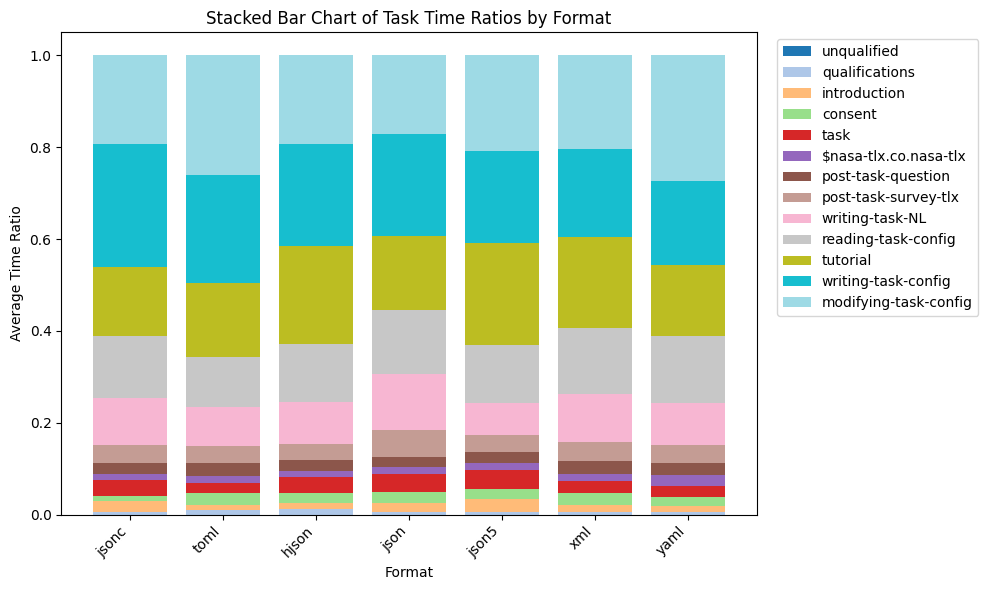

In [2]:
folder = '/Users/shiyihe/Desktop/ANALYSIS_SCRIPT/config'
# folder = '/Users/shiyihe/Desktop/ANALYSIS_SCRIPTS/test_all_data'
all_data = load_all_data(folder, ignore_completed=True)
df_task, df_part, format_stat= time_analysis(all_data)
df_writing_nl = extract_writing_nl_tasks(all_data)
df_writing = extract_writing_tasks(all_data)
df_modifying = extract_modifying_tasks(all_data)
df_reading = extract_reading_tasks(all_data)
df_ratio, df_format_avg_ratio = compute_task_time_ratio(df_part, df_writing)
df_writing_norm = normalize_typing_time(df_writing_nl, df_writing, keep_baseline=False)
df_ratio, wide_avg = compute_avg_ratio(df_task, tasks=None)
fig, ax = plot_stacked_ratio(
    wide_avg,
    sort_formats_by='writing-task-config',
    stack_order_by='yaml'
)


In [3]:
format_stat

format
yaml     17
jsonc    15
toml     15
json5    15
xml      15
hjson    15
json     15
Name: count, dtype: int64

### writing time ratio 

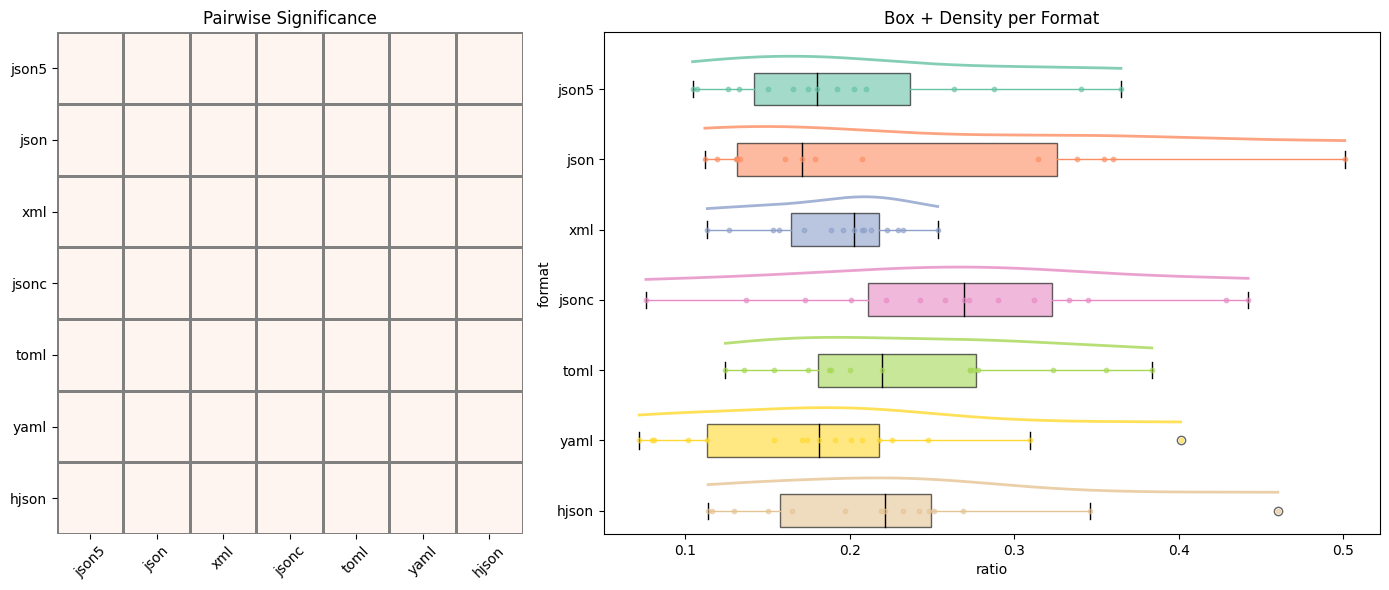

In [3]:
vis_box_comparasion(
    df_ratio,
    group_col='format',
    value_col='ratio',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

## Time Analysis

### writing

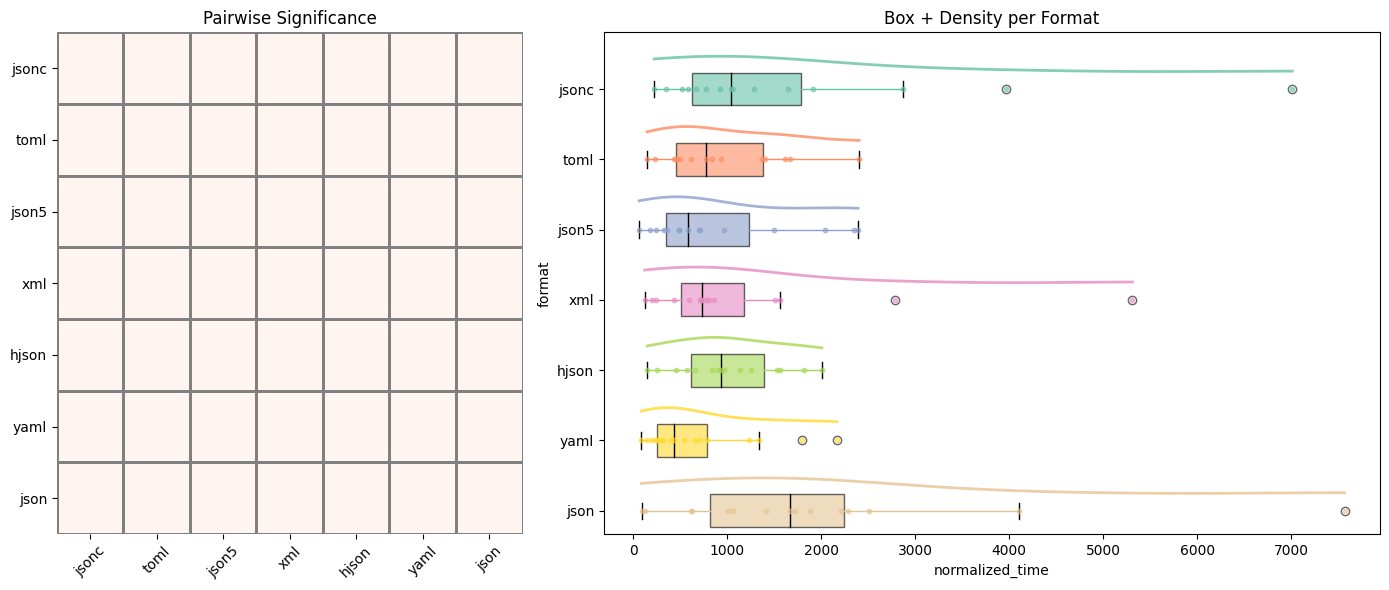

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count         mean          std       median         min          max
 format                                                                       
 hjson      15  1003.327606   553.452717   934.208193  150.819821  2008.855223
 json       15  1926.805217  1874.106251  1672.418345   90.014136  7570.503525
 json5      15   893.255855   790.782297   583.860278   64.957857  2392.808629
 jsonc      15  1658.053427  1790.203996  1041.053921  223.780560  7011.880713
 toml       15   924.937168   638.008132   771.857025  148.903186  2404.909835
 xml        15  1156.918620  1330.792357   728.492154  123.255406  5311.267593
 yaml       17   682.095187   606.689957   433.216196   87.965123  2166.251427,
 'overall_p': 0.05206642870370747,
 'effect_size': 0.11520494415486529,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],

In [4]:
## writing_task

vis_box_comparasion(
    df_writing_norm,
    group_col='format',
    value_col='normalized_time',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

w_time_results = compare_statistically(
    df_writing_norm,
    group_col='format',
    value_col='normalized_time',
    method='anova',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

w_time_results

### reading

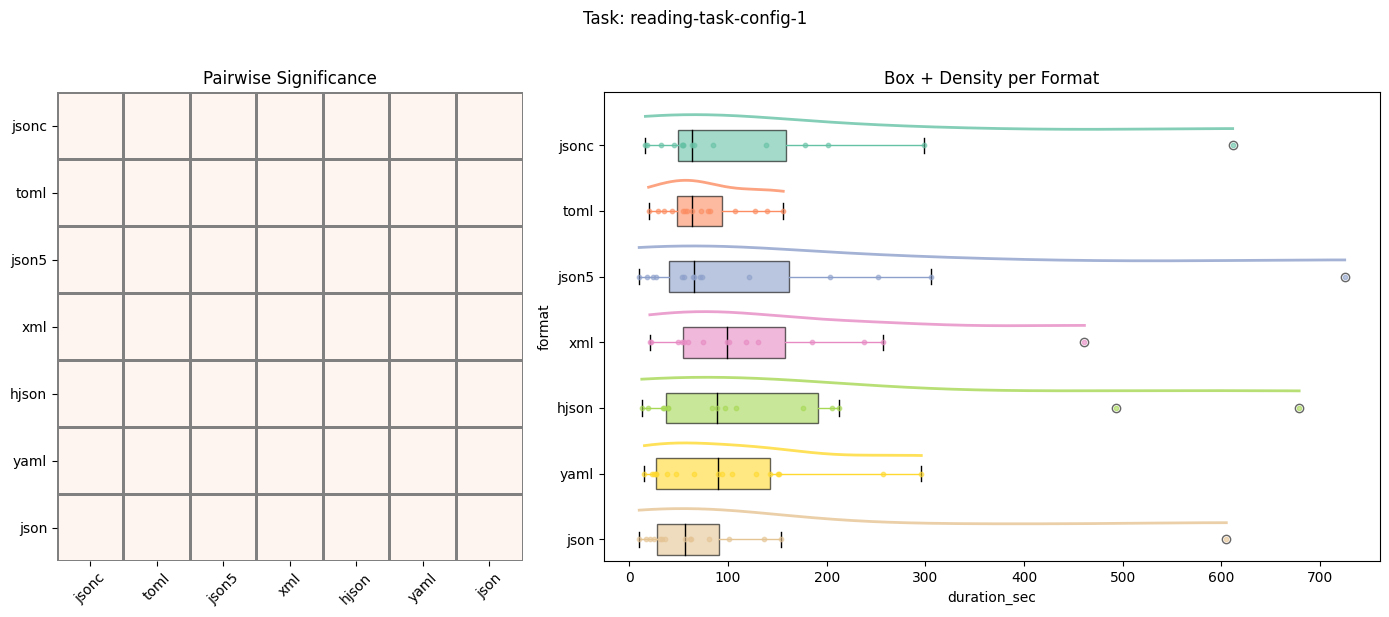

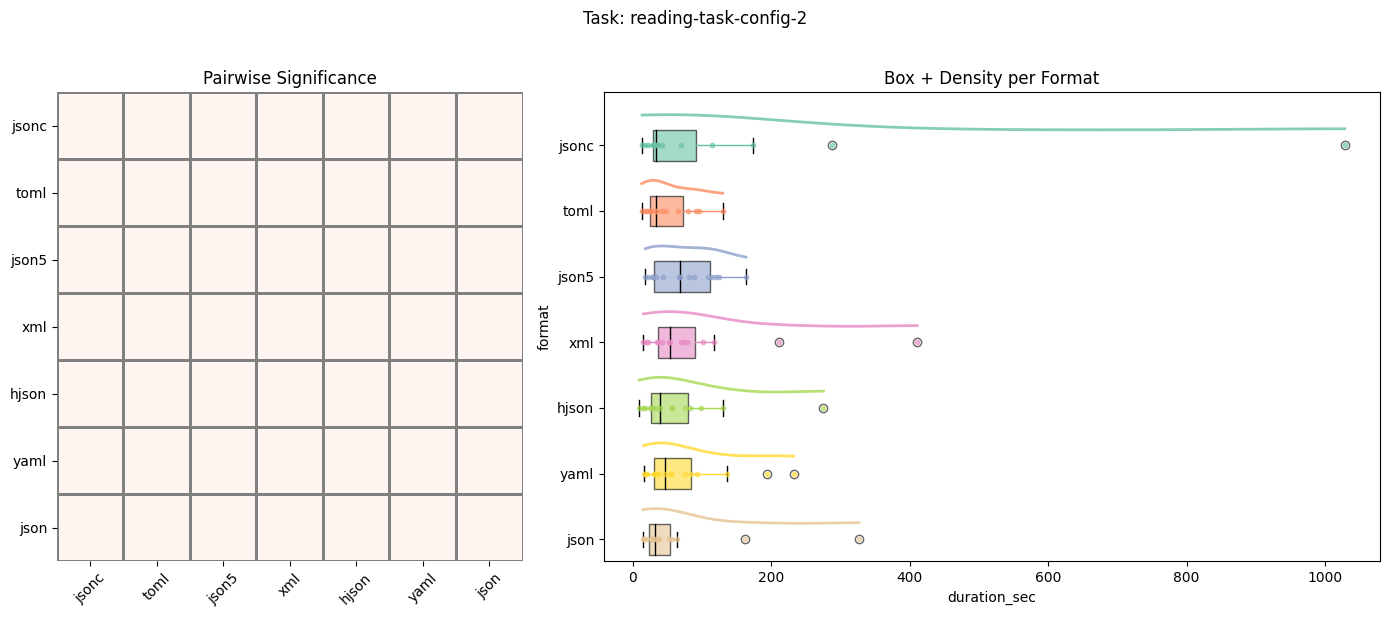

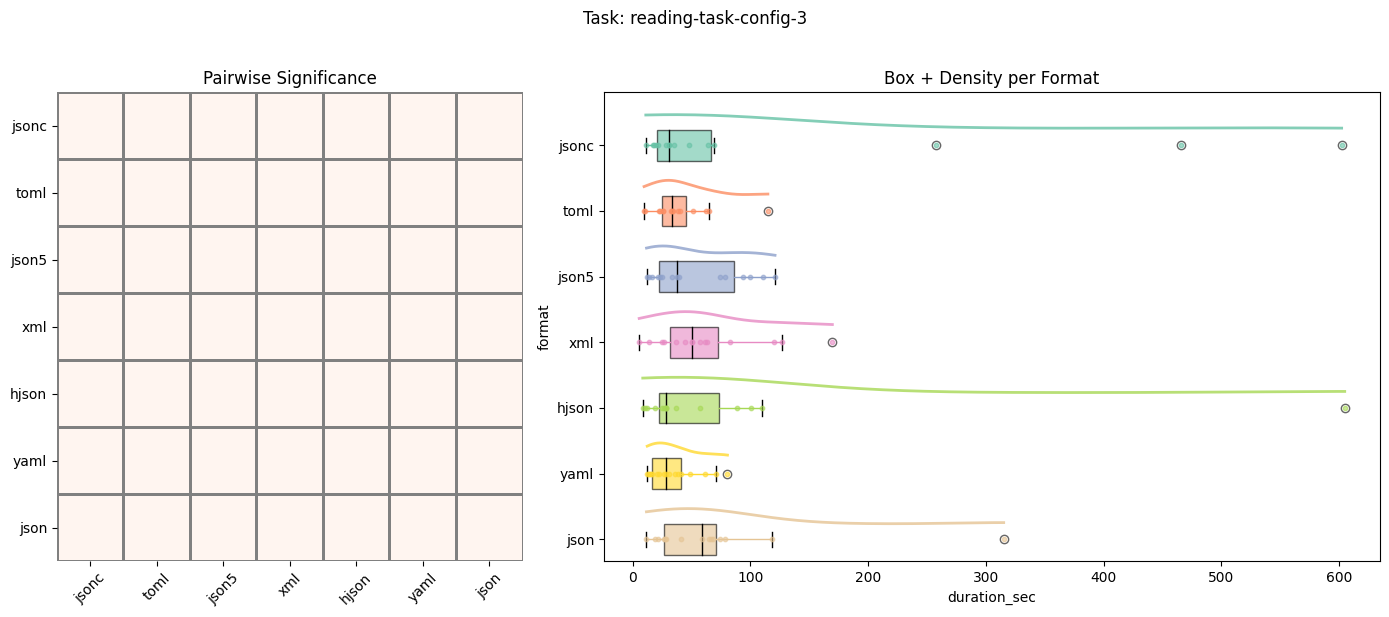

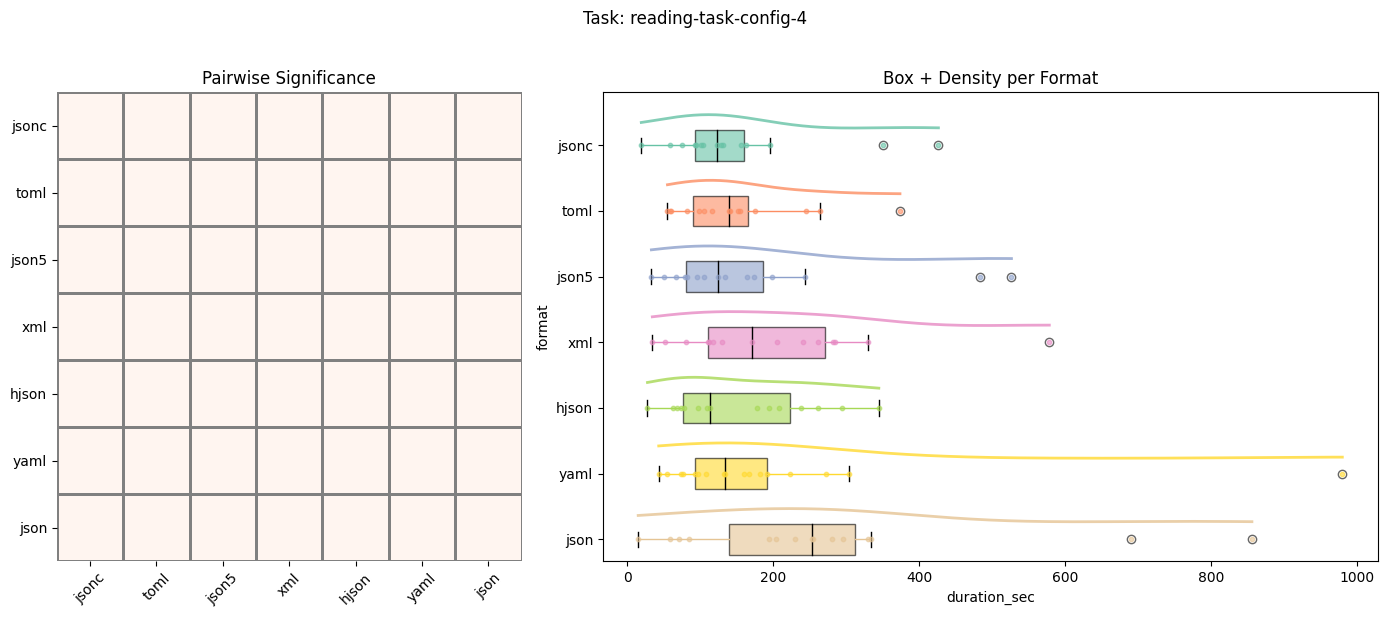

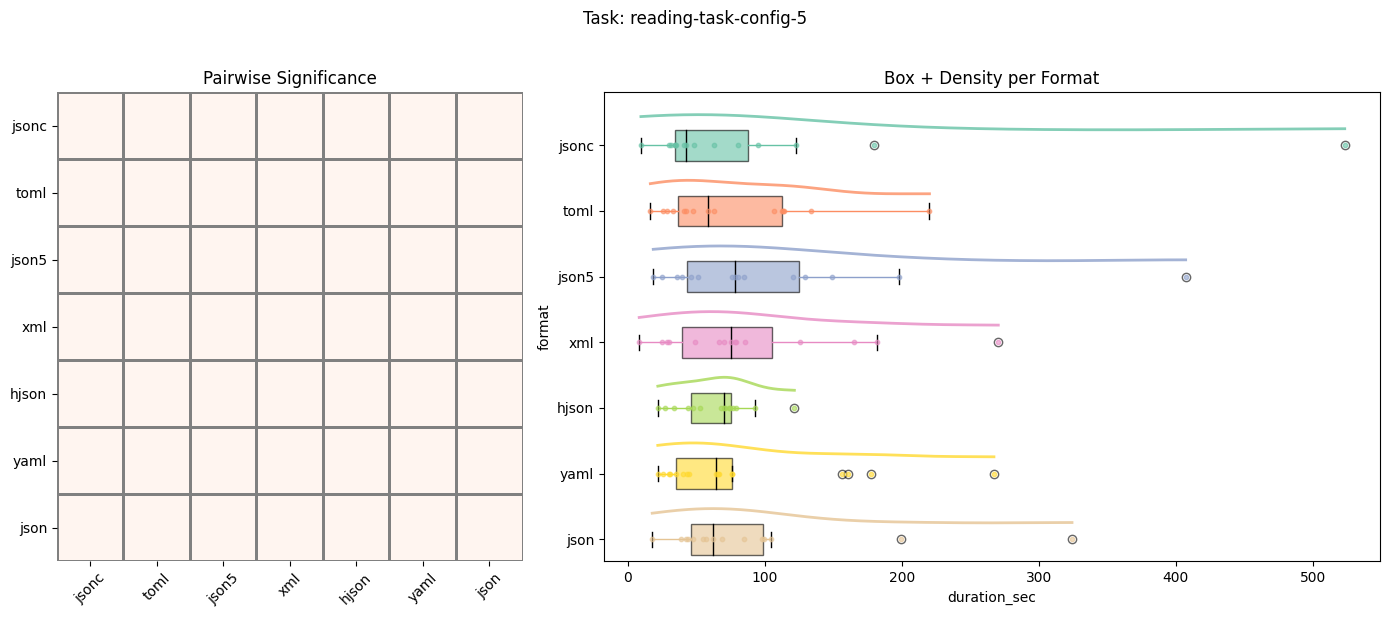

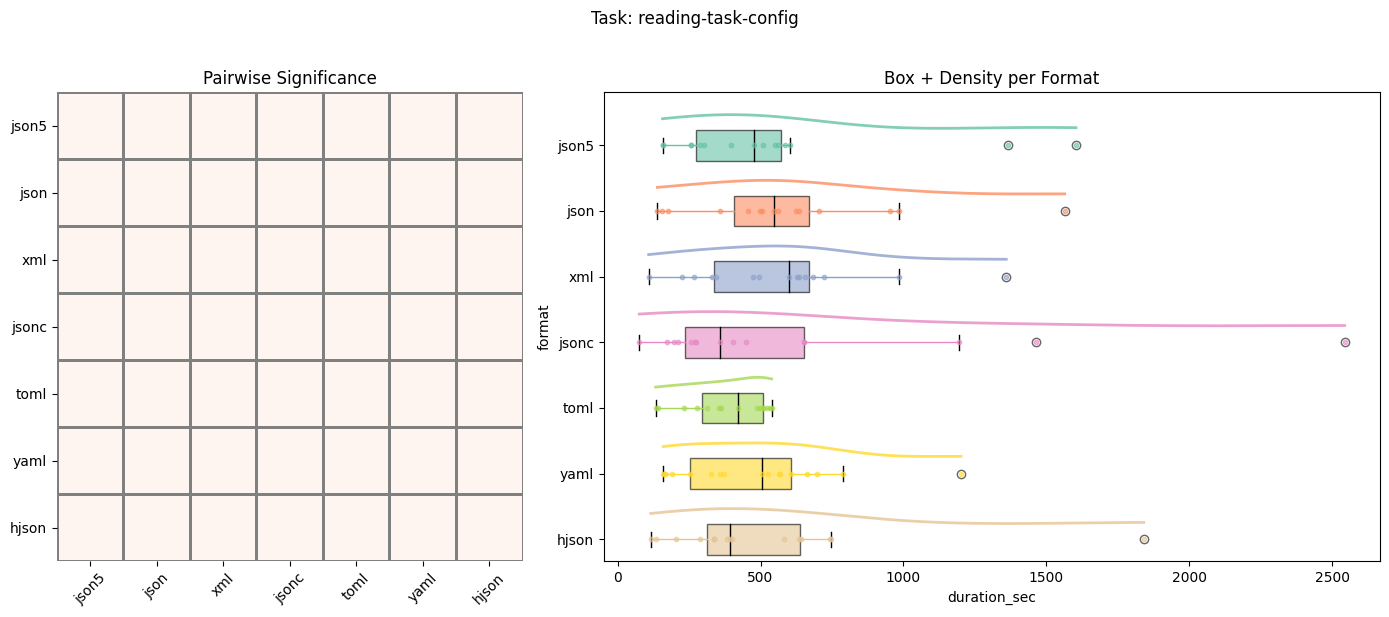

{'reading-task-config': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count        mean         std   median      min       max
  format                                                           
  hjson      15  518.683333  419.309728  393.819  115.937  1840.863
  json       15  590.526067  368.940523  548.079  139.342  1564.420
  json5      15  538.087467  415.444840  477.696  157.047  1604.290
  jsonc      15  611.727533  660.601350  357.557   75.443  2544.382
  toml       15  388.612067  142.285040  420.675  133.024   538.767
  xml        15  568.054600  315.579606  599.896  108.563  1360.035
  yaml       17  477.556647  275.890958  506.862  159.383  1201.899,
  'overall_p': 0.7654958669145109,
  'effect_size': 0.03219341516158456,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'reading-task-config-1': {'method': 'anova',
 

In [69]:
## reading tasks
df_reading_clean = aggregate_tasks_with_format(
    df_reading,
    participant_col='participantId',
    task_col='task',
    format_col = 'format',
    metrics=['duration_sec','help_count']
)

vis_box_comparasion(
    df_reading_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

r_time_results = compare_statistically(
    df_reading_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

r_time_results


### modifying

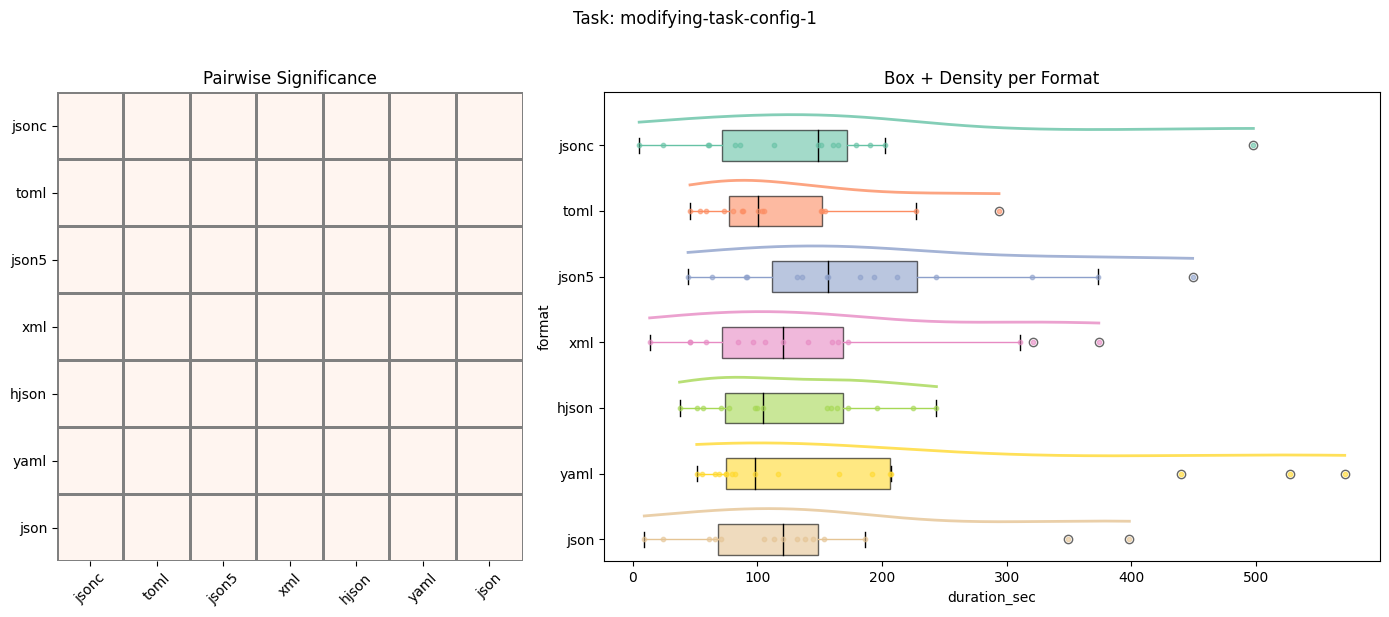

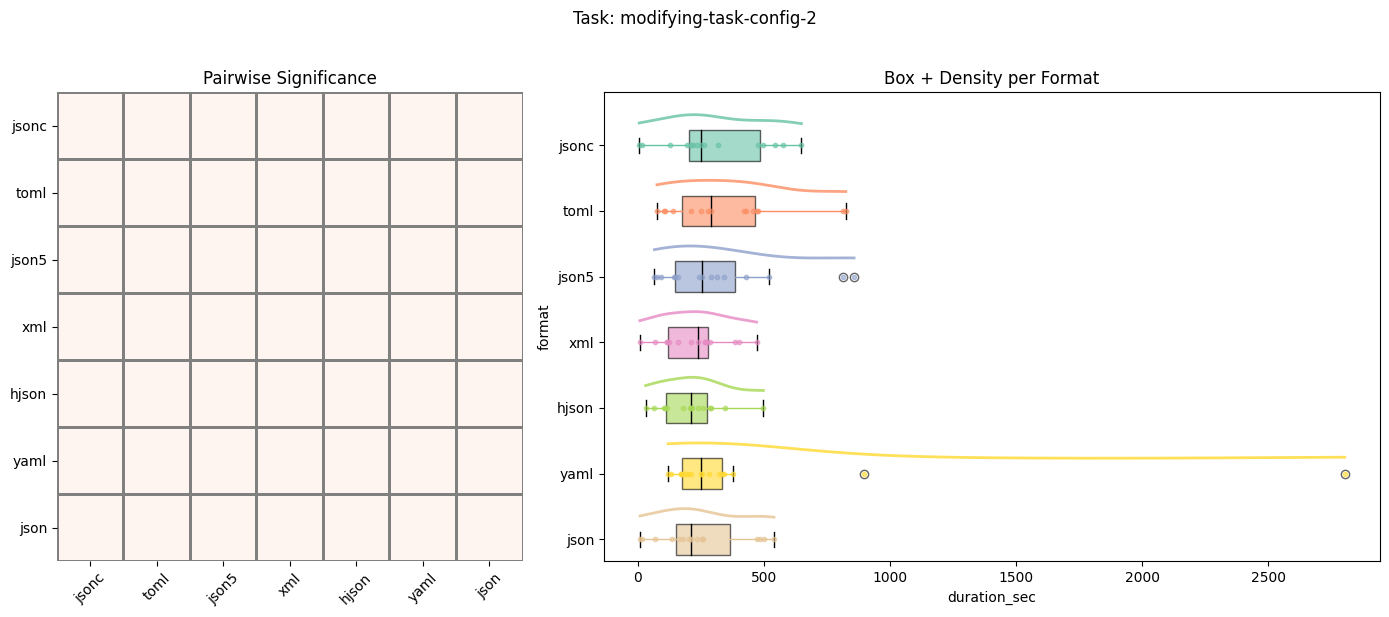

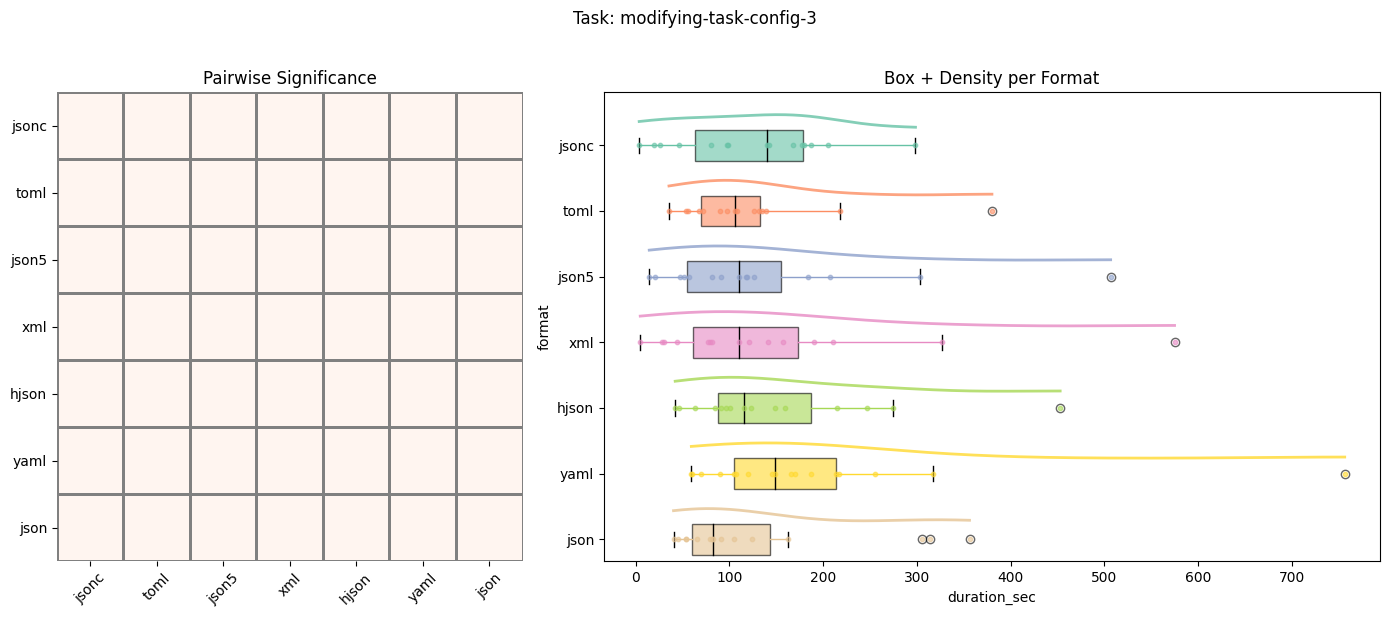

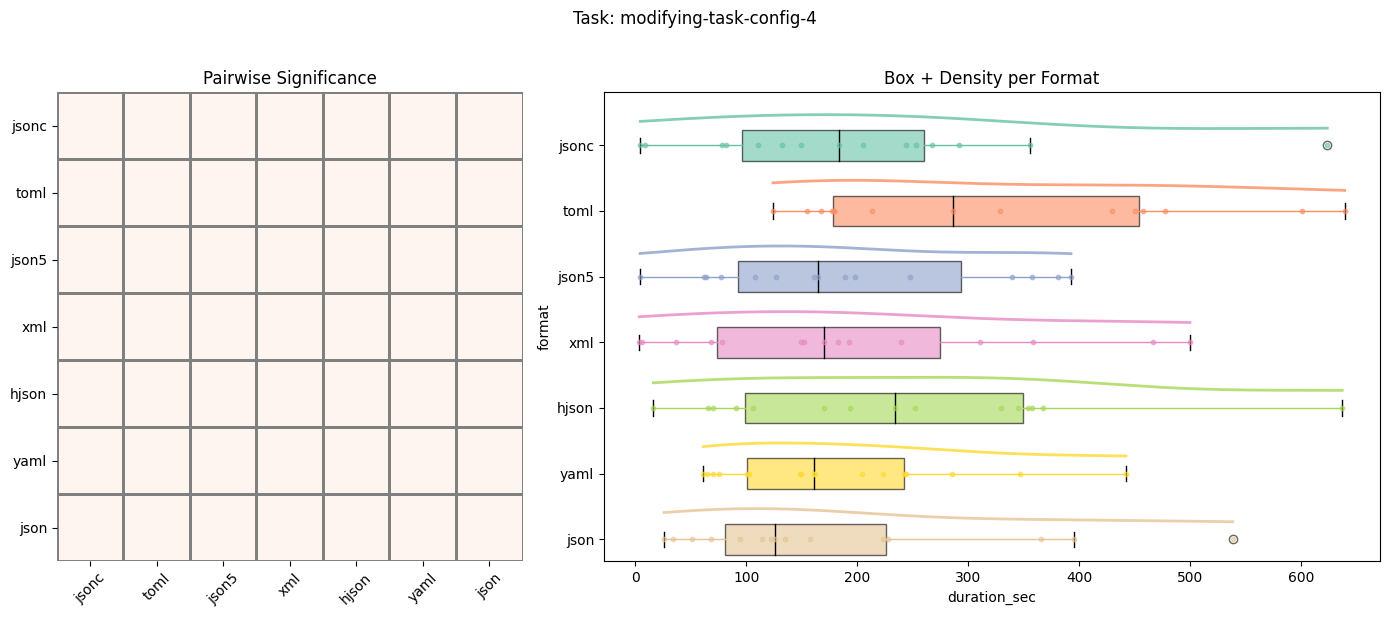

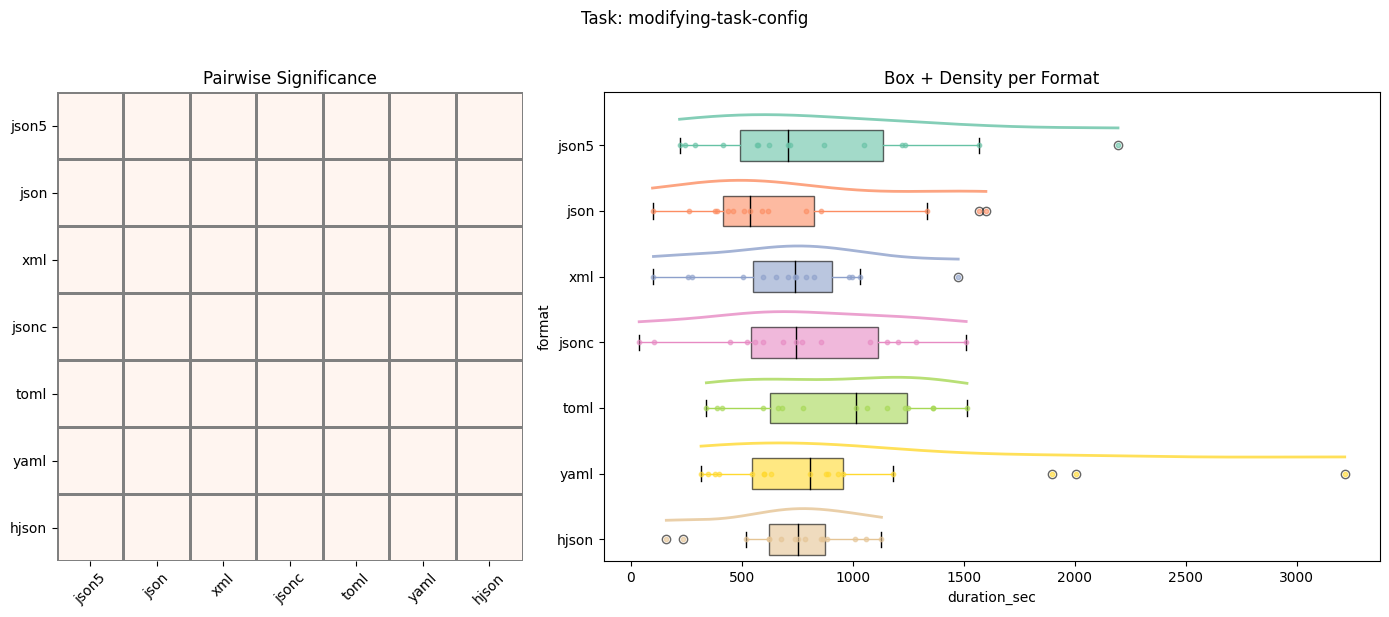

{'modifying-task-config': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count        mean         std    median      min       max
  format                                                            
  hjson      15  727.562133  273.603018   754.351  159.846  1128.813
  json       15  695.435000  459.870069   535.157   97.767  1599.226
  json5      15  833.067133  545.105398   707.949  219.529  2194.235
  jsonc      15  770.249333  420.611908   742.336   37.589  1510.373
  toml       15  920.253667  393.392014  1014.994  340.236  1514.005
  xml        15  712.432000  347.339966   741.154  101.923  1474.525
  yaml       17  975.321765  755.224925   807.021  316.352  3215.516,
  'overall_p': 0.5798572873518746,
  'effect_size': 0.04525311456157497,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'modifying-task-config-1': {'method

In [70]:
## modifying tasks
df_modifying_clean = aggregate_tasks_with_format(
    df_modifying,
    participant_col='participantId',
    task_col='task',
    format_col = 'format',
    metrics=['duration_sec','help_count']
)

vis_box_comparasion(
    df_modifying_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-config-1','modifying-task-config-2','modifying-task-config-3','modifying-task-config-4', 'modifying-task-config']
)

m_write_results = compare_statistically(
    df_modifying_clean,
    group_col='format',
    value_col='duration_sec',
    method='anova',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-config-1','modifying-task-config-2','modifying-task-config-3','modifying-task-config-4', 'modifying-task-confi']
)

m_write_results

## Help Button Clicks Analysis

### writing

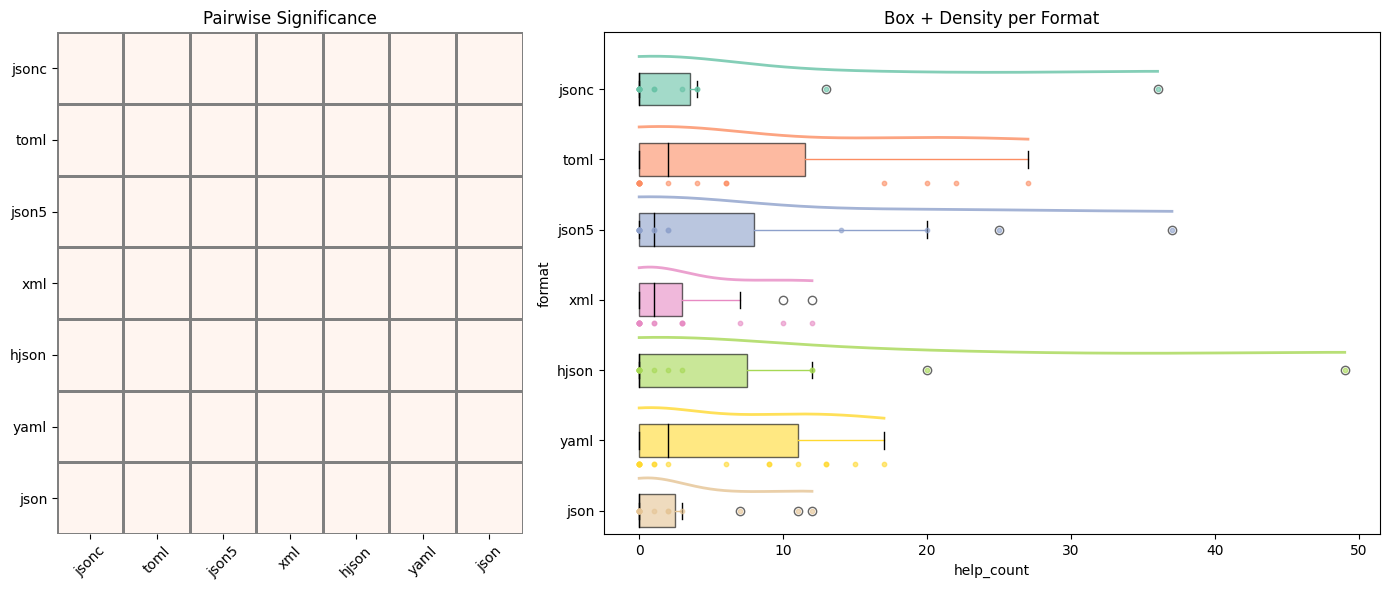

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean        std  median  min  max
 format                                              
 hjson      15  6.600000  13.227677     0.0    0   49
 json       15  2.533333   4.103425     0.0    0   12
 json5      15  6.800000  11.669251     1.0    0   37
 jsonc      15  4.133333   9.455661     0.0    0   36
 toml       15  6.933333   9.535398     2.0    0   27
 xml        15  2.666667   3.921856     1.0    0   12
 yaml       17  5.705882   6.242643     2.0    0   17,
 'overall_p': 0.6482941244015943,
 'effect_size': 0.04044118089130932,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [78]:
## writing_task

vis_box_comparasion(
    df_writing_norm,
    group_col='format',
    value_col='help_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

w_help_results = compare_statistically(
    df_writing_norm,
    group_col='format',
    value_col='help_count',
    method='anova',
    task_col='task'
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

w_help_results

### reading

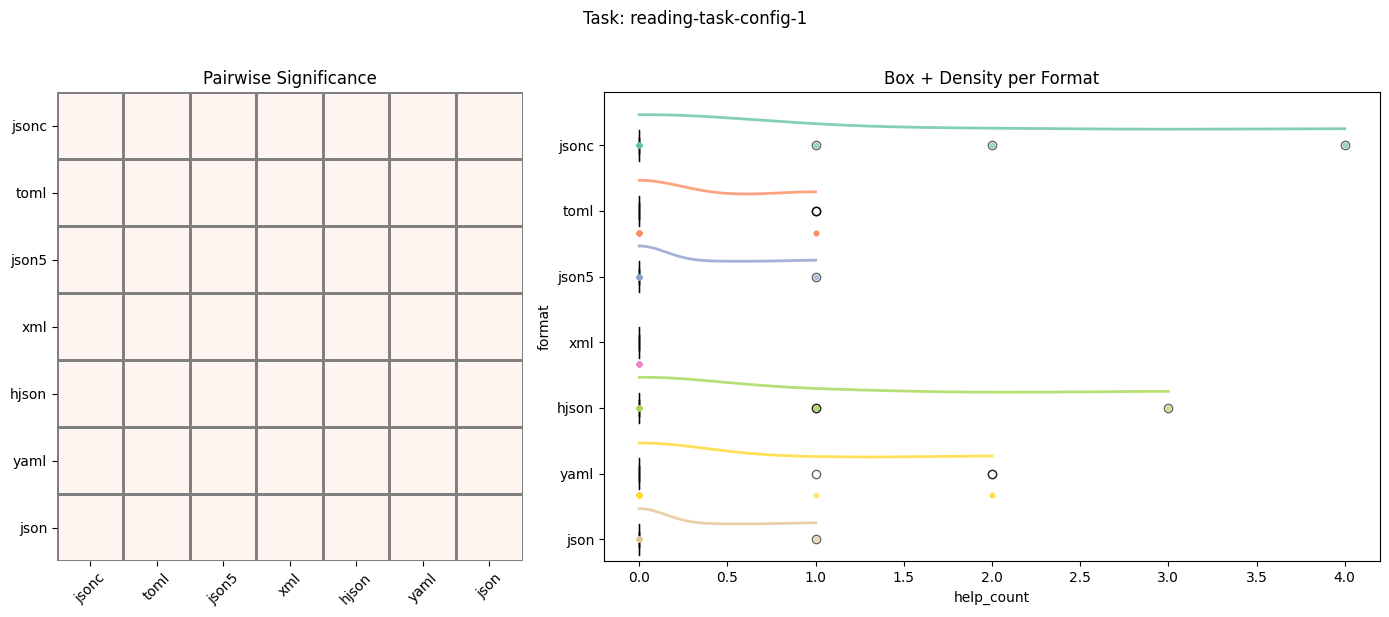

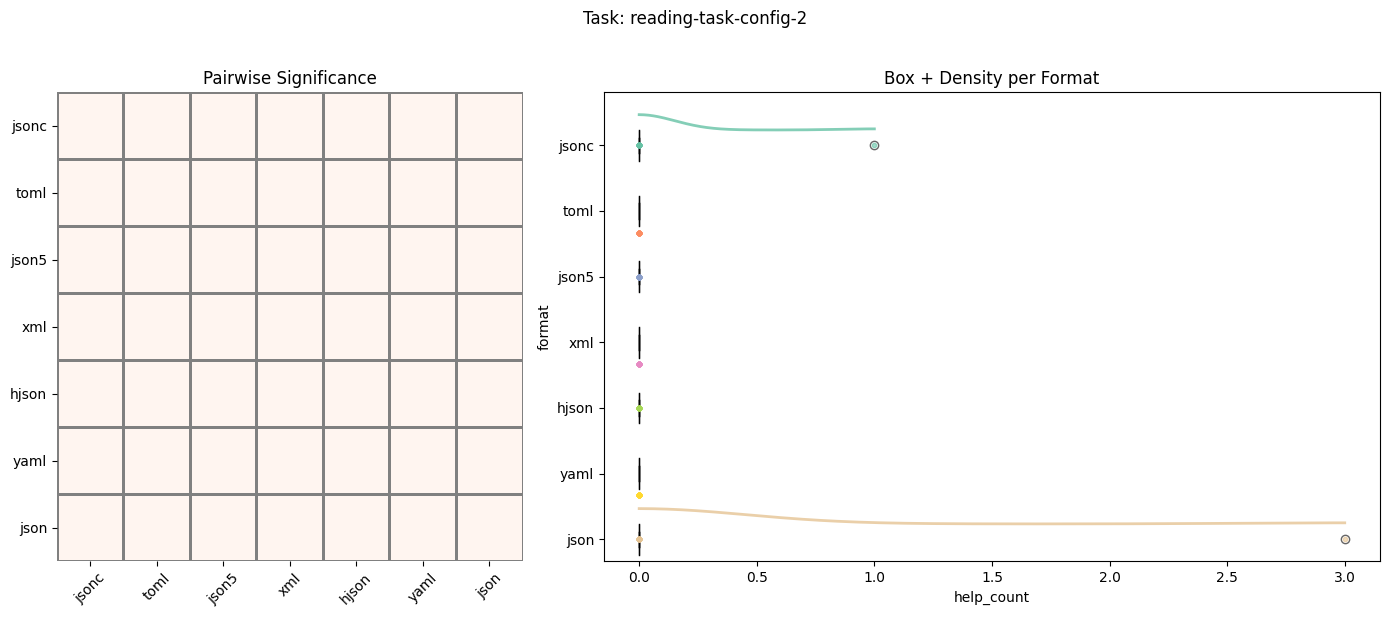

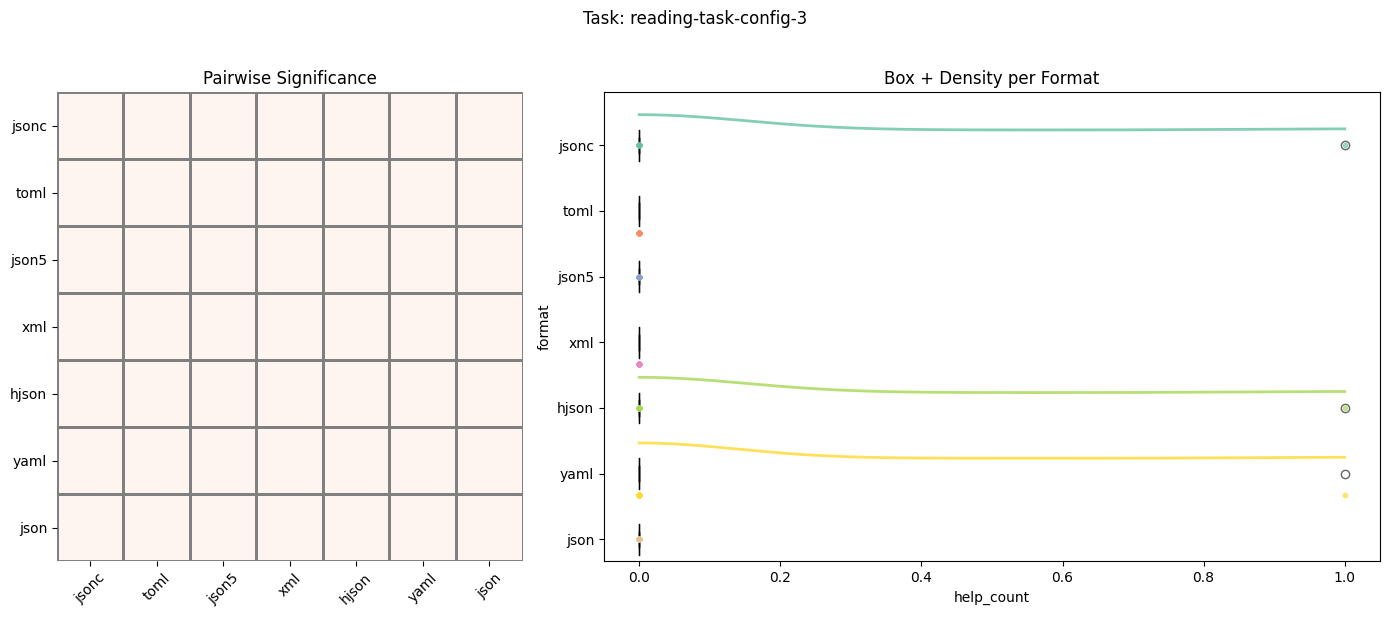

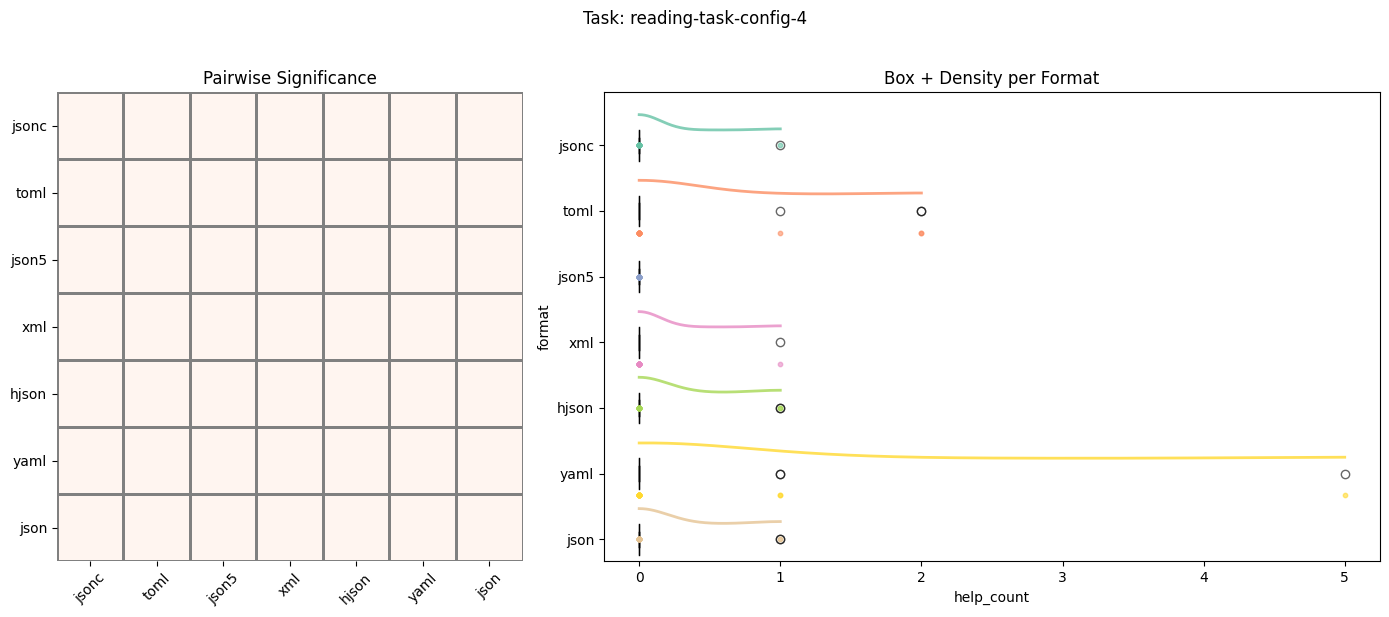

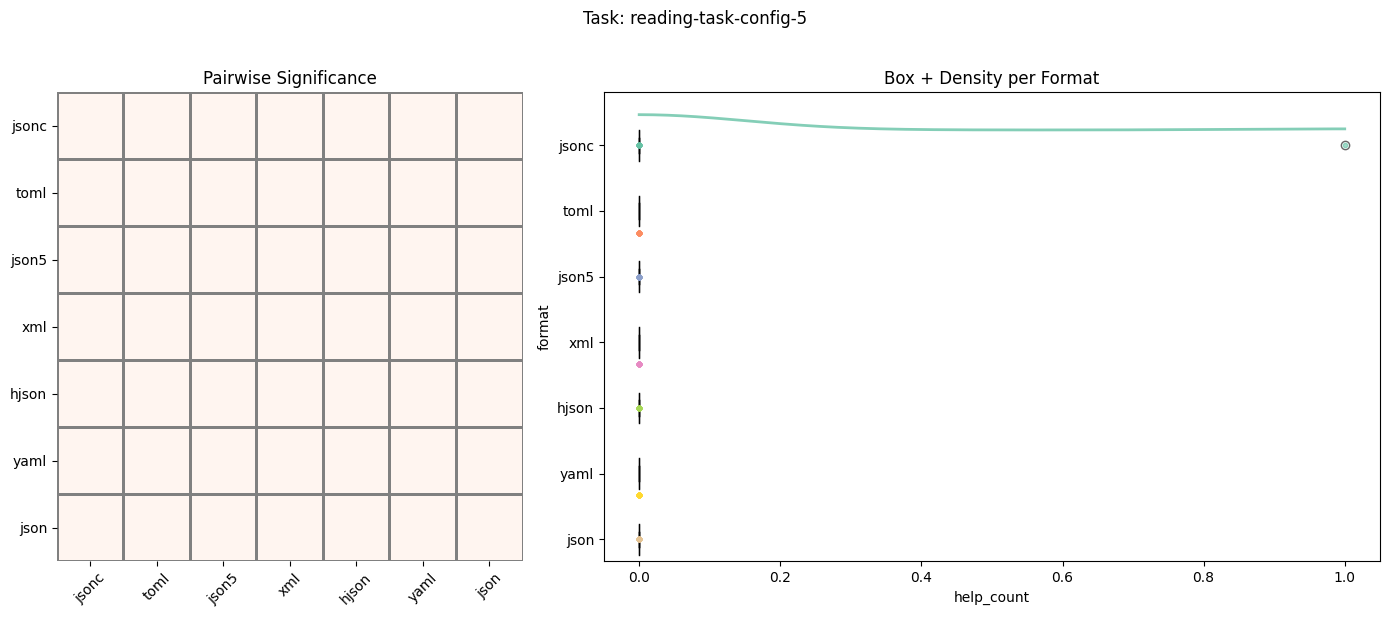

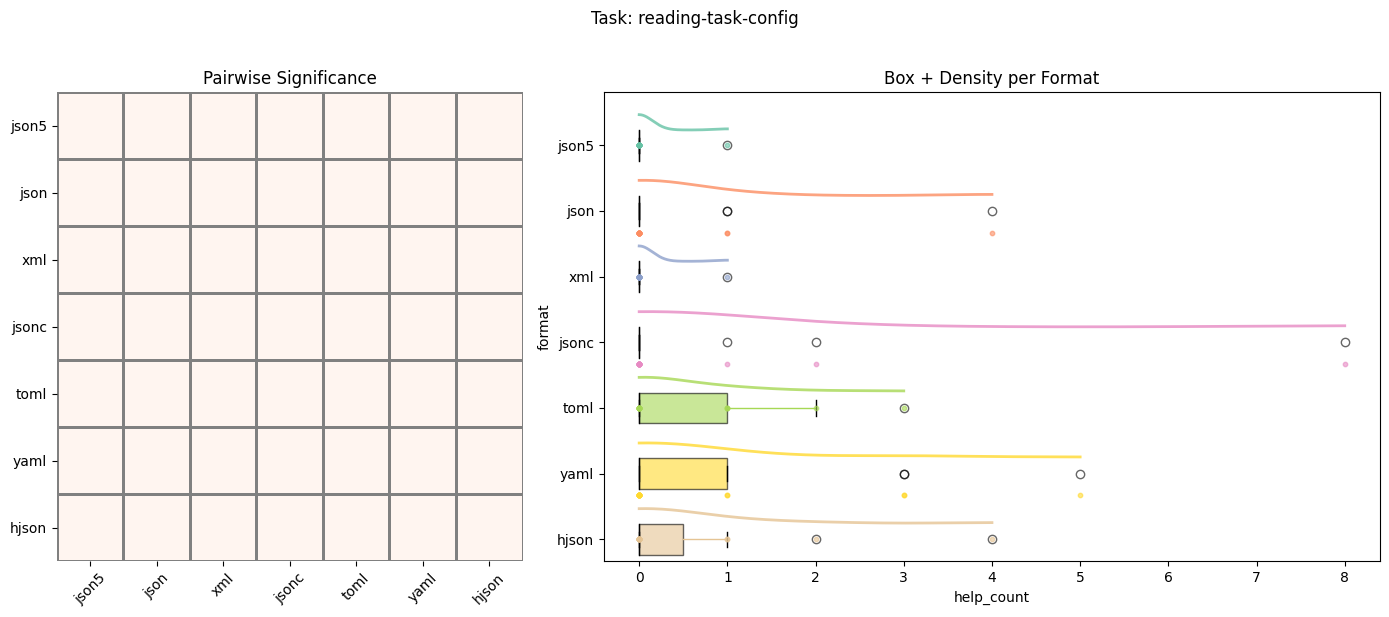

{'reading-task-config': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      15  0.533333  1.125463     0.0    0    4
  json       15  0.400000  1.055597     0.0    0    4
  json5      15  0.066667  0.258199     0.0    0    1
  jsonc      15  0.733333  2.086236     0.0    0    8
  toml       15  0.533333  0.915475     0.0    0    3
  xml        15  0.066667  0.258199     0.0    0    1
  yaml       17  0.764706  1.480262     0.0    0    5,
  'overall_p': 0.5129258954859762,
  'effect_size': 0.05012251857264644,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'reading-task-config-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  form

In [79]:
## reading_task

vis_box_comparasion(
    df_reading_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

r_help_results = compare_statistically(
    df_reading_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    task_col='task',
    # # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

r_help_results

### modifying

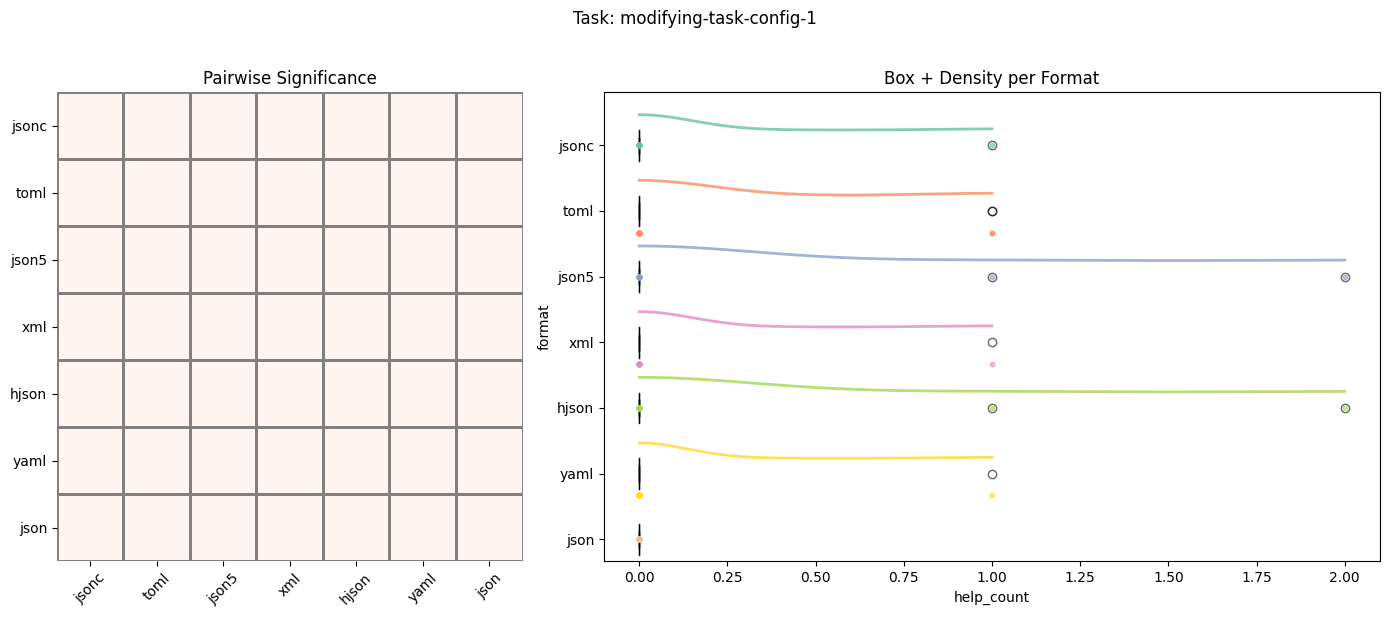

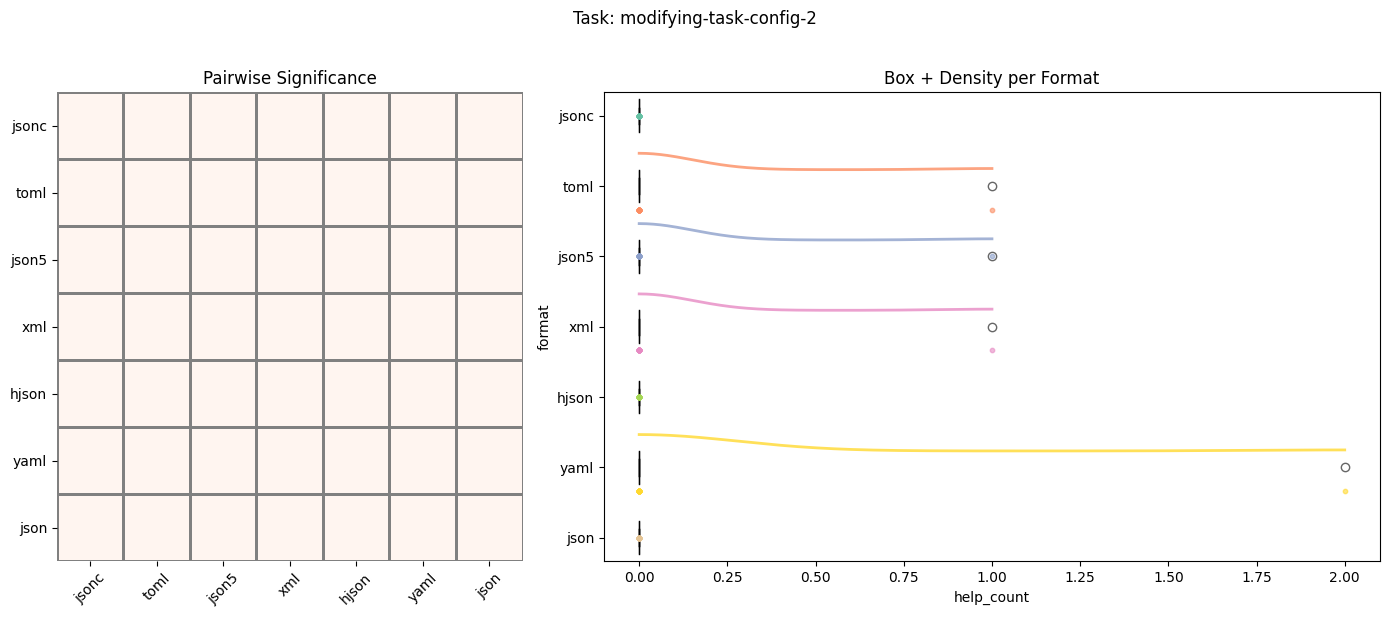

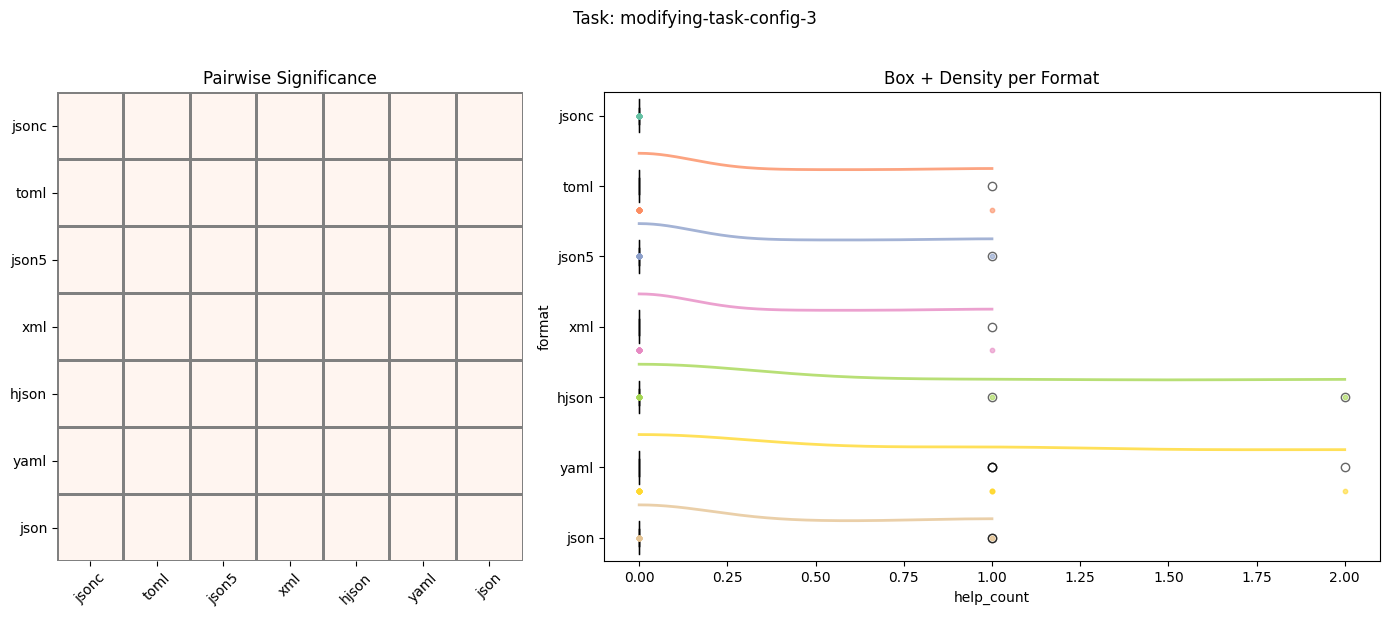

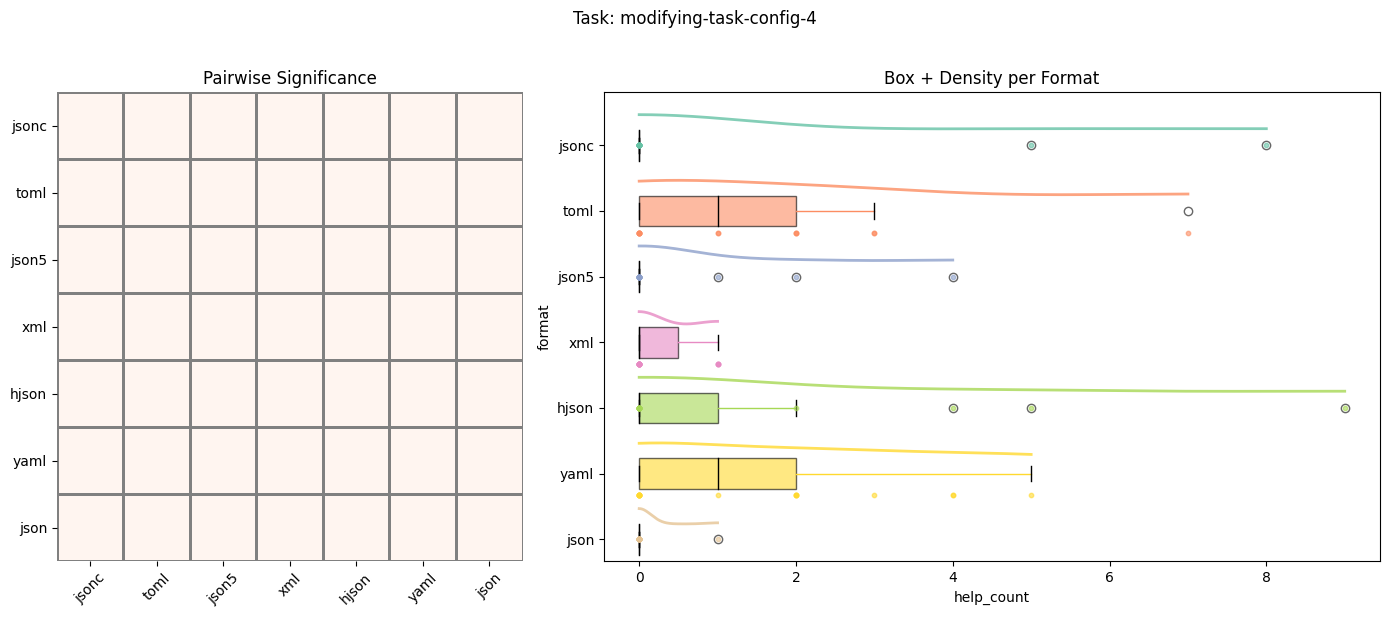

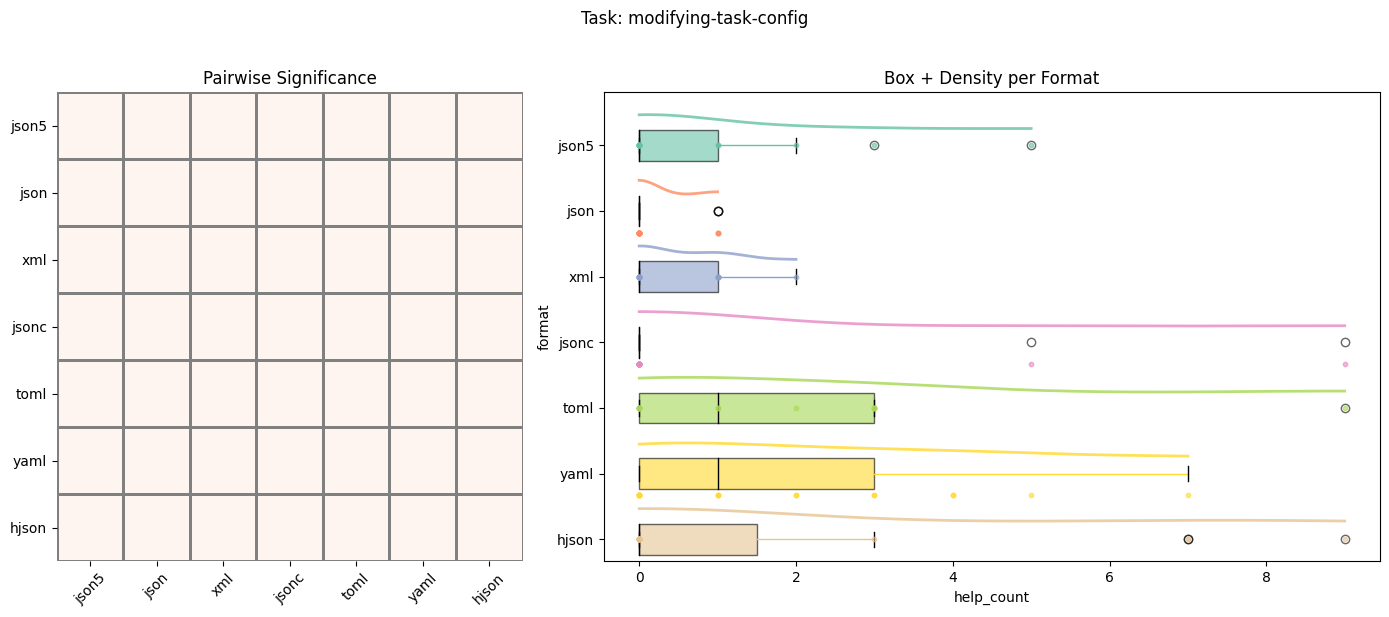

{'modifying-task-config': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      15  1.733333  3.195235     0.0    0    9
  json       15  0.200000  0.414039     0.0    0    1
  json5      15  0.800000  1.473577     0.0    0    5
  jsonc      15  0.933333  2.576450     0.0    0    9
  toml       15  1.666667  2.410295     1.0    0    9
  xml        15  0.466667  0.639940     0.0    0    2
  yaml       17  1.941176  2.105665     1.0    0    7,
  'overall_p': 0.1362211830506863,
  'effect_size': 0.09106130944852256,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'modifying-task-config-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  

In [80]:
## modifying tasks
vis_box_comparasion(
    df_modifying_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-config-1','modifying-task-config-2','modifying-task-config-3','modifying-task-config-4', 'modifying-task-config']
)

m_time_results = compare_statistically(
    df_modifying_clean,
    group_col='format',
    value_col='help_count',
    method='anova',
    task_col='task',
    # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
    continuous_tasks=['modifying-task-config-1','modifying-task-config-2','modifying-task-config-3','modifying-task-config-4', 'modifying-task-config']
)

m_time_results

In [81]:
# sig_pairs = compare_significant_pairs(
#     df_writing_norm,
#     group_col='format',
#     value_col='normalized_time',
#     method='anova',
#     task_col=None
# )
# print(sig_pairs)


# # 多任务，返回 dict
# sig_by_task = compare_significant_pairs(
#     df_modifying_clean,
#     group_col='format',
#     value_col='help_count',
#     method='anova',
#     task_col='task',
#     # discrete_tasks=['reading-task-config-1','reading-task-config-2'],
#     continuous_tasks=['modifying-task-config-1','modifying-task-config-2','modifying-task-config-3','modifying-task-config-4', 'modifying-task']
# )
# for task, df_sig in sig_by_task.items():
#     print(task, df_sig)

## Reading Correctness Analysis

### statistical test

In [4]:
correct_answers_config = {
    'reading-task-config-1': '7.9.0',
    'reading-task-config-2': ">=12",
    'reading-task-config-3': 6,
    'reading-task-config-4': 'keywords',
    'reading-task-config-5': 'd3-delaunay'
}


df_reading_result = annotate_reading_correctness_exact(
    df_reading,
    correct_answers_config,
    task_col='task',
    format_col='format',
    response_col='response'
)

df_reading_agg = aggregate_tasks_with_format(
    df_reading_result,
    participant_col='participantId',
    task_col='task',
    format_col = 'format',
    metrics=['duration_sec','help_count','correct']
)
df_reading_agg

,participantId,task,format,response,start_time,end_time,duration_sec,help_count,correct_answer,correct
0,67895b7d6400163124042af7,reading-task-config-1,jsonc,7.9.0,1.747336e+12,1.747336e+12,65.634,0,7.9.0,1
1,67895b7d6400163124042af7,reading-task-config-2,jsonc,12,1.747336e+12,1.747336e+12,68.938,0,>=12,0
2,67895b7d6400163124042af7,reading-task-config-3,jsonc,6,1.747336e+12,1.747336e+12,35.185,0,6,1
3,67895b7d6400163124042af7,reading-task-config-4,jsonc,devDependencies,1.747336e+12,1.747336e+12,74.699,0,keywords,0
4,67895b7d6400163124042af7,reading-task-config-5,jsonc,d3-scale,1.747336e+12,1.747336e+12,30.321,0,d3-delaunay,0
...,...,...,...,...,...,...,...,...,...,...
637,67f66486e35051403284eb5e,reading-task-config,xml,NaN,NaN,NaN,722.635,0,NaN,3
638,680ebf035ab59d342f31726e,reading-task-config,hjson,NaN,NaN,NaN,393.819,0,NaN,5
639,681374d36d7bd7ccb6f914f5,reading-task-config,json5,NaN,NaN,NaN,159.182,0,NaN,4
640,68138e7f96395f4c5f3a0a87,reading-task-config,json,NaN,NaN,NaN,176.875,0,NaN,4


In [5]:
df_reading
df_reading[df_reading['task']=='reading-task-config-1'][df_reading_agg['format']=='xml']

/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_35066/3151635658.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_reading[df_reading['task']=='reading-task-config-1'][df_reading_agg['format']=='xml']


,participantId,task,format,response,start_time,end_time,duration_sec,help_count
20,57ca4b09993b08000192297b,reading-task-config-1,xml,7.9.0,1747172985562,1747173007897,22.335,0
30,6693ce87e76d32ccf07fbcd8,reading-task-config-1,xml,7.9.0,1746769543614,1746769644330,100.716,0
70,60f70af563ef757f65e750e0,reading-task-config-1,xml,7.9.0,1746768622121,1746768677615,55.494,0
135,67c045fa5074c5500ca40e76,reading-task-config-1,xml,7.9.0,1746772073278,1746772311364,238.086,0
140,67d2eaf9d5996dc6be1c7072,reading-task-config-1,xml,7.9.0,1746769337646,1746769594456,256.810,0
185,651b29ff3a6cadf518640abe,reading-task-config-1,xml,7.9.0,1746768752222,1746768801578,49.356,0
220,67aca6831f2b0b79416bdb6c,reading-task-config-1,xml,^3.2.4,1747176249696,1747176435037,185.341,0
270,677f8968bbb08bc37c8d2a4b,reading-task-config-1,xml,7.9.0,1746770750945,1746770881241,130.296,0
275,672f51ea346fba23ddd5a793,reading-task-config-1,xml,7.9.0,1746768774858,1746768892952,118.094,0
325,62d7fef5538b81f205ba4656,reading-task-config-1,xml,7.9.0,1747337196639,1747337217354,20.715,0


In [30]:
df_reading_result[df_reading_result['task']=='reading-task-config-1'][df_reading_agg['format']=='xml']

/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_17537/1679706527.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_reading_result[df_reading_result['task']=='reading-task-config-1'][df_reading_agg['format']=='xml']


,participantId,task,format,response,start_time,end_time,duration_sec,help_count,correct_answer,correct
20,57ca4b09993b08000192297b,reading-task-config-1,xml,None,1747172985562,1747173007897,22.335,0,7.9.0,0
30,6693ce87e76d32ccf07fbcd8,reading-task-config-1,xml,None,1746769543614,1746769644330,100.716,0,7.9.0,0
70,60f70af563ef757f65e750e0,reading-task-config-1,xml,None,1746768622121,1746768677615,55.494,0,7.9.0,0
135,67c045fa5074c5500ca40e76,reading-task-config-1,xml,None,1746772073278,1746772311364,238.086,0,7.9.0,0
140,67d2eaf9d5996dc6be1c7072,reading-task-config-1,xml,None,1746769337646,1746769594456,256.810,0,7.9.0,0
185,651b29ff3a6cadf518640abe,reading-task-config-1,xml,None,1746768752222,1746768801578,49.356,0,7.9.0,0
220,67aca6831f2b0b79416bdb6c,reading-task-config-1,xml,None,1747176249696,1747176435037,185.341,0,7.9.0,0
270,677f8968bbb08bc37c8d2a4b,reading-task-config-1,xml,None,1746770750945,1746770881241,130.296,0,7.9.0,0
275,672f51ea346fba23ddd5a793,reading-task-config-1,xml,None,1746768774858,1746768892952,118.094,0,7.9.0,0
325,62d7fef5538b81f205ba4656,reading-task-config-1,xml,None,1747337196639,1747337217354,20.715,0,7.9.0,0


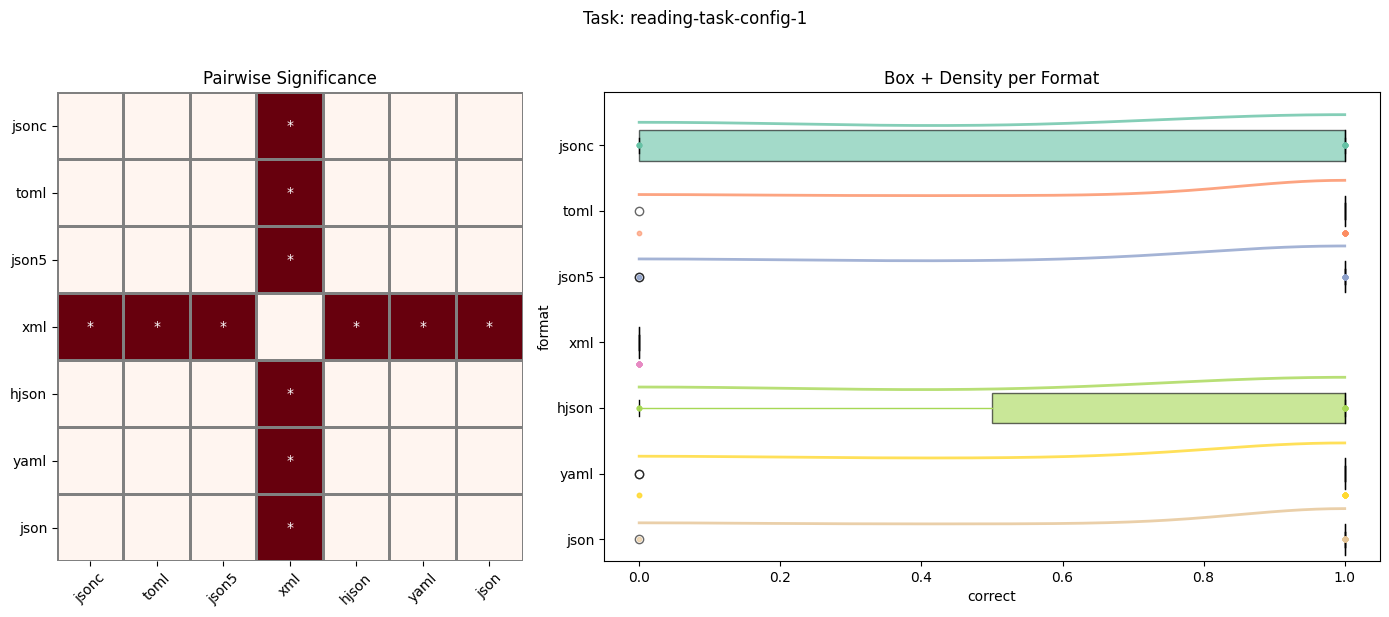

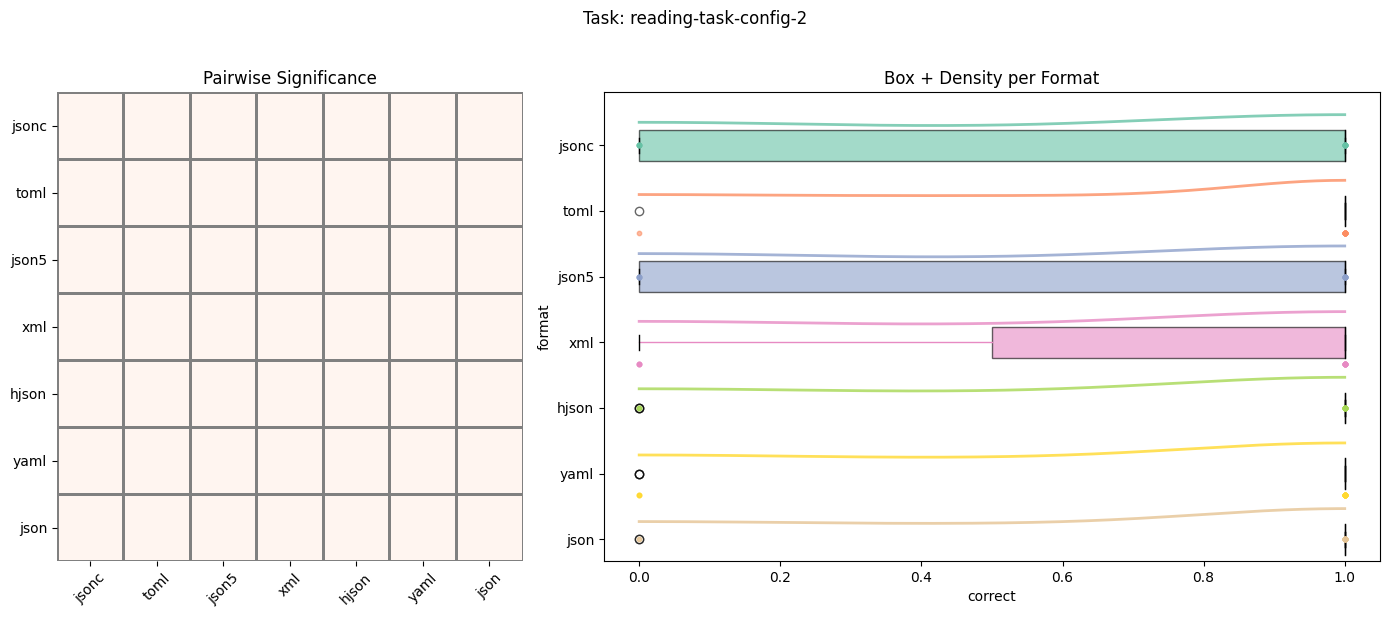

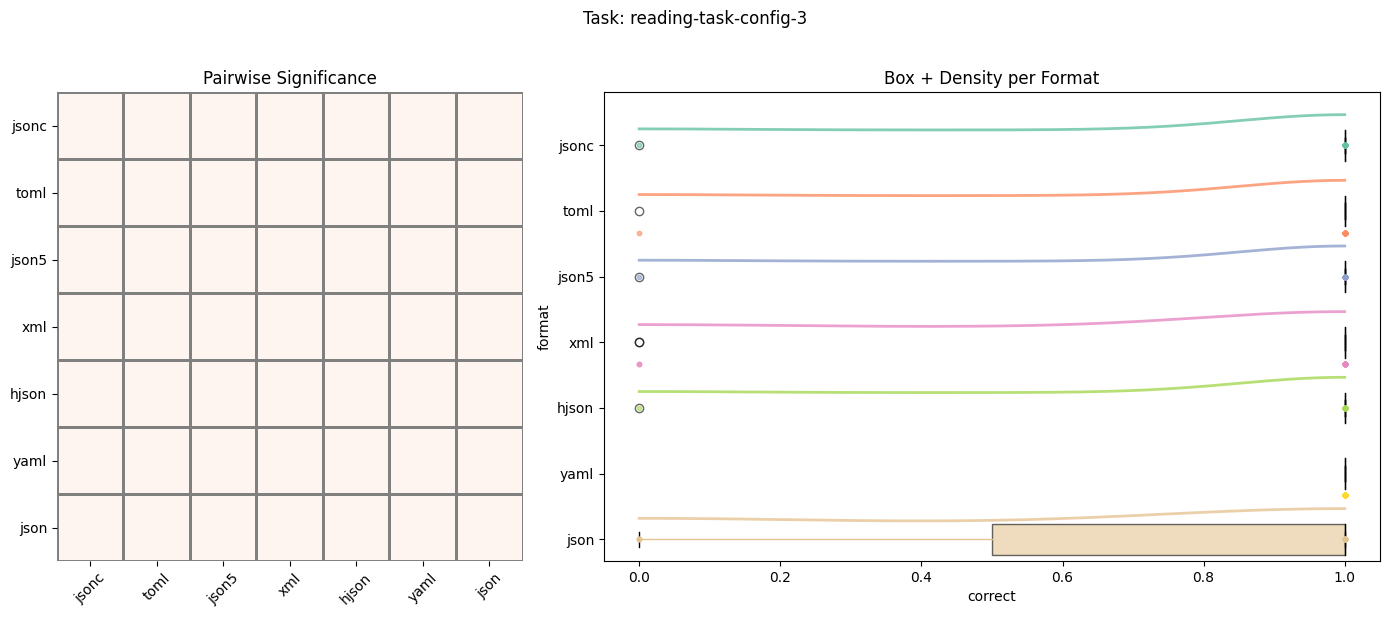

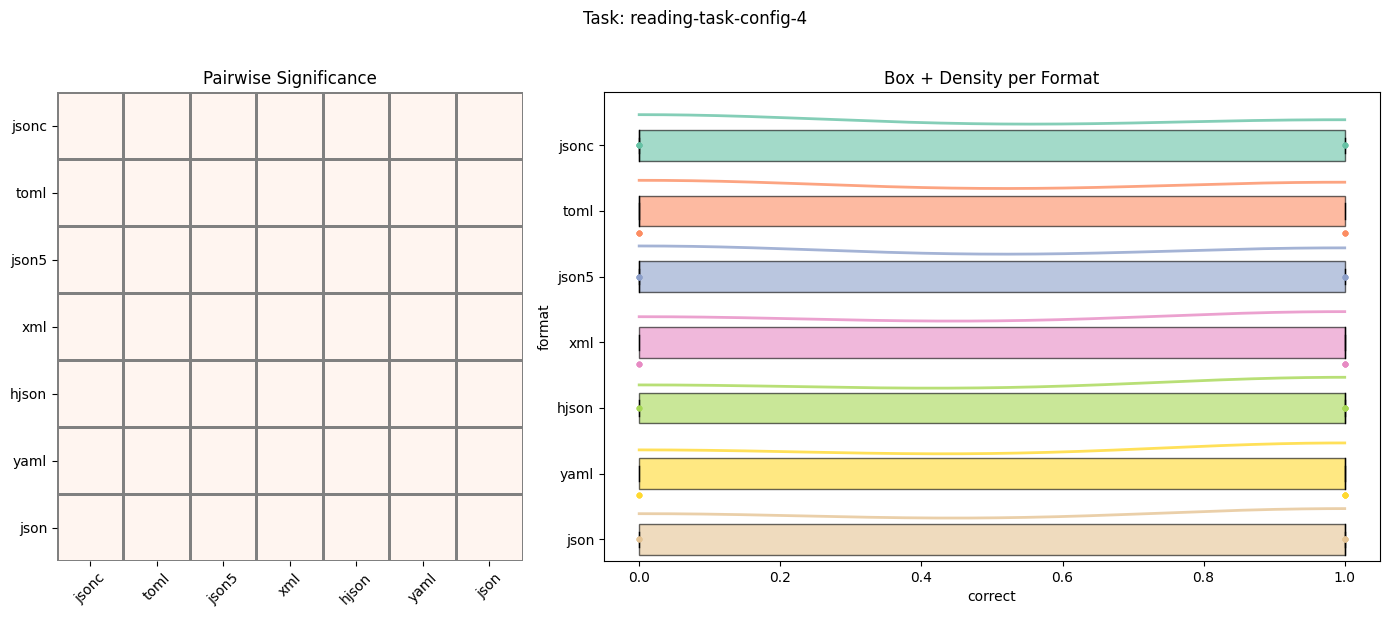

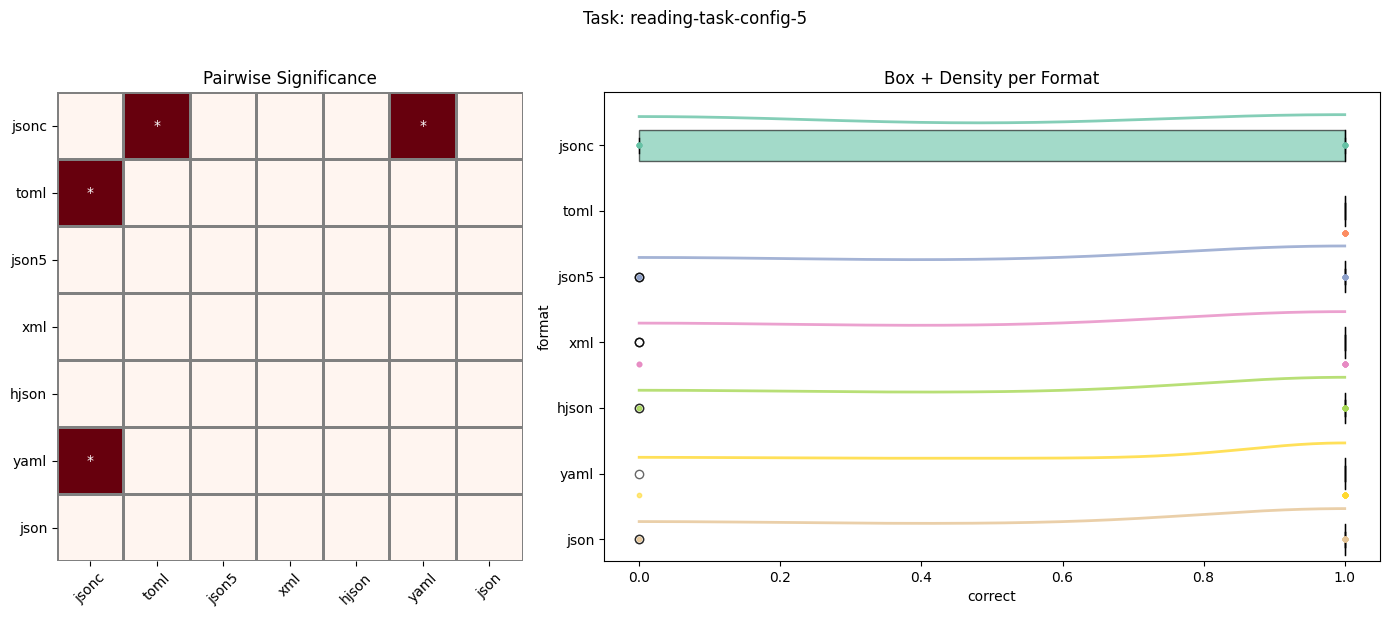

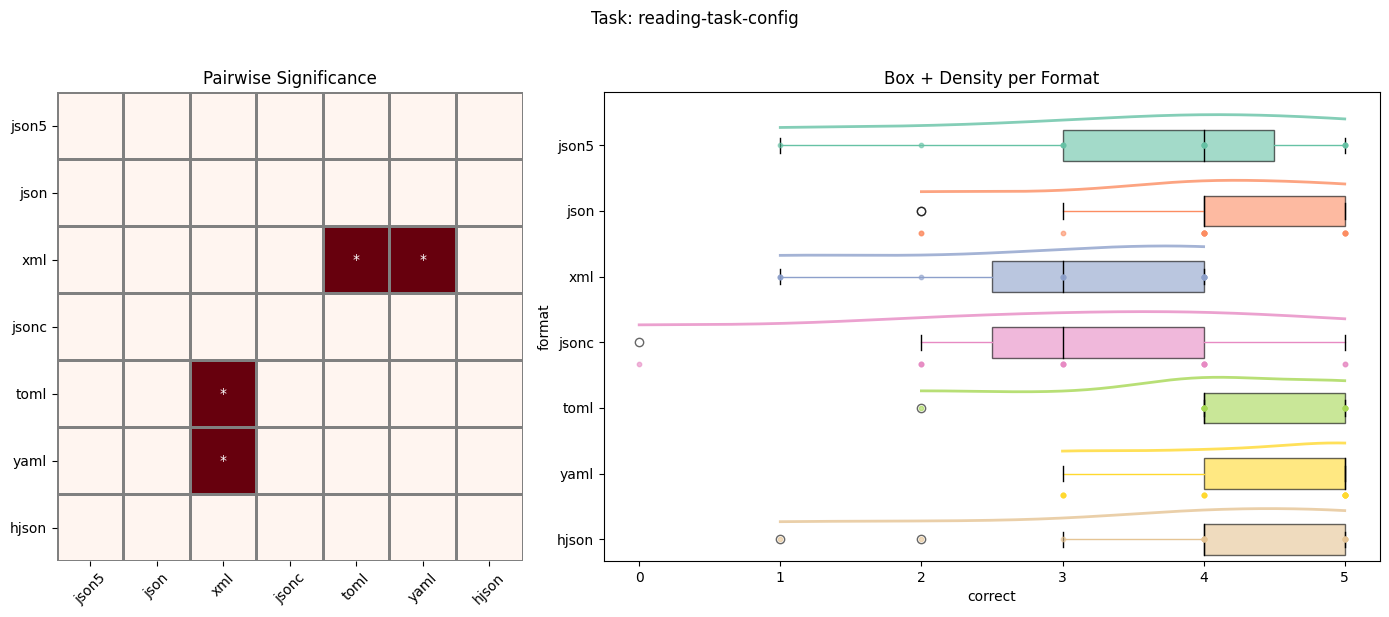

{'reading-task-config': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      15  4.000000  1.195229     4.0    1    5
  json       15  4.000000  1.000000     4.0    2    5
  json5      15  3.733333  1.162919     4.0    1    5
  jsonc      15  3.200000  1.320173     3.0    0    5
  toml       15  4.266667  0.798809     4.0    2    5
  xml        15  3.000000  1.195229     3.0    1    4
  yaml       17  4.294118  0.848875     5.0    3    5,
  'overall_p': 0.004746649177580287,
  'effect_size': 0.16738139832495294,
  'is_significant': True,
  'pairwise':    group1 group2  p_value  significant                     interpretation
  0   hjson   json   1.0000        False   hjson vs json is not significant
  1   hjson  json5   0.9938        False  hjson vs json5 is not significant
  2   hjson  jsonc   0.4097        False  hjson vs jsonc is n

In [83]:
## reading tasks
vis_box_comparasion(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    continuous_tasks=['reading-task-config']
)

r_correct_results = compare_statistically(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='anova',
    task_col='task',
    discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    continuous_tasks=['reading-task-config']
)

r_correct_results

In [84]:
sig_by_task = compare_significant_pairs(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='anova',
    task_col='task',
    discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    continuous_tasks=['reading-task-config']
)
for task, df_sig in sig_by_task.items():
    print(task, df_sig)

reading-task-config-1   group1 group2  p_value  significant               interpretation
0  hjson    xml      0.0         True  hjson vs xml is significant
1   json    xml      0.0         True   json vs xml is significant
2  json5    xml      0.0         True  json5 vs xml is significant
3  jsonc    xml      0.0         True  jsonc vs xml is significant
4   toml    xml      0.0         True   toml vs xml is significant
5    xml   yaml      0.0         True   xml vs yaml is significant
reading-task-config-2 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-config-3 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-config-4 Empty DataFrame
Columns: [group1, group2, p_value, significant, interpretation]
Index: []
reading-task-config-5   group1 group2  p_value  significant                interpretation
0  jsonc   toml   0.0101         True  jsonc vs toml is significant
1  jsonc   yaml

### correct distribution

In [17]:
df_reading

,participantId,task,format,response,start_time,end_time,duration_sec,help_count
0,67895b7d6400163124042af7,reading-task-config-1,jsonc,7.9.0,1747335882150,1747335947784,65.634,0
1,67895b7d6400163124042af7,reading-task-config-2,jsonc,12,1747335955819,1747336024757,68.938,0
2,67895b7d6400163124042af7,reading-task-config-3,jsonc,6,1747336031704,1747336066889,35.185,0
3,67895b7d6400163124042af7,reading-task-config-4,jsonc,devDependencies,1747336076341,1747336151040,74.699,0
4,67895b7d6400163124042af7,reading-task-config-5,jsonc,d3-scale,1747336156746,1747336187067,30.321,0
...,...,...,...,...,...,...,...,...
530,5c4f5967aac8be0001716a65,reading-task-config-1,xml,None,1747173003809,1747173078063,74.254,0
531,5c4f5967aac8be0001716a65,reading-task-config-2,xml,>=12,1747173082895,1747173104833,21.938,0
532,5c4f5967aac8be0001716a65,reading-task-config-3,xml,6,1747173109732,1747173135117,25.385,0
533,5c4f5967aac8be0001716a65,reading-task-config-4,xml,keywords,1747173138032,1747173255172,117.140,0


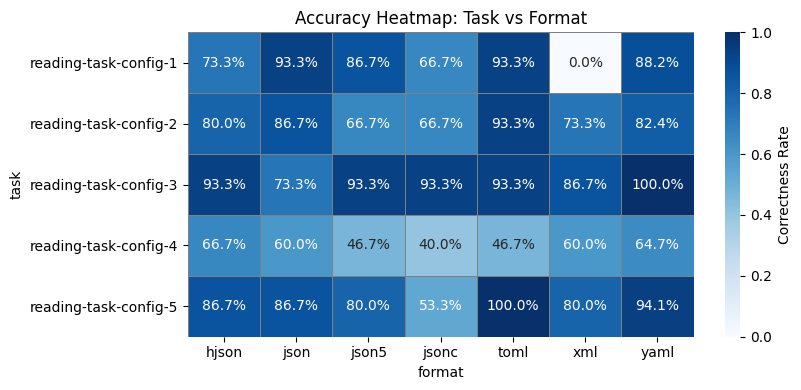

In [14]:
# 只看 task1, task3, task5 三个任务：
visualize_accuracy_heatmap(
    df_reading_agg,
    task_col='task',
    format_col='format',
    accuracy_col='correct',
    task_list=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4','reading-task-config-5'],
    cmap='Blues',
    annot=True,
    fmt='.1%', 
    cbar_label='Correctness Rate'
)

# # 只看 yaml 和 xml 两种格式：
# visualize_accuracy_heatmap(
#     df_reading_clean,
#     task_col='task',
#     format_col='format',
#     accuracy_col='correctness',
#     format_list=['yaml','xml'],
#     cmap='YlGnBu'
# )

# # 既过滤任务，也过滤格式
# visualize_accuracy_heatmap(
#     df_reading_clean,
#     task_col='task',
#     format_col='format',
#     accuracy_col='correctness',
#     task_list=['reading-task-config-2','reading-task-config-4'],
#     format_list=['json','json5'],
#     cmap='Purples'
# )


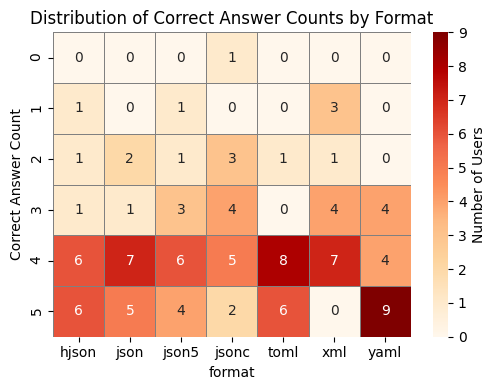

In [15]:
visualize_score_distribution_heatmap(
    df_reading_result,
    participant_col='participantId',
    task_col='task',
    format_col='format',
    correct_col='correct',
    cmap='OrRd',
    annot=True,
    fmt='d',
    cbar_label='Number of Users'
)


## Post Task Question Analysis

### statistical test

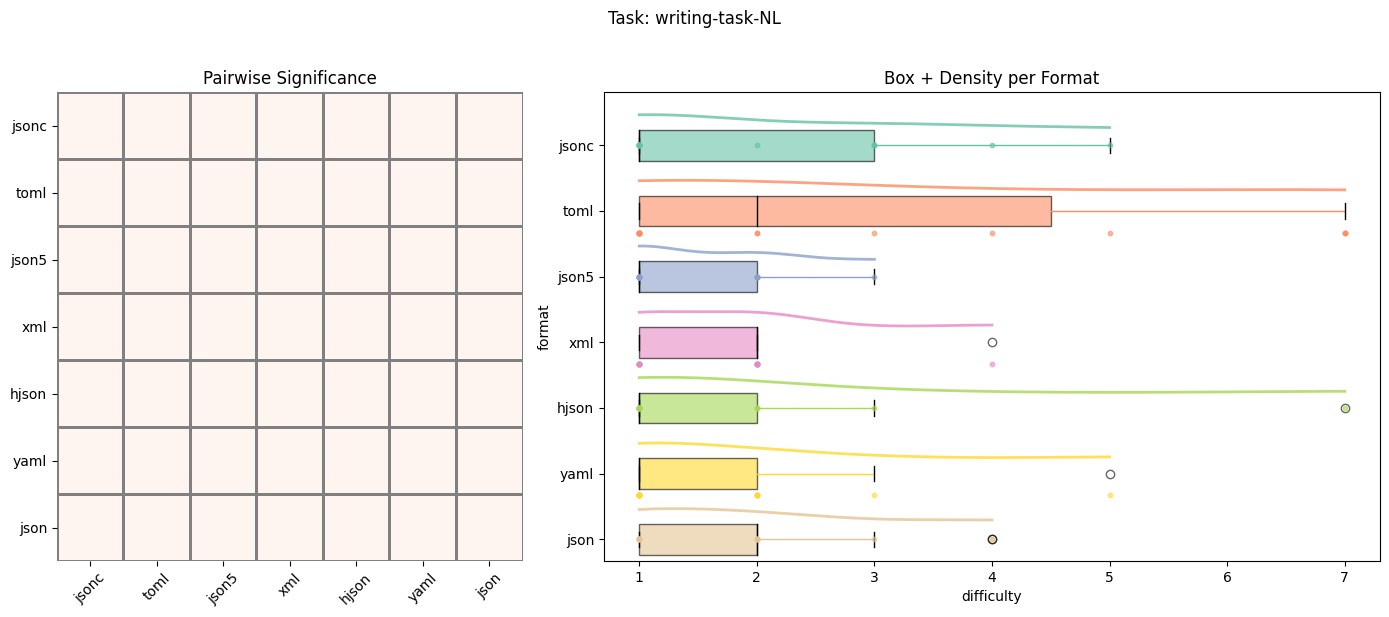

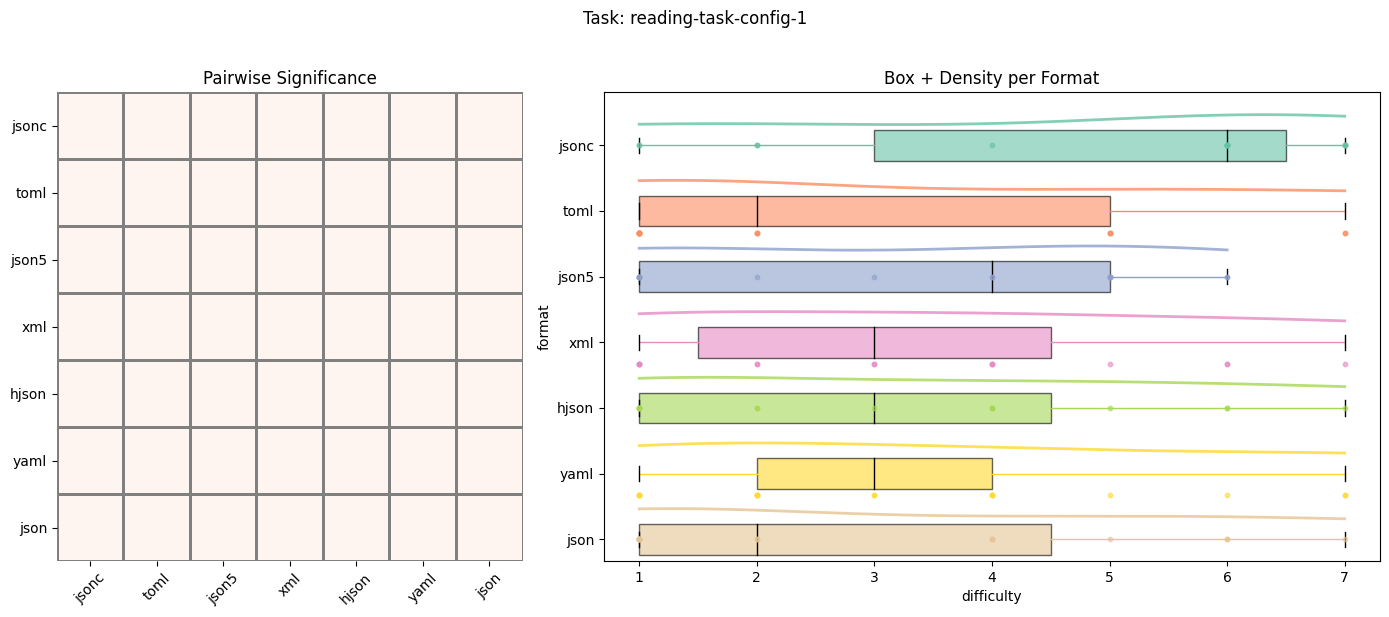

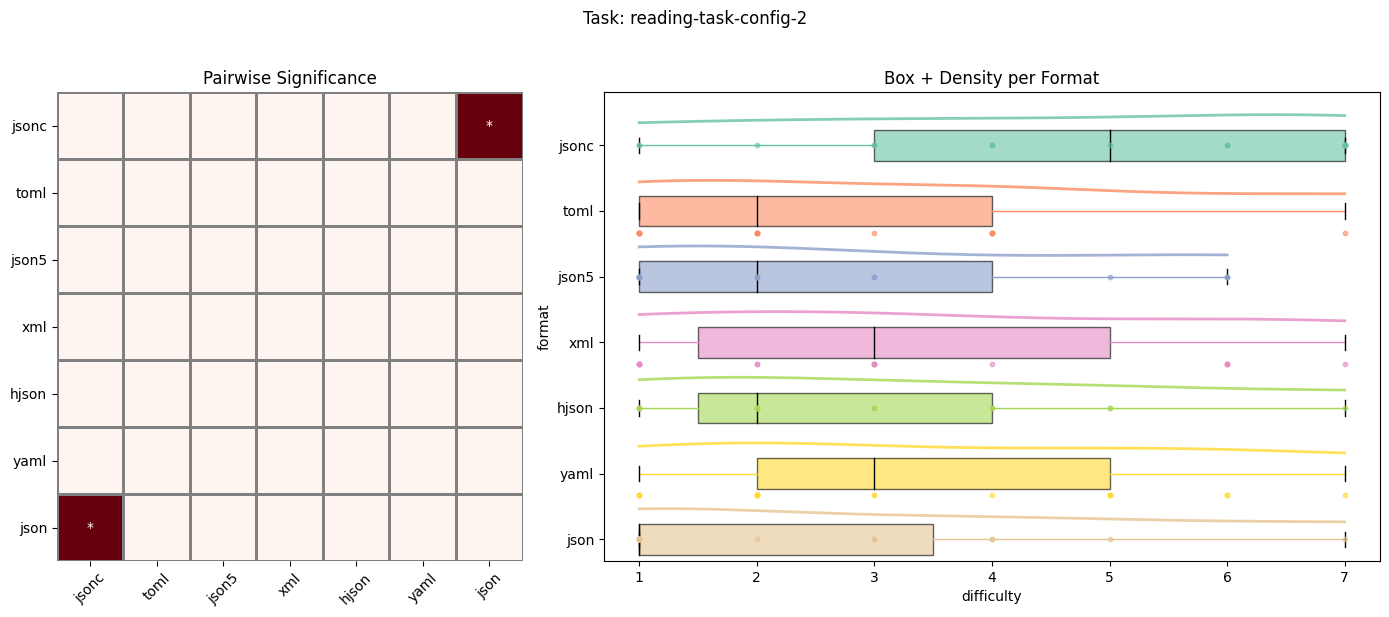

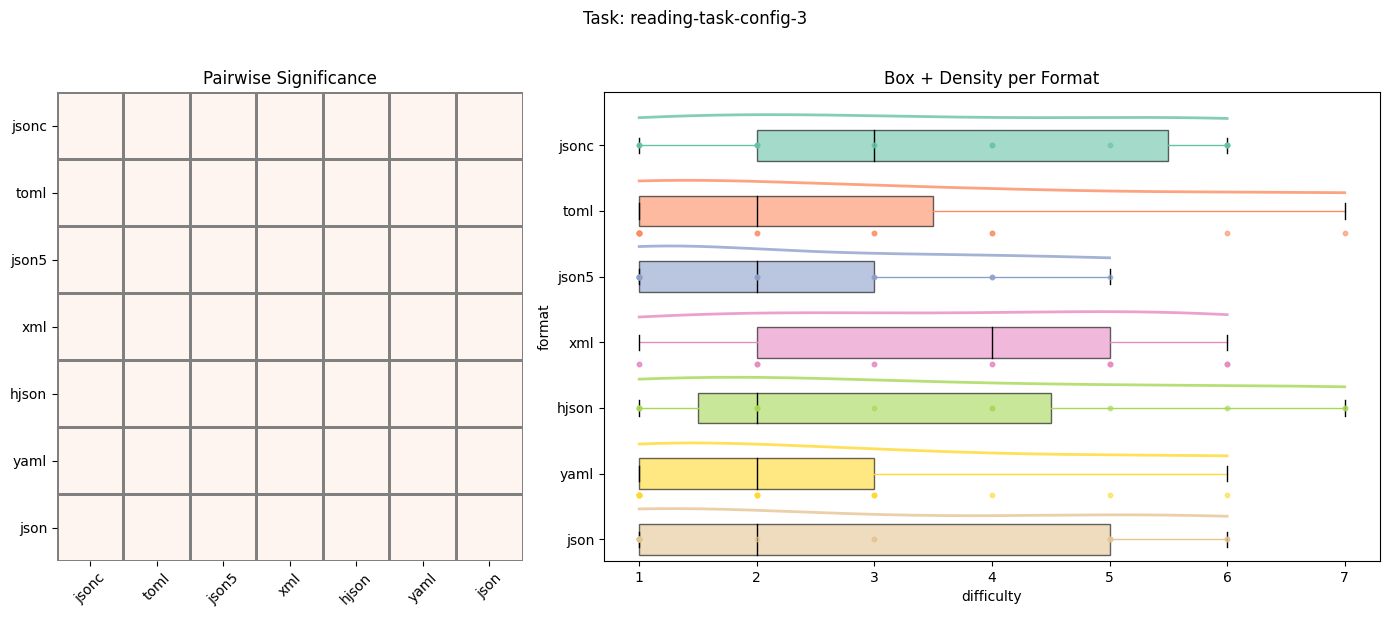

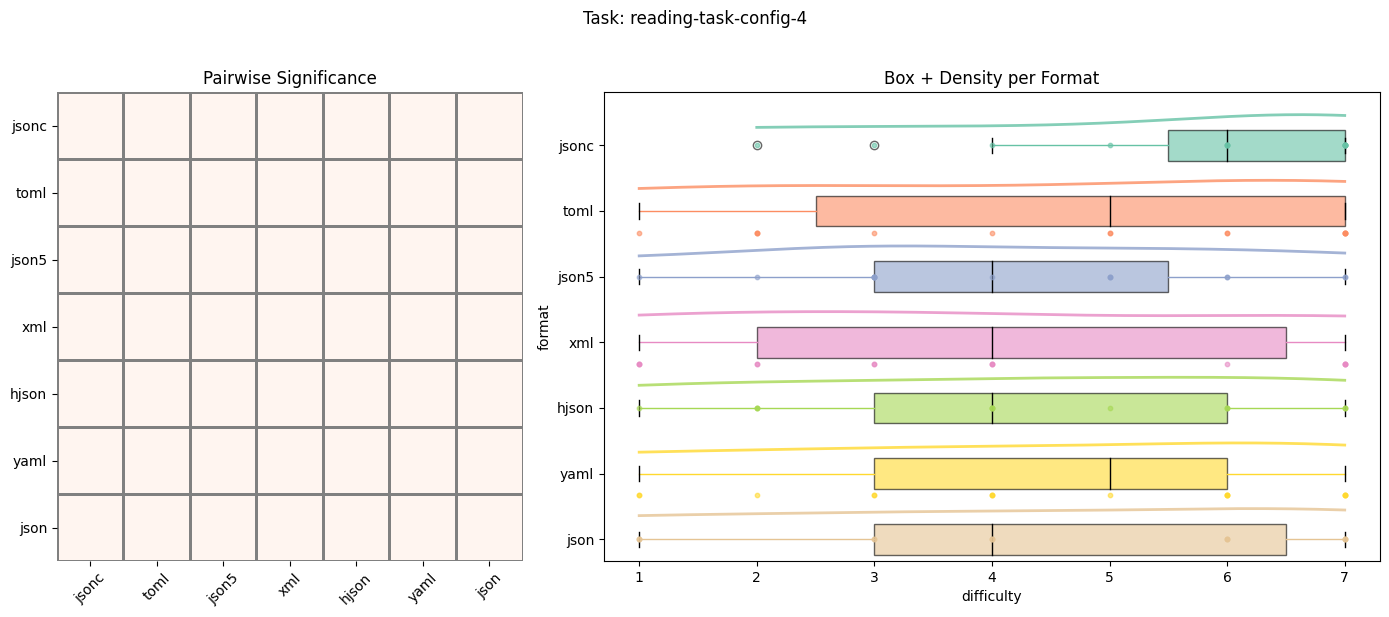

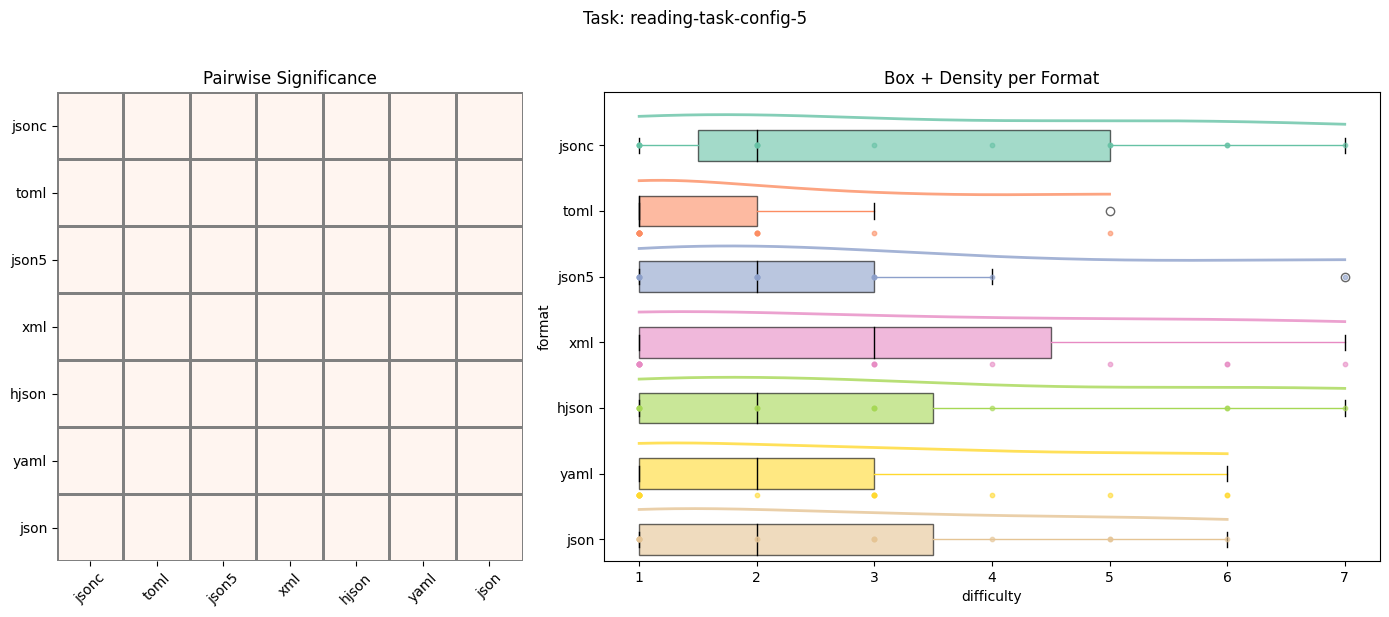

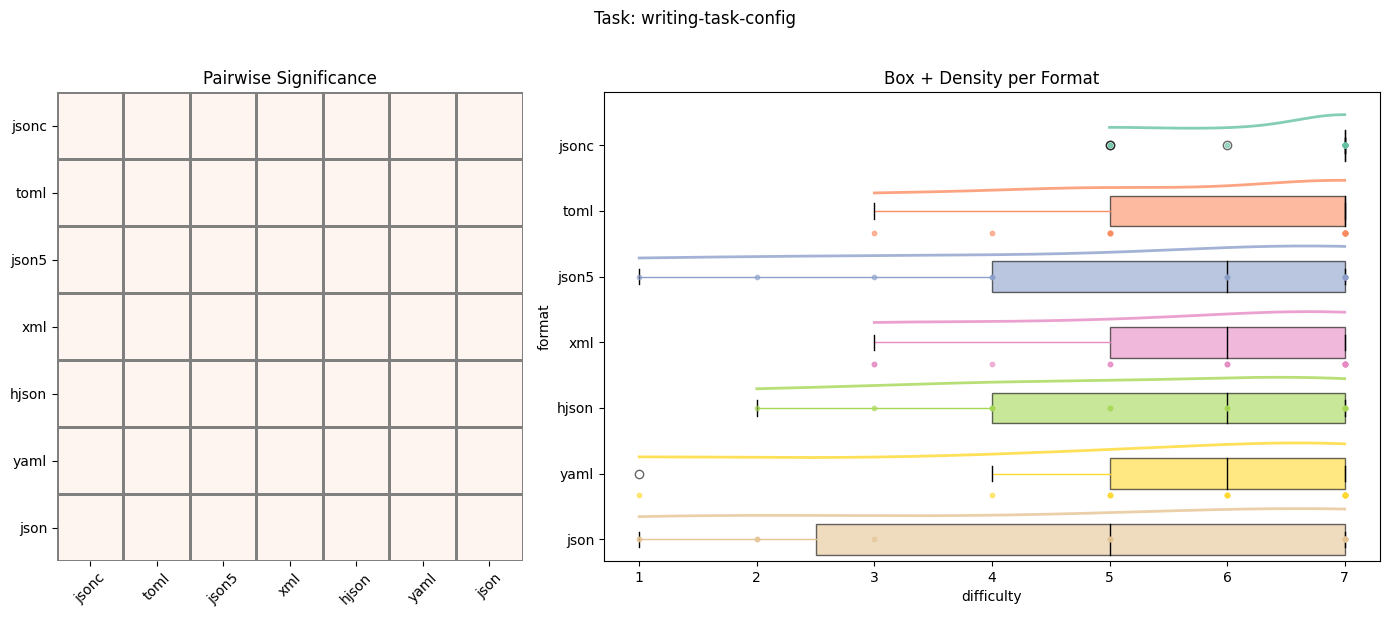

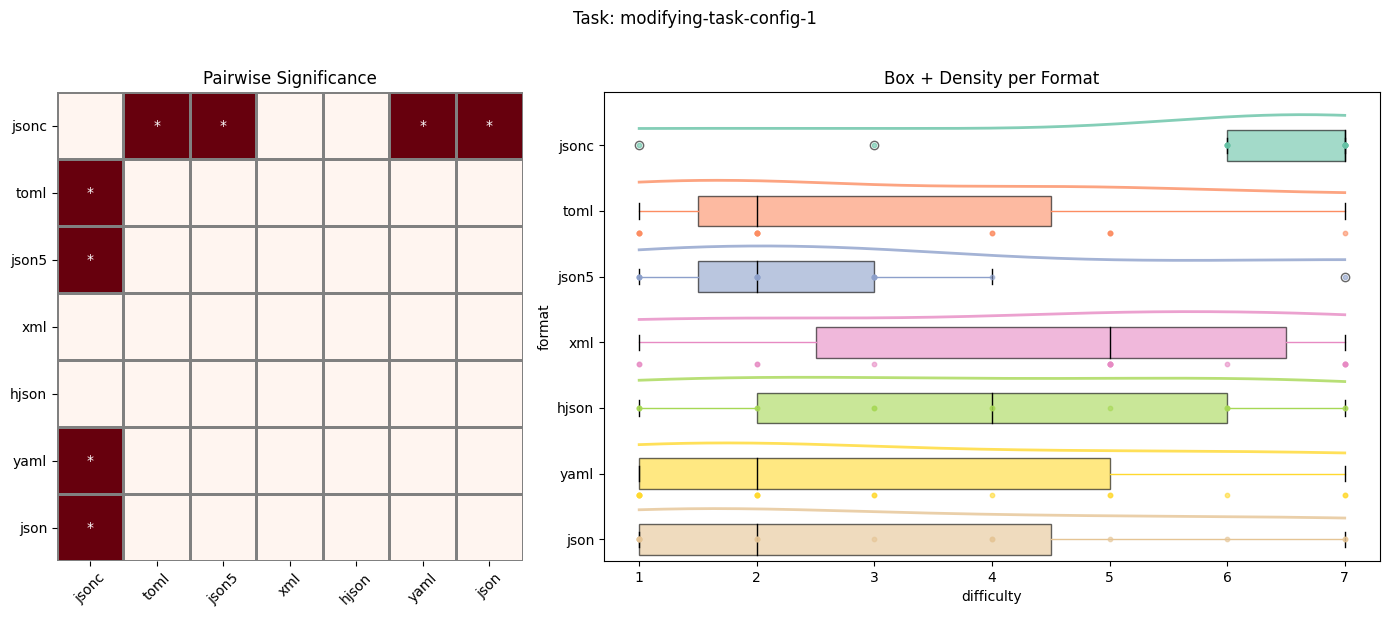

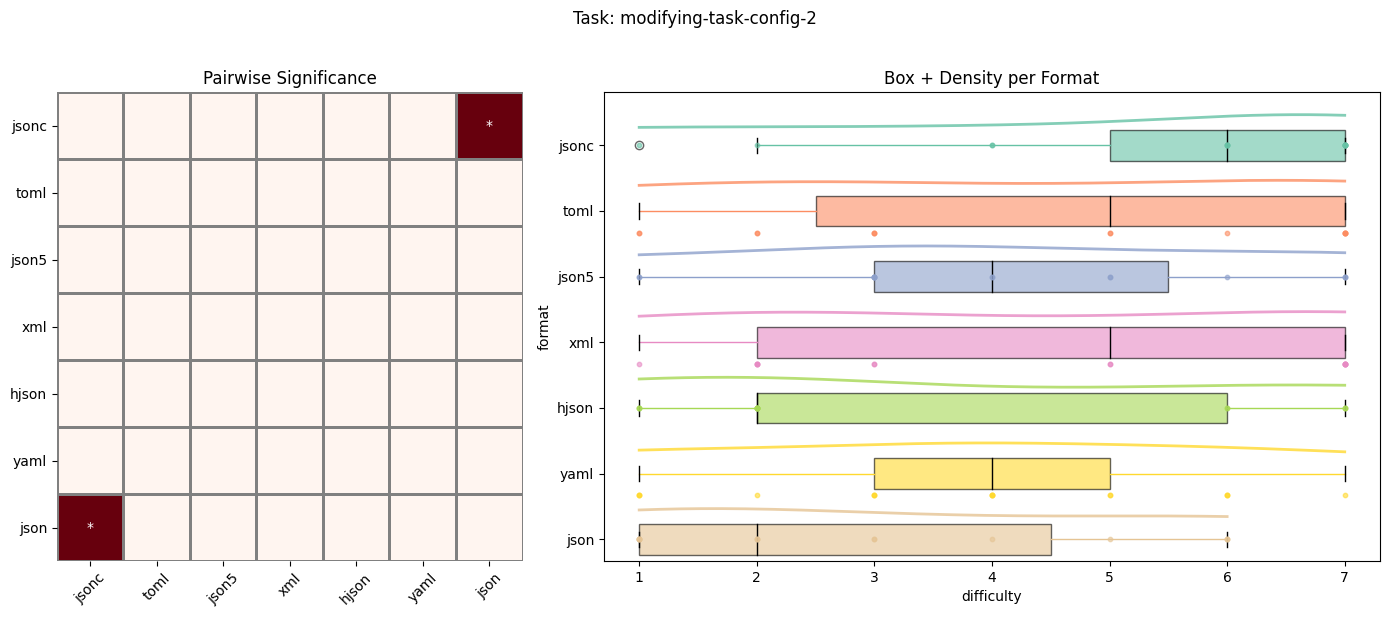

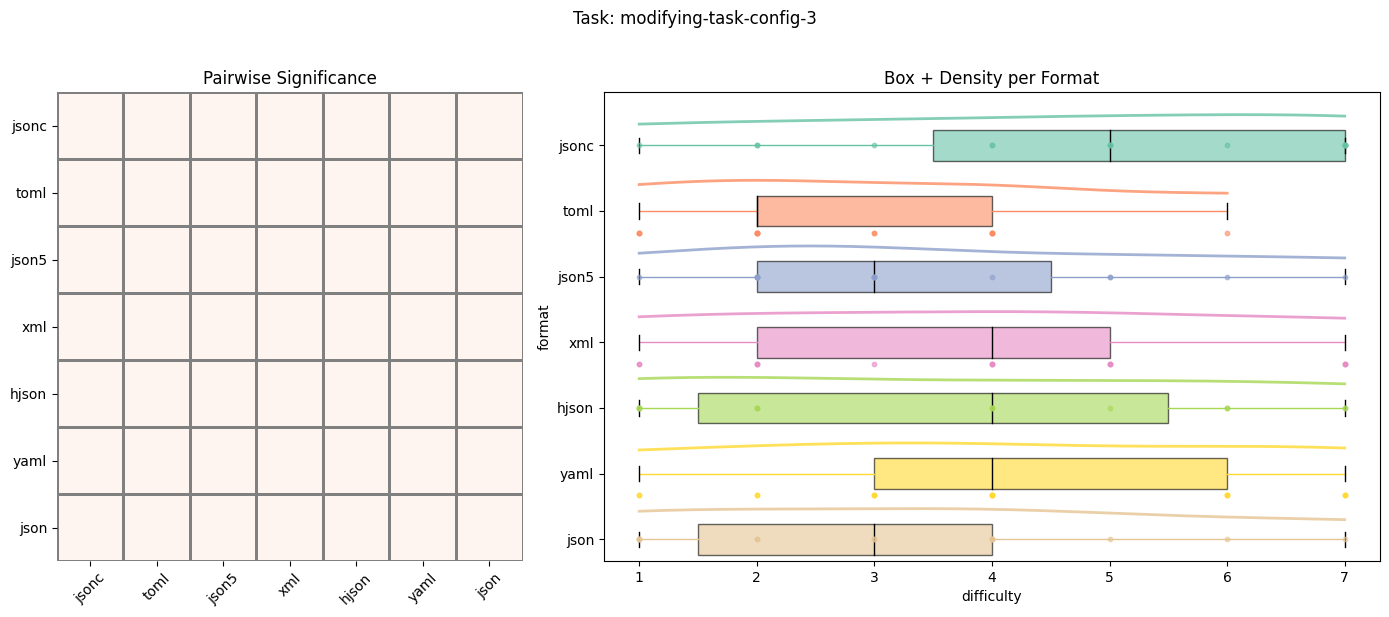

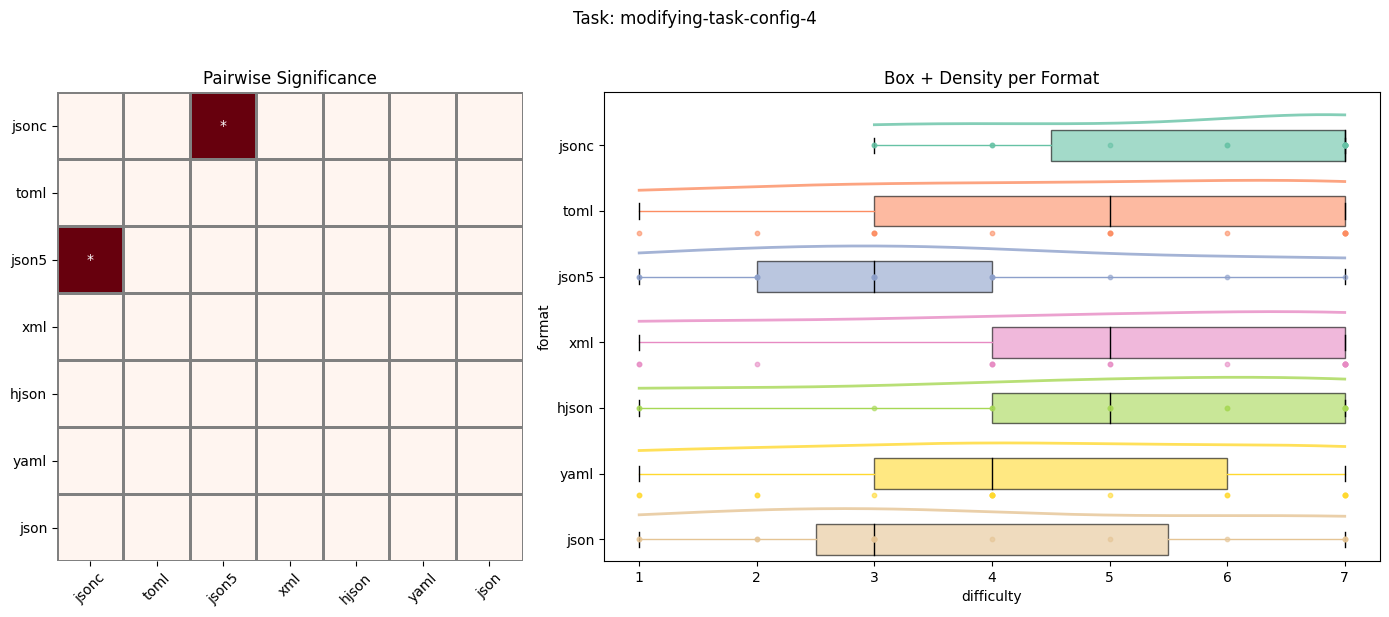

{'modifying-task-config-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      15  3.866667  2.199567     4.0    1    7
  json       15  3.133333  2.231805     2.0    1    7
  json5      15  2.466667  1.552264     2.0    1    7
  jsonc      15  6.000000  1.732051     7.0    1    7
  toml       15  2.933333  1.907379     2.0    1    7
  xml        15  4.533333  2.199567     5.0    1    7
  yaml       17  3.117647  2.147160     2.0    1    7,
  'overall_p': 6.658324871465283e-05,
  'effect_size': 0.2460645347633216,
  'is_significant': True,
  'pairwise':    group1 group2  p_value  significant                     interpretation
  0   hjson   json   0.9535        False   hjson vs json is not significant
  1   hjson  json5   0.4828        False  hjson vs json5 is not significant
  2   hjson  jsonc   0.0665        False  hjson vs jsonc 

In [75]:
## reading tasks
df_post = extract_post_task_questions(all_data)

vis_box_comparasion(
    df_post,
    group_col='format',
    value_col='difficulty',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

post_d_results = compare_statistically(
    df_post,
    group_col='format',
    value_col='difficulty',
    method='anova',
    task_col='task'
)

post_d_results

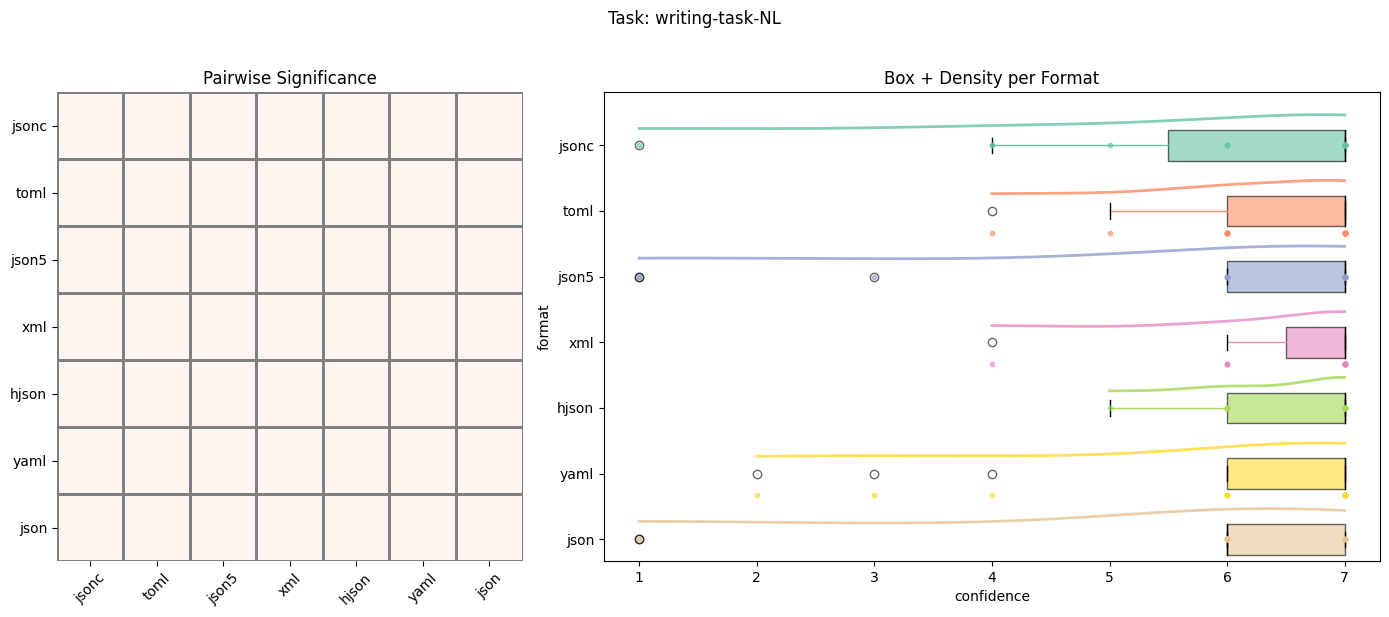

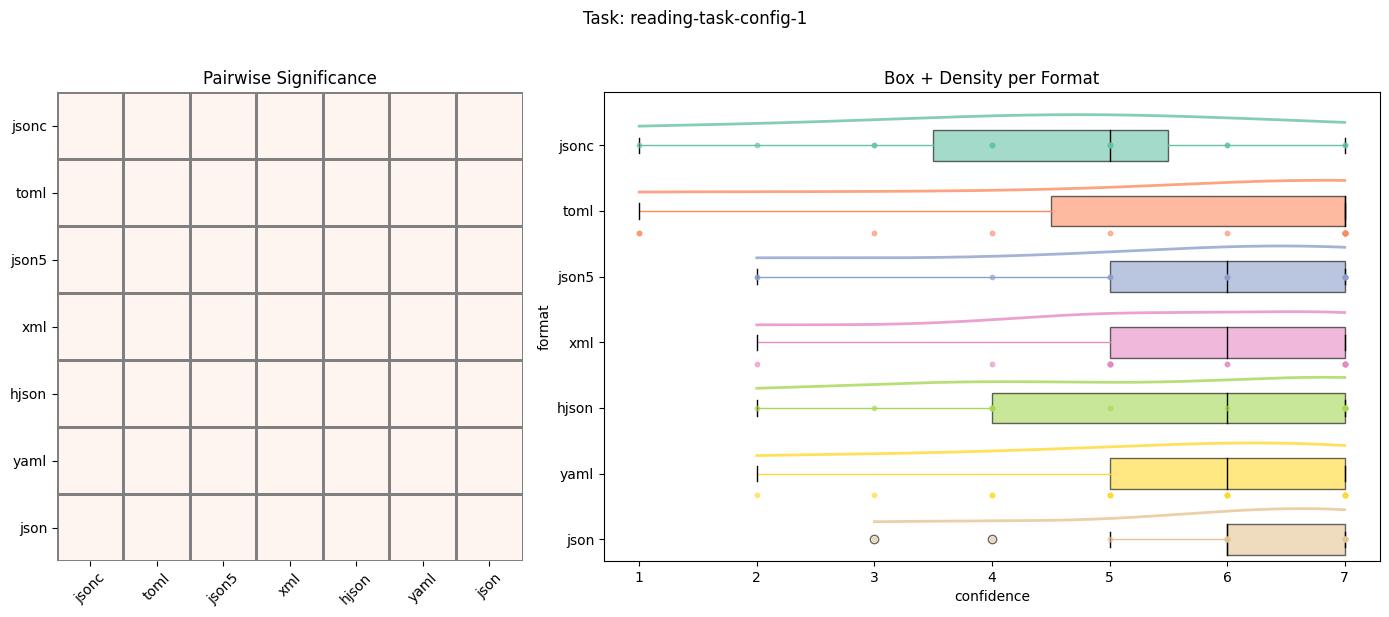

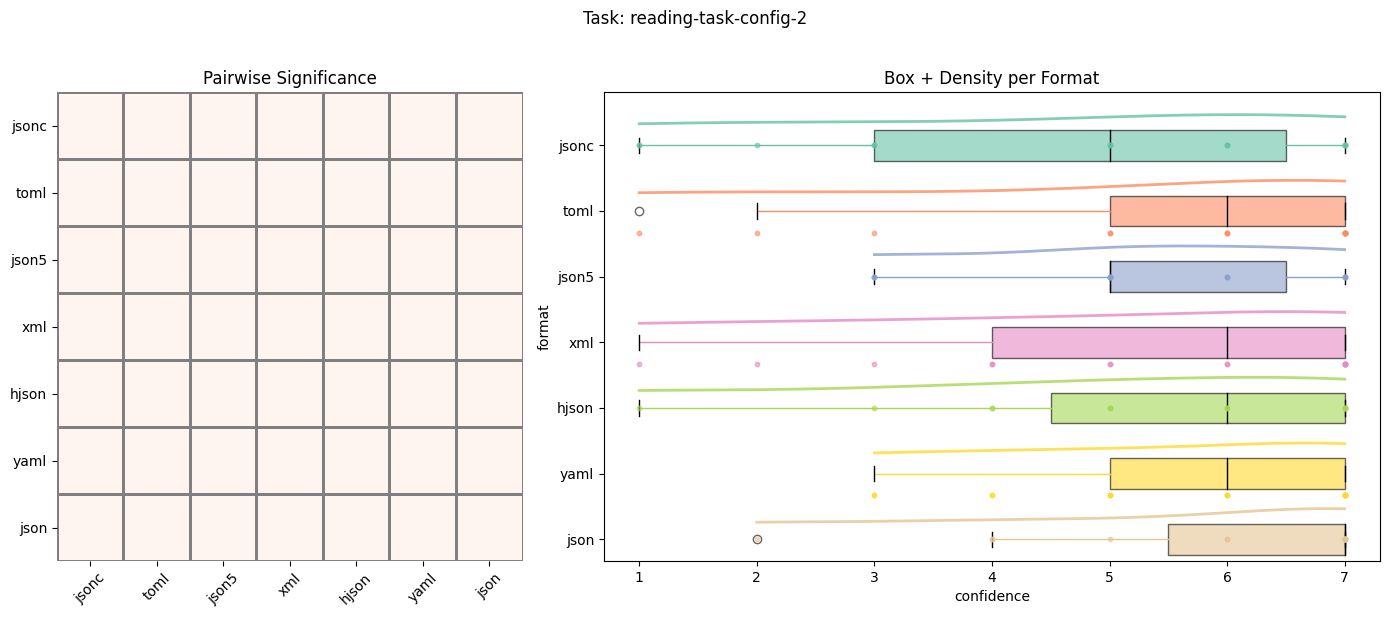

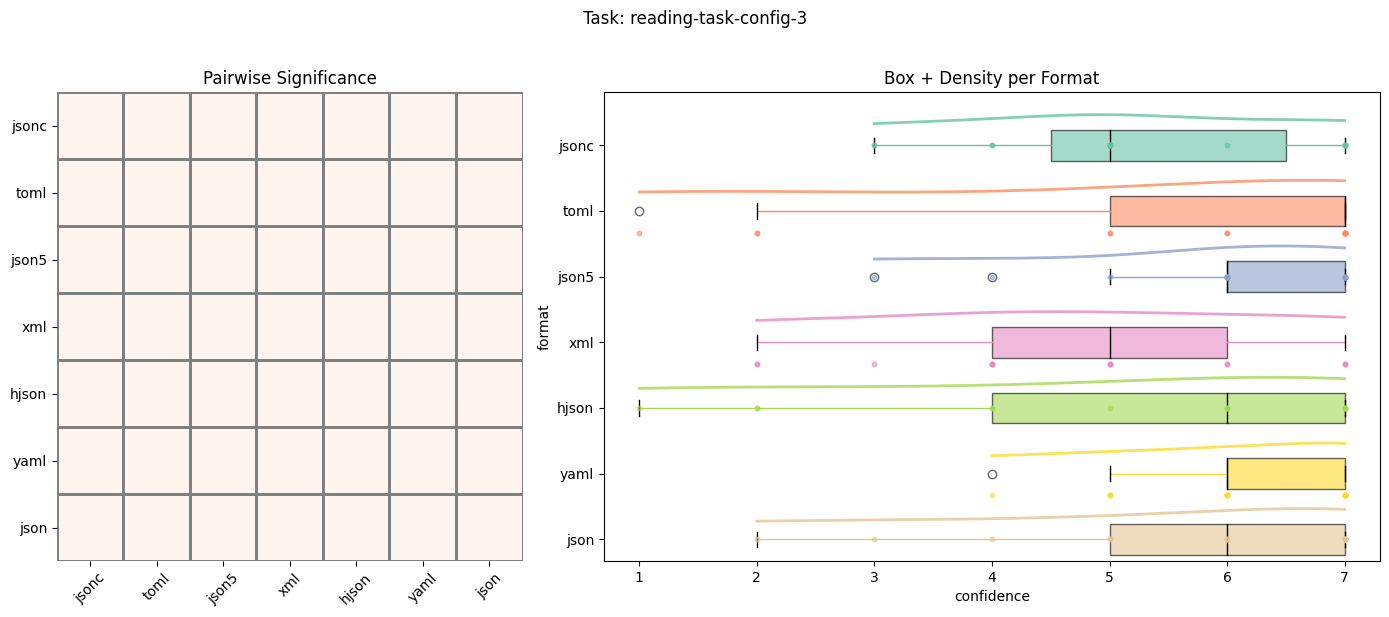

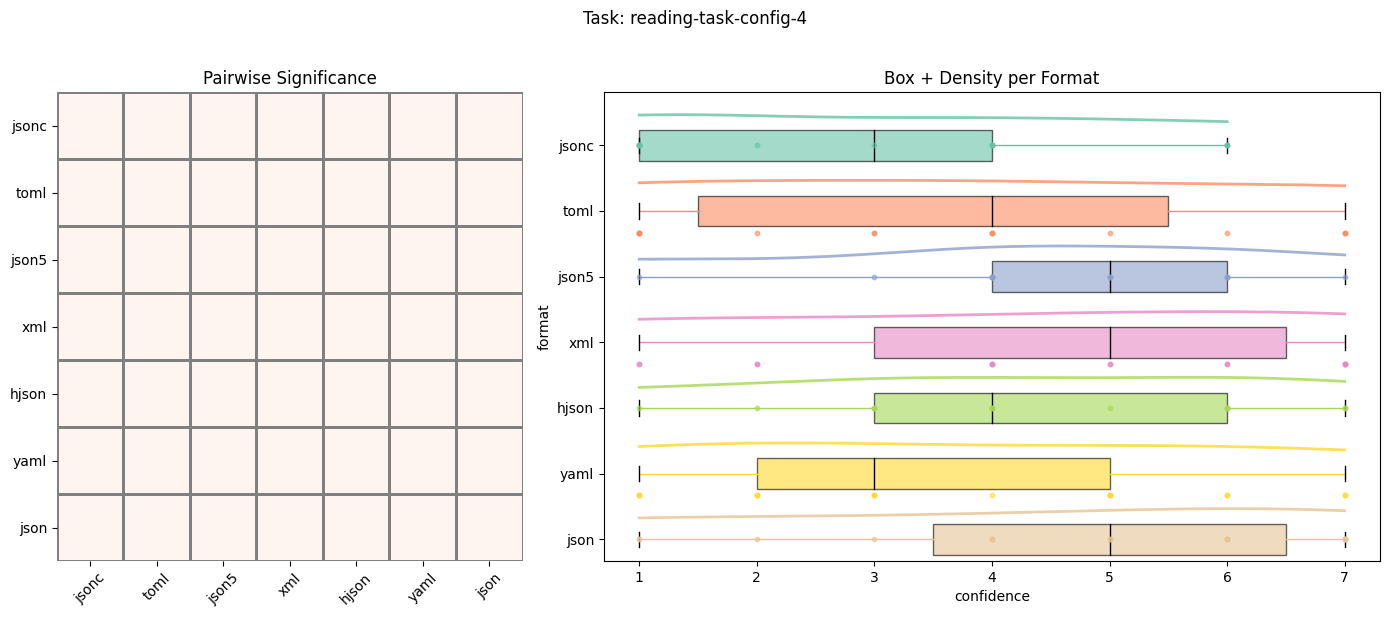

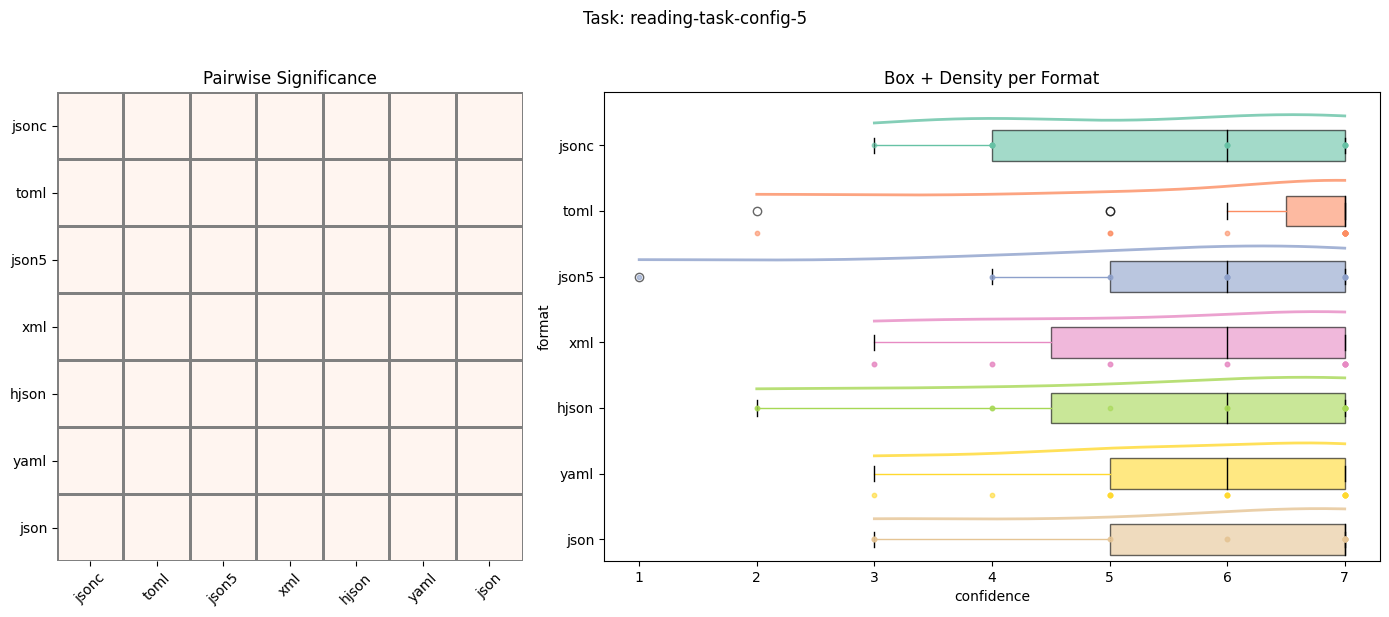

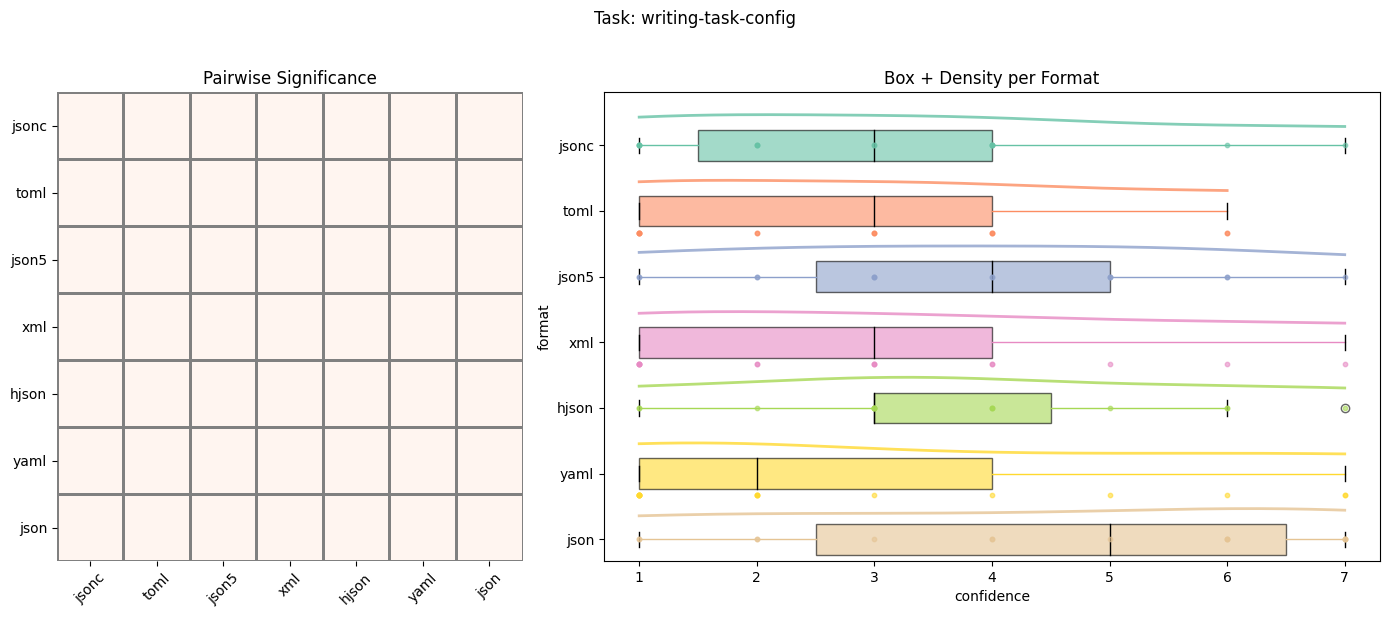

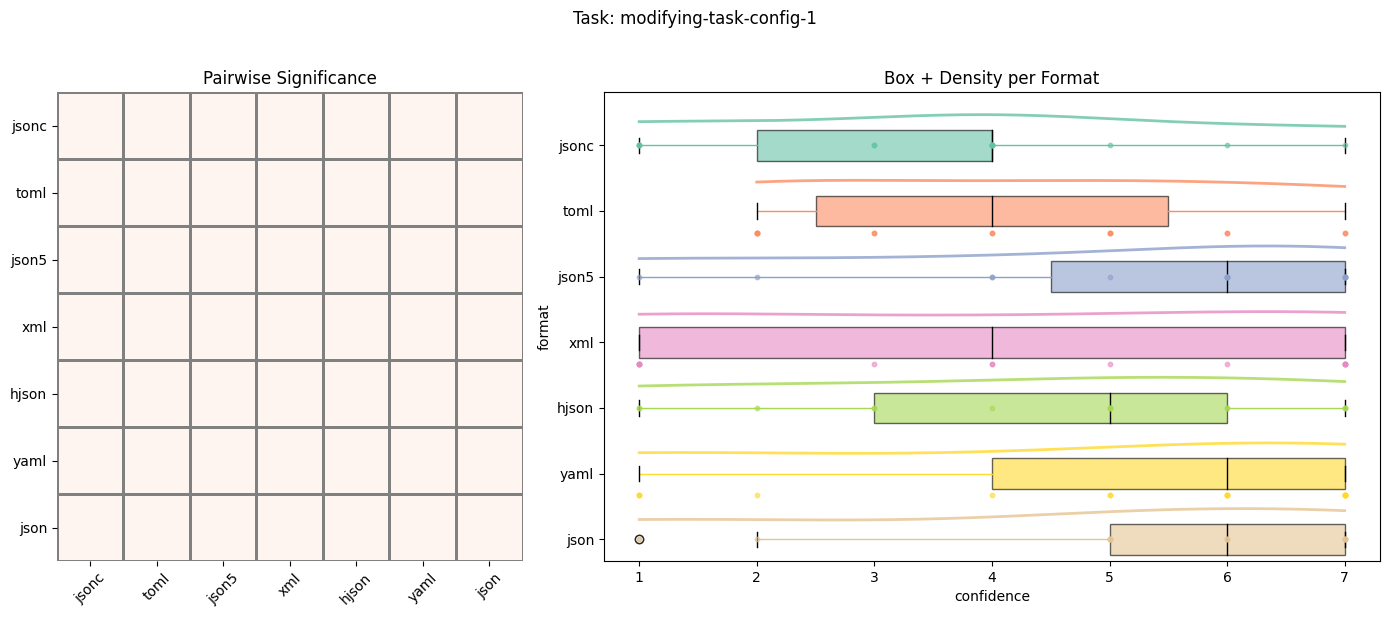

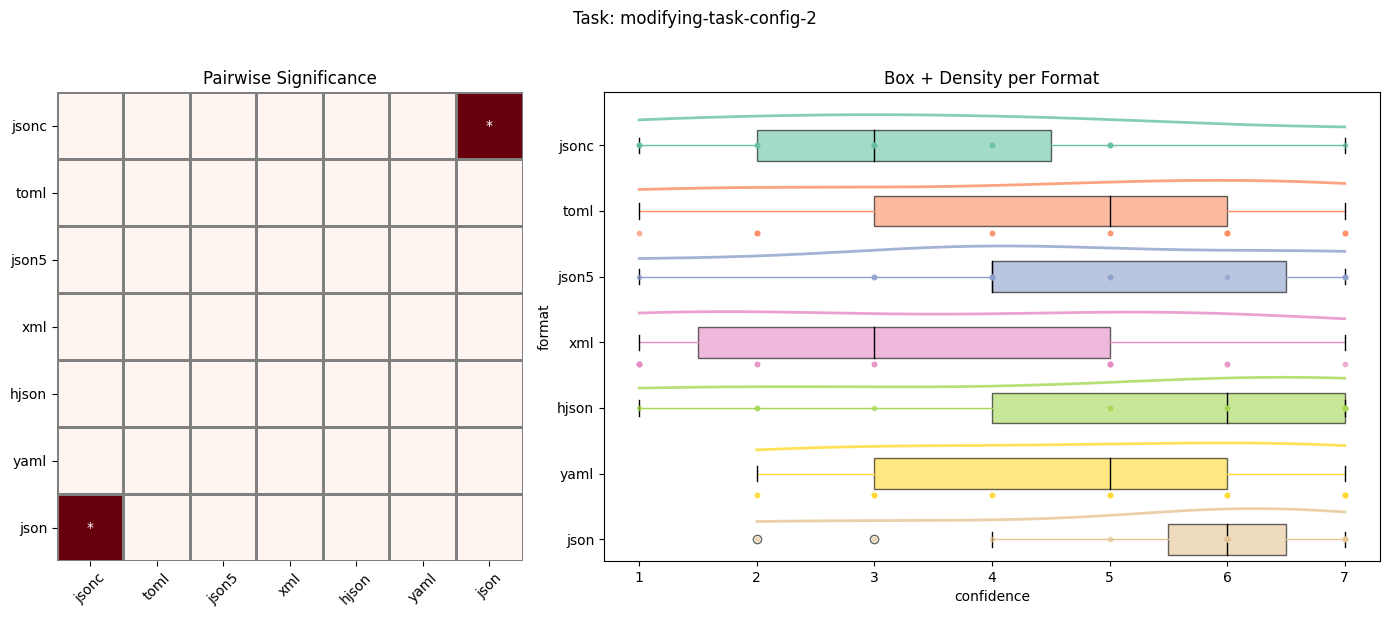

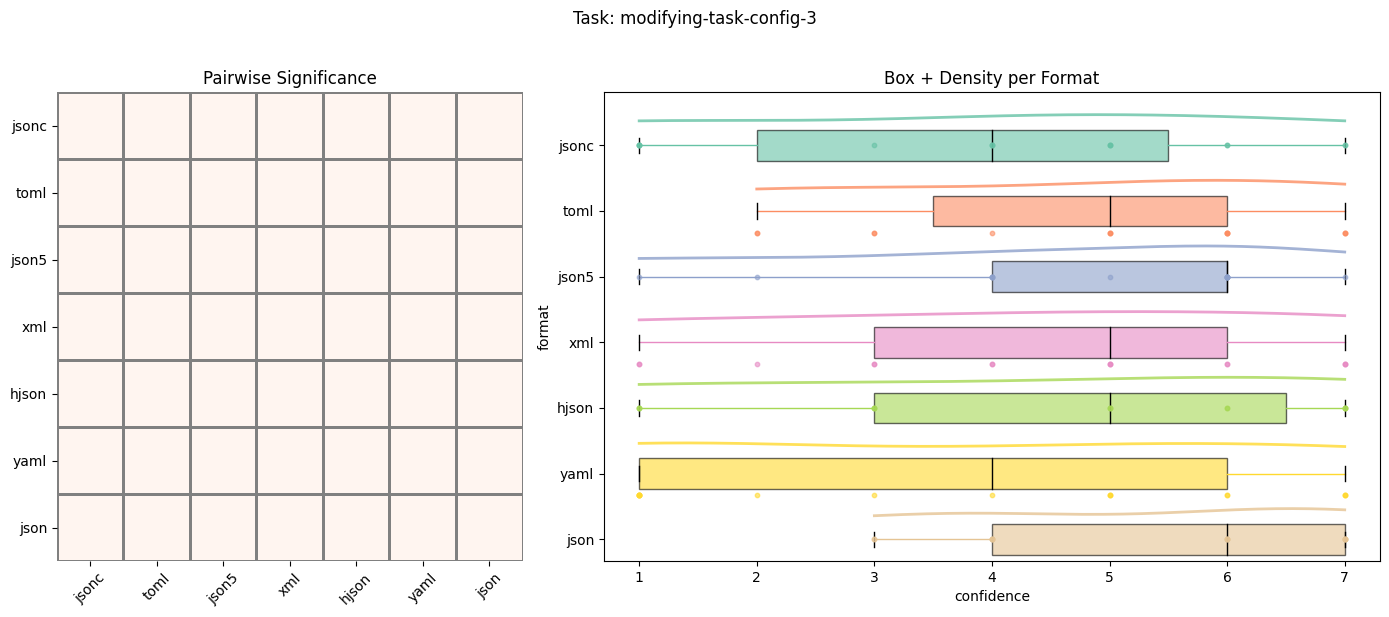

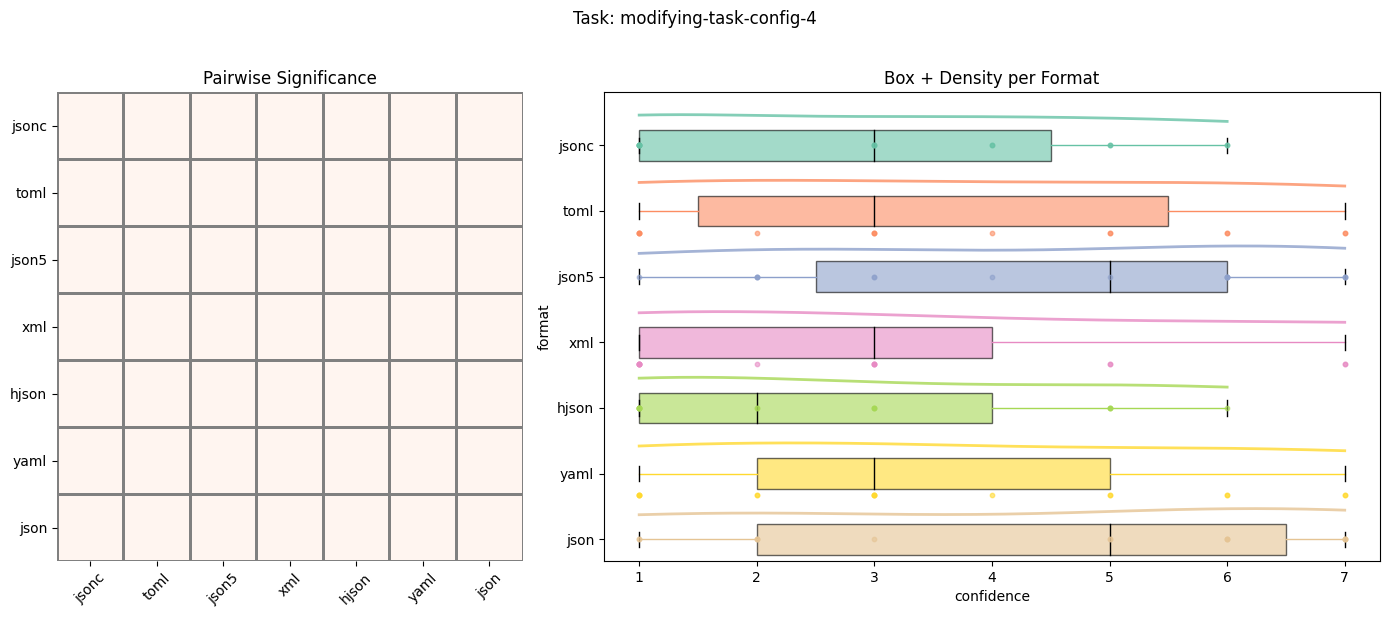

{'modifying-task-config-1': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  format                                             
  hjson      15  4.466667  2.065591     5.0    1    7
  json       15  5.133333  2.133631     6.0    1    7
  json5      15  5.400000  1.882248     6.0    1    7
  jsonc      15  3.466667  1.846490     4.0    1    7
  toml       15  4.200000  1.820518     4.0    2    7
  xml        15  4.133333  2.614975     4.0    1    7
  yaml       17  5.000000  2.318405     6.0    1    7,
  'overall_p': 0.1722928328479406,
  'effect_size': 0.084682418699187,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'modifying-task-config-2': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count      mean       std  median  min  max
  

In [76]:
## reading tasks
vis_box_comparasion(
    df_post,
    group_col='format',
    value_col='confidence',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    # continuous_tasks=['reading-task']
)

post_c_results = compare_statistically(
    df_post,
    group_col='format',
    value_col='confidence',
    method='anova',
    task_col='task'
    # discrete_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5'],
    # continuous_tasks=['reading-task']
)

post_c_results

### correct vs difficulty/confidence

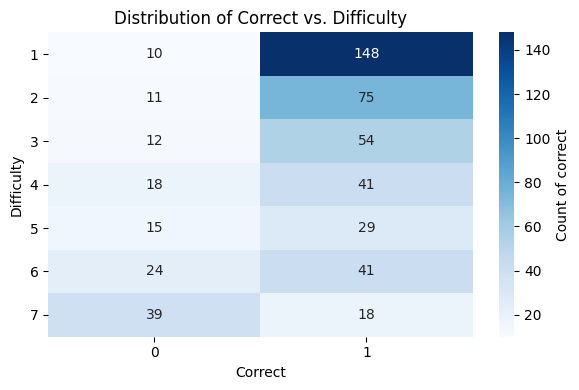

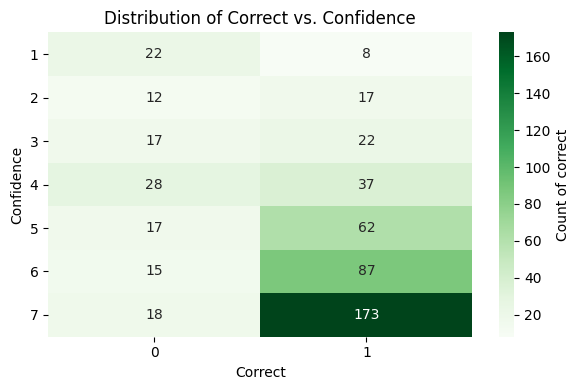

In [18]:
# 比较 correct(0/1) vs difficulty
df_post_reading= df_post[df_post['task'].str.contains('reading-task')]
plot_binary_response_vs_metric_heatmap(
    df_post      = df_post_reading,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    response_col   ='correct',
    metric_col     ='difficulty',
    response_values=[0,1],    # 二元回答
    cmap='Blues'
)

# 比较 correct(0/1) vs confidence
plot_binary_response_vs_metric_heatmap(
    df_post      = df_post_reading,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    response_col   ='correct',
    metric_col     ='confidence',
    response_values=[0,1],
    cmap='Greens'
)


## Nasa Tlx Analysis

### statistical test

In [19]:
df_nasa = analyze_nasa_and_post_surveys(all_data)
df_nasa['task']='nasaltx'
df_nasa_tidy = melt_tlx(df_nasa)
df_nasa_tidy

,participantId,format,startTime,endTime,duration_sec,task,score
0,67895b7d6400163124042af7,jsonc,1747336946502,1747336981574,35.072,mental-demand,90
1,659960f32faa4ff4b116de92,toml,1747175794991,1747175841492,46.501,mental-demand,100
2,5f7f239e9b204e05b6c36538,json5,1746773792213,1746773826494,34.281,mental-demand,98
3,67b8636acd5ed420cc098b64,toml,1747178361717,1747178406544,44.827,mental-demand,99
4,57ca4b09993b08000192297b,xml,1747174420084,1747174450113,30.029,mental-demand,90
...,...,...,...,...,...,...,...
637,5755c957eb80c4000741a9ce,json5,1747173778388,1747173809509,31.121,frustration,5
638,6693d3ae2bd15cf7a058e6a7,json5,1746772510562,1746772572090,61.528,frustration,45
639,60e2bf0aa568b97e8d525872,toml,1746770374173,1746770474998,100.825,frustration,30
640,67d24179c5bd87691f1fe036,yaml,1746770060839,1746770091459,30.620,frustration,25


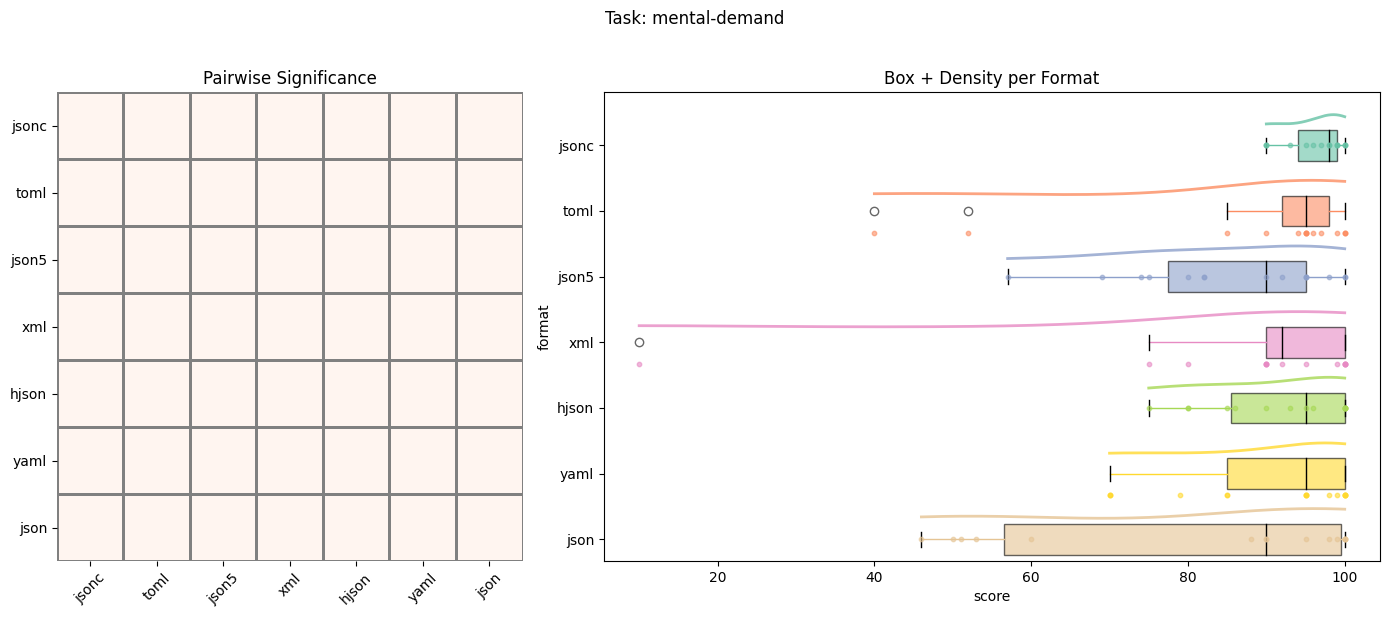

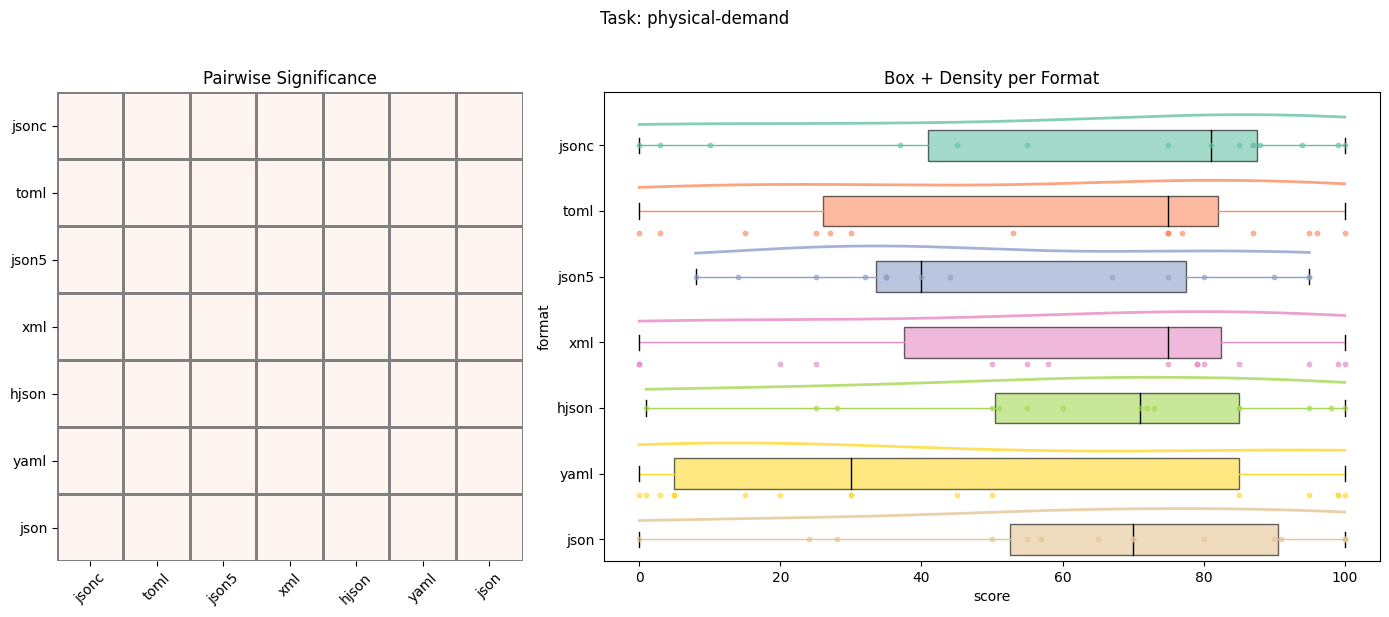

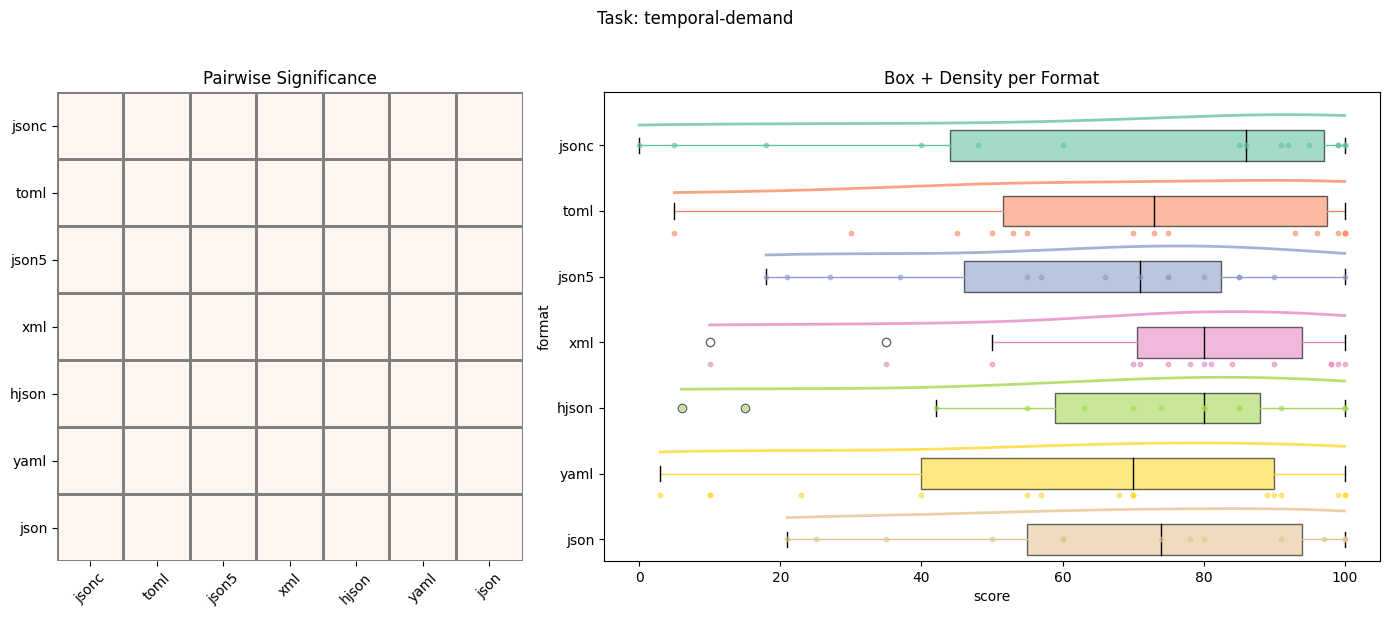

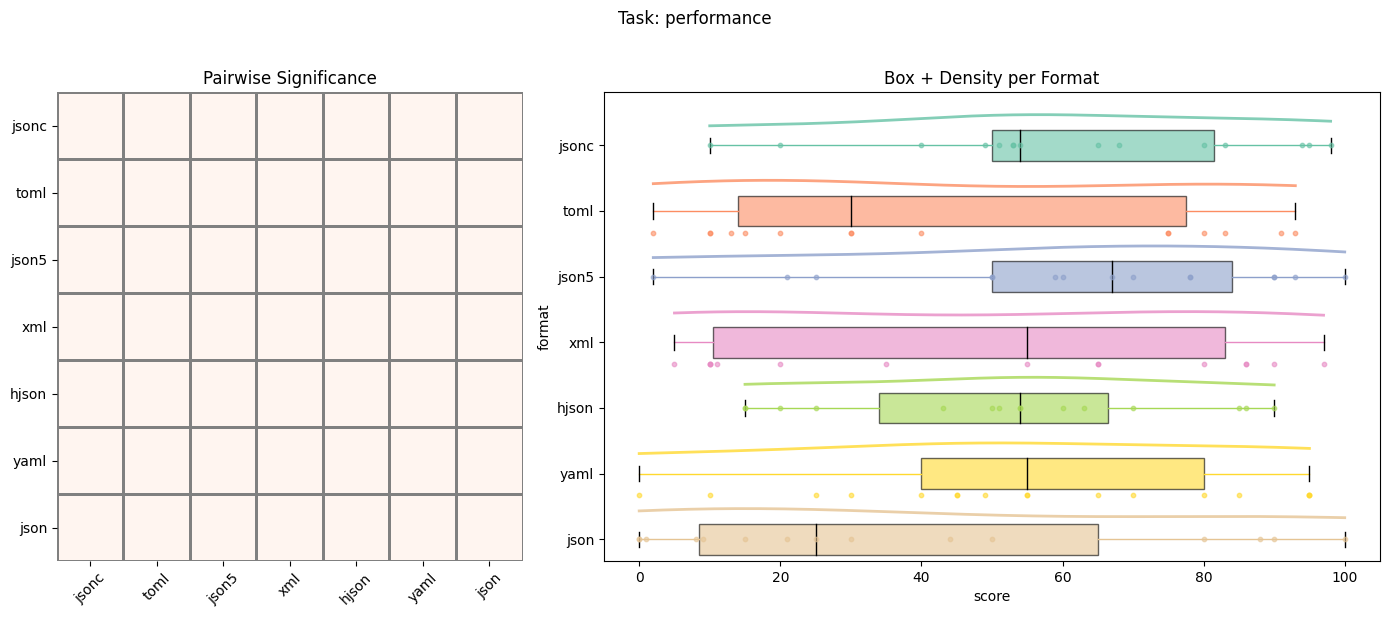

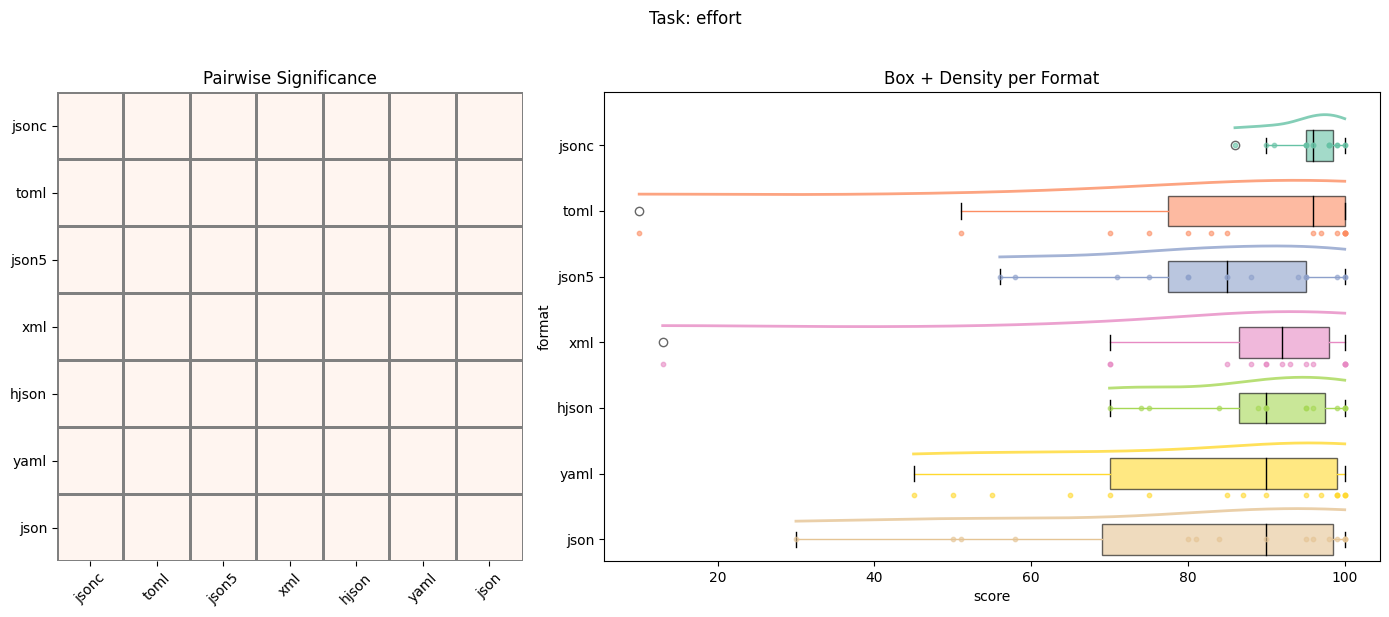

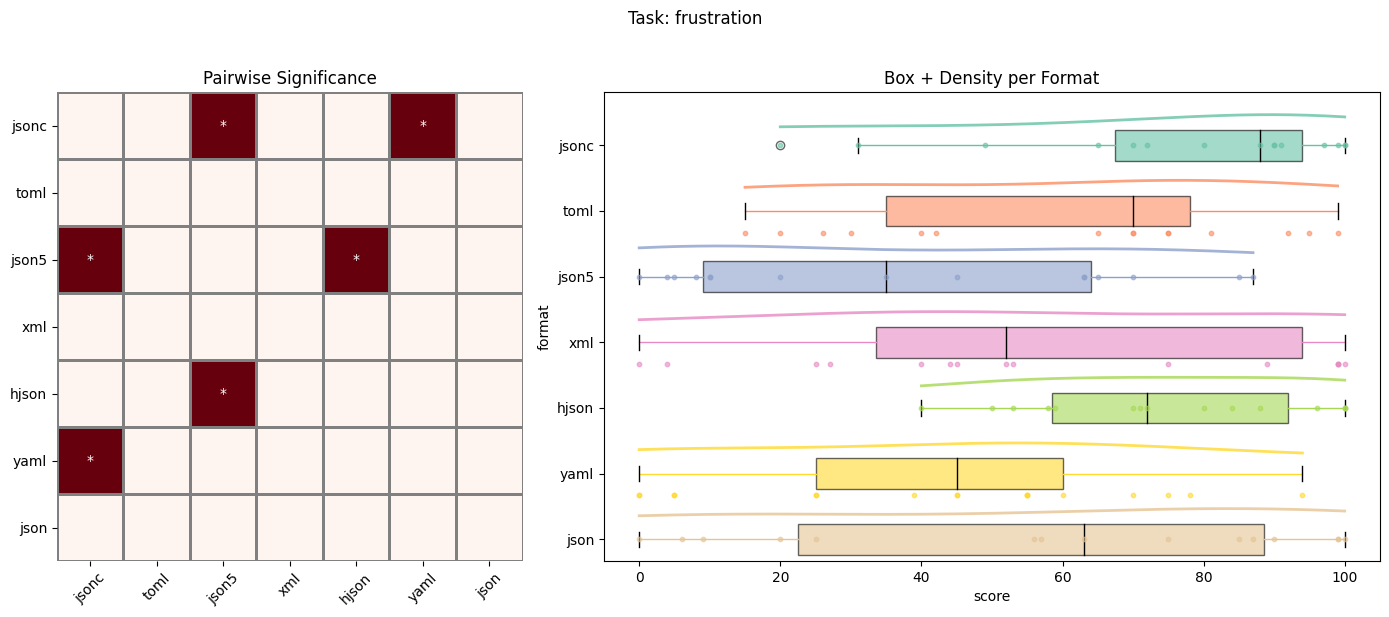

{'effort': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count       mean        std  median  min  max
  format                                               
  hjson      15  89.800000   9.944130    90.0   70  100
  json       15  80.800000  22.675348    90.0   30  100
  json5      15  84.066667  14.240118    85.0   56  100
  jsonc      15  95.733333   4.008325    96.0   86  100
  toml       15  83.066667  24.878179    96.0   10  100
  xml        15  85.466667  22.238534    92.0   13  100
  yaml       17  83.000000  19.232135    90.0   45  100,
  'overall_p': 0.31308613574965405,
  'effect_size': 0.06711611069969932,
  'is_significant': False,
  'pairwise': Empty DataFrame
  Columns: [group1, group2, p_value, significant, interpretation]
  Index: [],
  'warning': None},
 'frustration': {'method': 'anova',
  'alpha': 0.05,
  'p_adjust_method': 'bonferroni',
  'descriptive':         count       mean        std  median  min  max
  format

In [74]:
vis_box_comparasion(
    df_nasa_tidy,
    group_col='format',
    value_col='score',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

results = compare_statistically(
    df_nasa_tidy,
    group_col='format',
    value_col='score',
    method='anova',
    task_col='task'
)

results

### correct vs nasa metrics

In [72]:
df_nasa

,participantId,format,startTime,endTime,duration_sec,mental-demand,physical-demand,temporal-demand,performance,effort,frustration,task
0,67895b7d6400163124042af7,jsonc,1747336946502,1747336981574,35.072,90,87,86,68,86,100,nasaltx
1,659960f32faa4ff4b116de92,toml,1747175794991,1747175841492,46.501,100,100,70,10,100,70,nasaltx
2,5f7f239e9b204e05b6c36538,json5,1746773792213,1746773826494,34.281,98,40,71,78,99,87,nasaltx
3,67b8636acd5ed420cc098b64,toml,1747178361717,1747178406544,44.827,99,27,73,83,96,99,nasaltx
4,57ca4b09993b08000192297b,xml,1747174420084,1747174450113,30.029,90,0,10,65,85,75,nasaltx
...,...,...,...,...,...,...,...,...,...,...,...,...
102,5755c957eb80c4000741a9ce,json5,1747173778388,1747173809509,31.121,69,14,18,2,56,5,nasaltx
103,6693d3ae2bd15cf7a058e6a7,json5,1746772510562,1746772572090,61.528,57,32,55,90,100,45,nasaltx
104,60e2bf0aa568b97e8d525872,toml,1746770374173,1746770474998,100.825,100,75,100,75,100,30,nasaltx
105,67d24179c5bd87691f1fe036,yaml,1746770060839,1746770091459,30.620,70,5,10,55,90,25,nasaltx


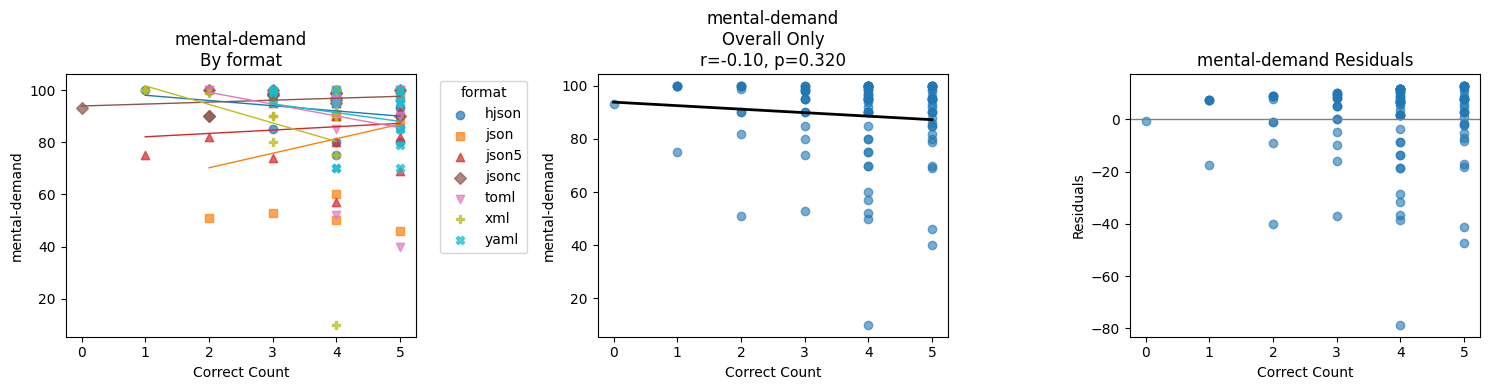

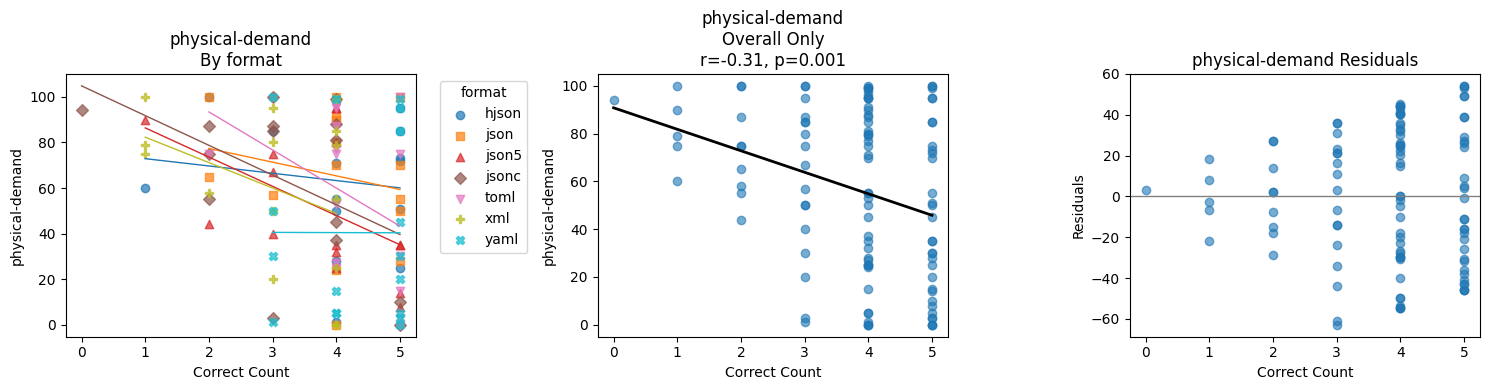

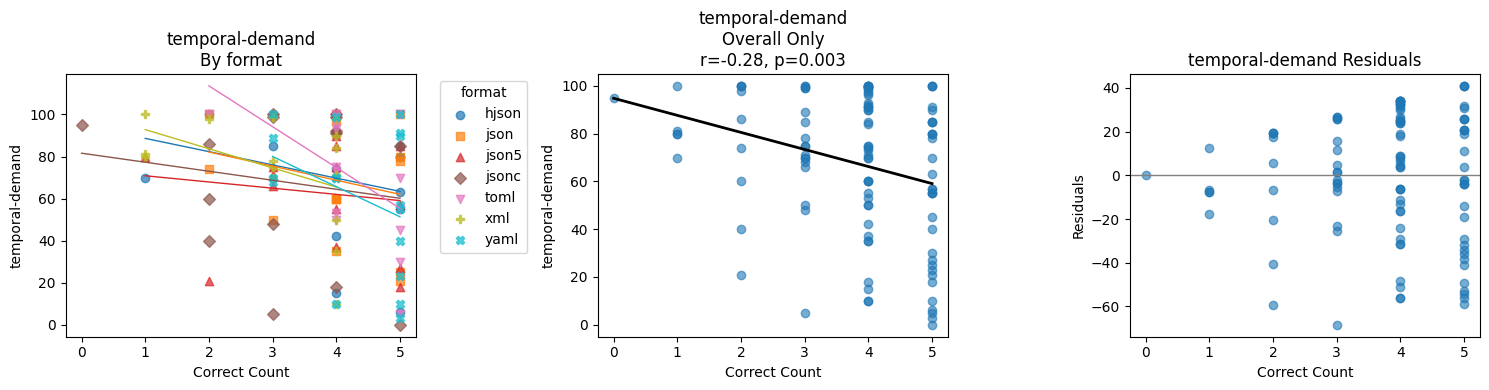

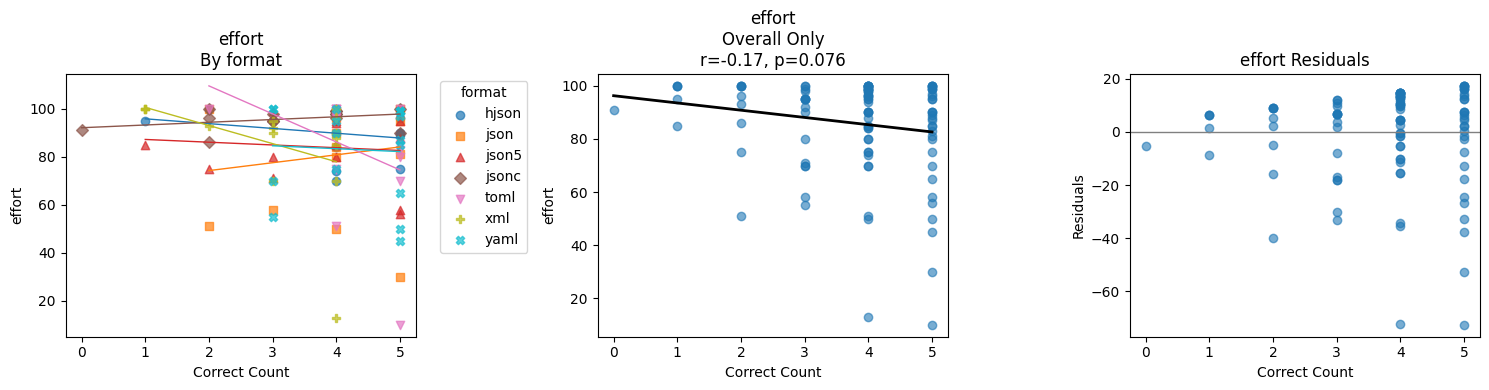

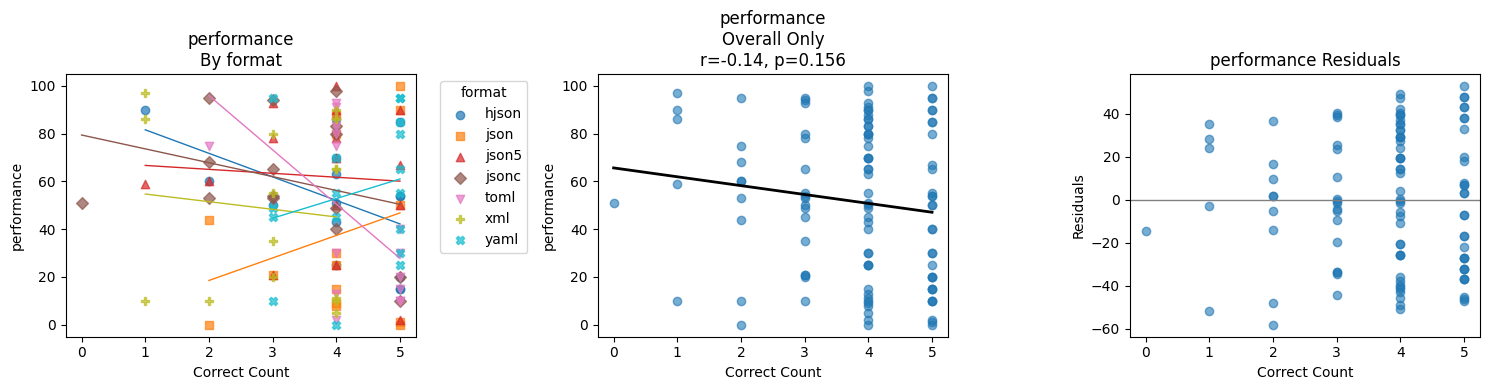

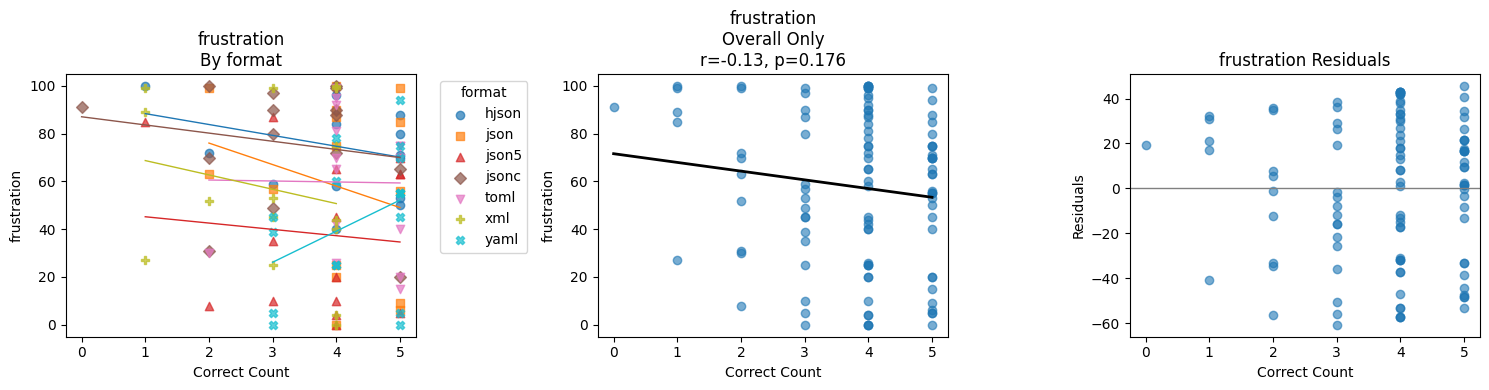

In [73]:
df_reading_agg_overall=df_reading_agg[df_reading_agg['task']=='reading-task-config'].copy() 

plot_nasatlx_correct(
    df_reading         = df_reading_agg_overall,
    df_nasa            = df_nasa,
    metrics            = ['mental-demand','physical-demand','temporal-demand','effort','performance','frustration'],
    group_col          = 'format',
    agg_func           = 'mean',
    show_by_format     = True,   
    show_overall       = True,  
    show_residual      = True,   
    show_overall_trend = False,  
    figsize_per        = (5,4)
)

## Quiz Analysis

### correct

In [22]:
df_quiz = evaluate_quiz_answers_from_tutorial(all_data)
df_quiz_agg = aggregate_quiz_parts(
    df_quiz,
    participant_col='participantId',
    format_col='format',
    task_col='quiz_key',
    sum_cols=['num_wrong_attempts', 'wrong_choice_count'],
    mean_cols=['correct']
)
df_quiz_summary = summarize_quiz_parts(
    df_quiz,
    participant_col='participantId',
    format_col='format',
    task_col='quiz_key',
    sum_cols=['num_wrong_attempts','wrong_choice_count'],
    mean_cols=['correct']
)
df_quiz_summary['task'] = 'tutorial_quiz'
df_quiz_summary

,participantId,format,quiz_key,num_wrong_attempts,wrong_choice_count,correct,task
0,5755c957eb80c4000741a9ce,json5,tutorial-json5,3,3,1.0,tutorial_quiz
1,5795af044a84da00014c5df1,json,tutorial-json,1,1,1.0,tutorial_quiz
2,57ca4b09993b08000192297b,xml,tutorial-xml,2,2,1.0,tutorial_quiz
3,588ab33542c8e900019d02ae,jsonc,tutorial-jsonc,2,2,1.0,tutorial_quiz
4,589cd166b2a7180001f0527d,jsonc,tutorial-jsonc,7,5,0.5,tutorial_quiz
...,...,...,...,...,...,...,...
102,67f66486e35051403284eb5e,xml,tutorial-xml,3,3,1.0,tutorial_quiz
103,680ebf035ab59d342f31726e,hjson,tutorial-hjson,6,0,0.5,tutorial_quiz
104,681374d36d7bd7ccb6f914f5,json5,tutorial-json5,4,5,1.0,tutorial_quiz
105,68138e7f96395f4c5f3a0a87,json,tutorial-json,3,7,1.0,tutorial_quiz


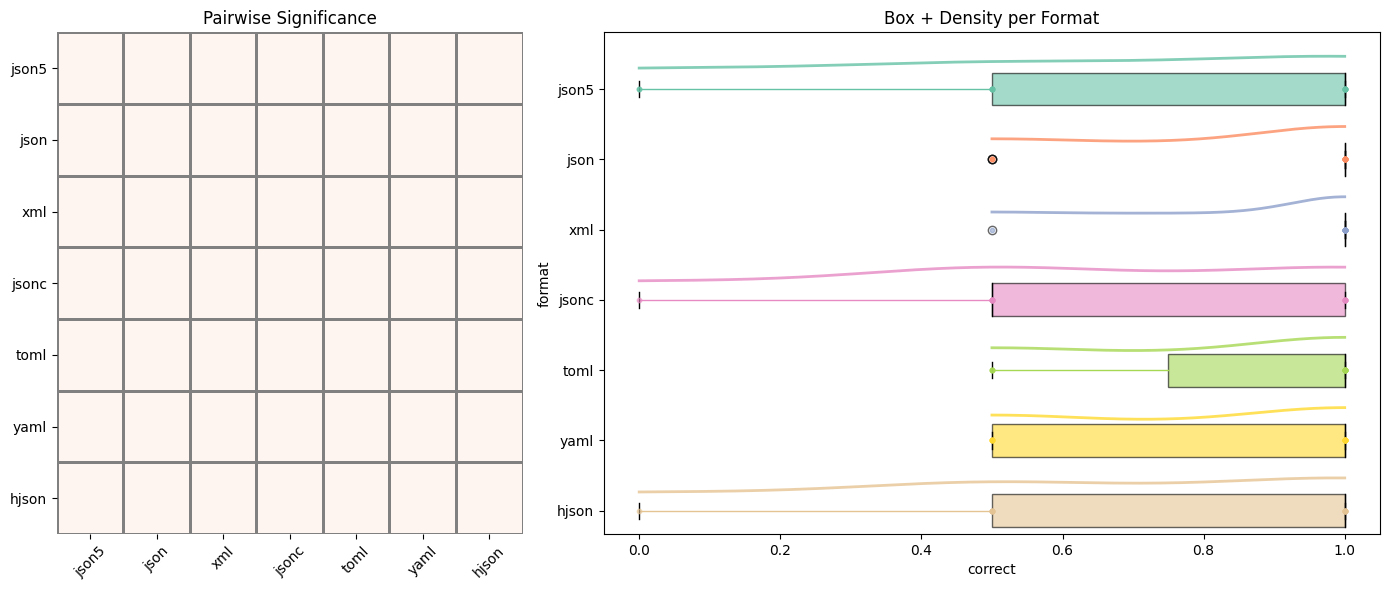

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  0.733333  0.319970     1.0  0.0  1.0
 json       15  0.900000  0.207020     1.0  0.5  1.0
 json5      15  0.700000  0.368394     1.0  0.0  1.0
 jsonc      15  0.700000  0.316228     0.5  0.0  1.0
 toml       15  0.866667  0.228869     1.0  0.5  1.0
 xml        15  0.966667  0.129099     1.0  0.5  1.0
 yaml       17  0.823529  0.246296     1.0  0.5  1.0,
 'overall_p': 0.04255740530767846,
 'effect_size': 0.11996273622571205,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.6224        False   hjson vs json is not significant
 1   hjson  json5   0.9999        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.9999        False  hjson vs jsonc is not significant
 3   hjson   toml   0.8243  

In [63]:
## correct
vis_box_comparasion(
    df_quiz_summary,
    group_col='format',
    value_col='correct',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

quiz_correct_results = compare_statistically(
    df_quiz_summary,
    group_col='format',
    value_col='correct',
    method='anova',
    task_col='task'
)

quiz_correct_results


### num wrong attempts

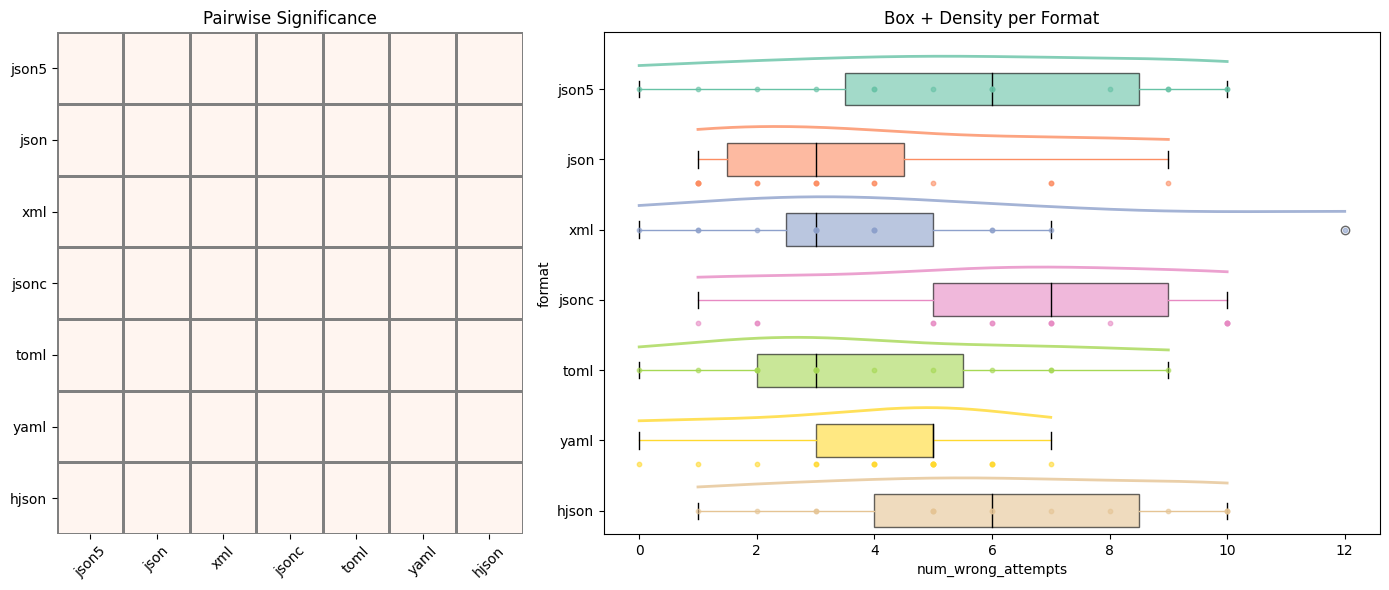

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  6.000000  2.976095     6.0    1   10
 json       15  3.533333  2.503331     3.0    1    9
 json5      15  5.533333  3.226379     6.0    0   10
 jsonc      15  6.400000  3.018988     7.0    1   10
 toml       15  3.800000  2.512824     3.0    0    9
 xml        15  3.933333  2.963267     3.0    0   12
 yaml       17  4.176471  1.878673     5.0    0    7,
 'overall_p': 0.01582246820026964,
 'effect_size': 0.14220597004454735,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.1847        False   hjson vs json is not significant
 1   hjson  json5   0.9992        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.9997        False  hjson vs jsonc is not significant
 3   hjson   toml   0.3072  

In [64]:
## num_wrong_attempts
vis_box_comparasion(
    df_quiz_summary,
    group_col='format',
    value_col='num_wrong_attempts',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

quiz_attempt_results = compare_statistically(
    df_quiz_summary,
    group_col='format',
    value_col='num_wrong_attempts',
    method='anova',
    task_col='task'
)

quiz_attempt_results

### wrong choice count

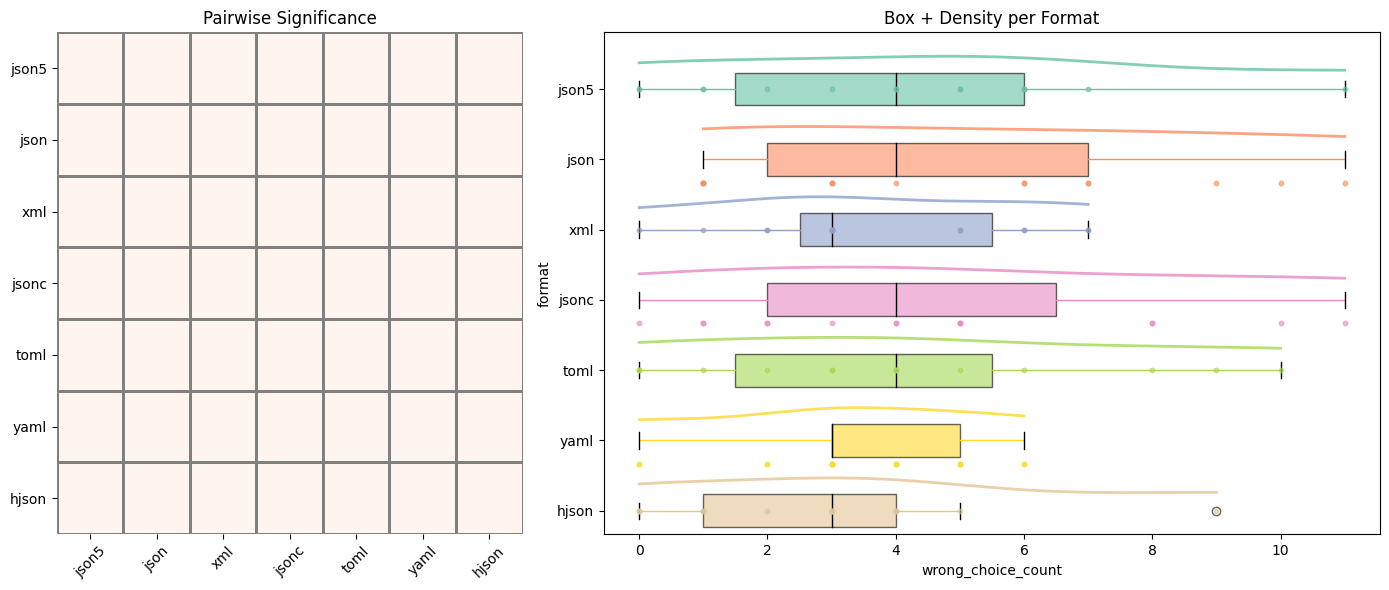

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  2.800000  2.366432     3.0    0    9
 json       15  4.866667  3.419830     4.0    1   11
 json5      15  4.066667  3.011091     4.0    0   11
 jsonc      15  4.600000  3.355167     4.0    0   11
 toml       15  3.933333  3.217512     4.0    0   10
 xml        15  3.733333  2.153624     3.0    0    7
 yaml       17  3.411765  1.769845     3.0    0    6,
 'overall_p': 0.46933310974502696,
 'effect_size': 0.05344277245782031,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [67]:
## wrong_choice_count
vis_box_comparasion(
    df_quiz_summary,
    group_col='format',
    value_col='wrong_choice_count',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

quiz_choice_results = compare_statistically(
    df_quiz_summary,
    group_col='format',
    value_col='wrong_choice_count',
    method='anova',
    task_col='task'
)

quiz_choice_results

In [68]:
# first_key, first_value = list(all_data.items())[0]
# first_item = { first_key: first_value }
# first_item

## Post Task Survey Analysis

### clean data

In [5]:
import pandas as pd
df_post_survy_format= extract_post_task_tlx_responses(all_data, df_part )

# 3) （可选）查看结果
df_post_survy_format

questions_1 = ['q9','q13','q14']
sub_df_1 = extract_survey_items(
    df_post_survy_format,
    items=questions_1,
    id_col='participantId',
    format_col='format'
)
sub_df_1


,participantId,format,q9,q13,q14
0,67895b7d6400163124042af7,jsonc,Bachelor's,[Prefer not to say.],[Prefer not to say.]
1,659960f32faa4ff4b116de92,toml,High School,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
2,5f7f239e9b204e05b6c36538,json5,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
3,67b8636acd5ed420cc098b64,toml,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
4,57ca4b09993b08000192297b,xml,Bachelor's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
...,...,...,...,...,...
102,5755c957eb80c4000741a9ce,json5,Master's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
103,6693d3ae2bd15cf7a058e6a7,json5,Bachelor's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
104,60e2bf0aa568b97e8d525872,toml,PhD,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"
105,67d24179c5bd87691f1fe036,yaml,Bachelor's,"[No, I do not have any cognitive-related condi...","[No, I do not have any related conditions.]"


In [6]:
df_post_survy_format['q7'].unique()

array(['no', '', 'No thank you ',
       'On the question with the chart where I had to write the xml code, it was very hard for me to see the value that was under engines which was starting with a "p"',
       'Yes. It takes a lot of analyzing and noticing the little details for you to get the concept.',
       'I tried everything to the best of my ability',
       'There were several answers that I think could be wrong. I did my best.',
       'This Data Serialization formats are a first to me, so at some point I tried using a pen and paper to write down and figure out the answers as best as I could',
       'No',
       'i felt this quite hard but still tried my best at understanding it the best i could',
       'I tried to do it to the best of my abilities, but I have no prior coding or data categorization experience or knowledge. So when I get tasks like these I feel particularly out of my depth. But I was happy to participate and learn. ',
       "I struggled with the final quest

In [7]:
df_post_survy_format['q8'].unique()

array(['no',
       'This was a very mentally challenging but thoroughly enjoyable study. I really liked the tasks of modifying and writing TOML. ',
       '', 'No',
       'I\'m not exactly sure what I was supposed to do for the final request, which was to turn the "collaborators" into an array of objects with <name> tags. I might have gotten this one wrong, it has been a very long time since I touched XML.',
       'nothing', 'The study was brain stimulating.',
       'This was very difficult at times',
       "The study was a learning curve which was intriguing and also interesting. I adjusted a bit but fell short a lot, if this was a school test I wouldn't expect outstanding results, but the challenge was fair with its brief explanations.",
       'I just love the programming language so much JSON5 is a very easy language to learn and i have leraned alot through this study. Thanks alot.',
       'Perhaps the help could be a bit more detailed or the examples before the test a bit mo

In [9]:
df_post_survy_format['q10_years'].unique()

array([ 0.67,  0.  ,  6.  , 10.  ,  1.5 ,  2.  ,  0.21,  0.5 ,  0.25,
        3.33,  3.17,  4.  ,  0.33,  0.58,  5.25,  3.  ,  0.92,  0.75,
        3.5 ,  0.17,  1.  ,  0.08,  2.5 , 58.33,  5.42,  1.17,  1.33,
        2.83,  4.33,  3.75,  2.17,  1.08,  8.75,  1.92, 13.33])

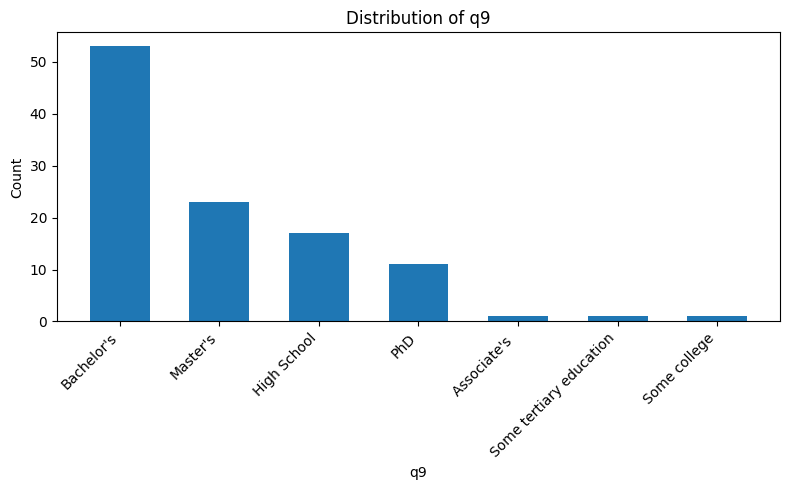

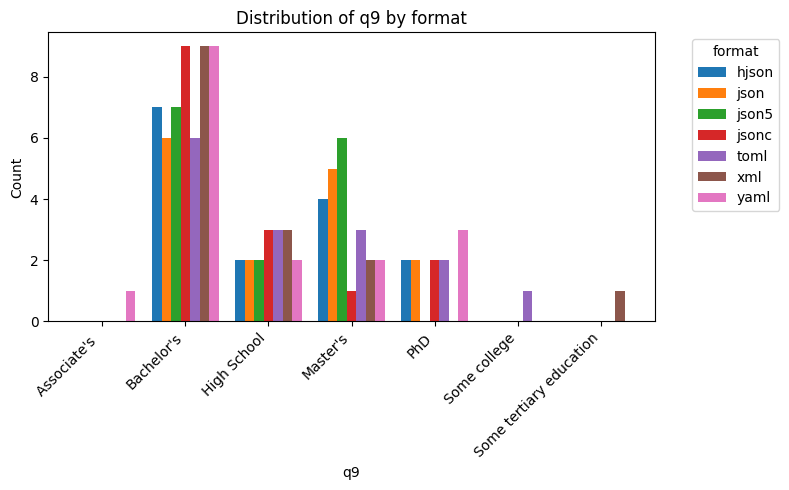

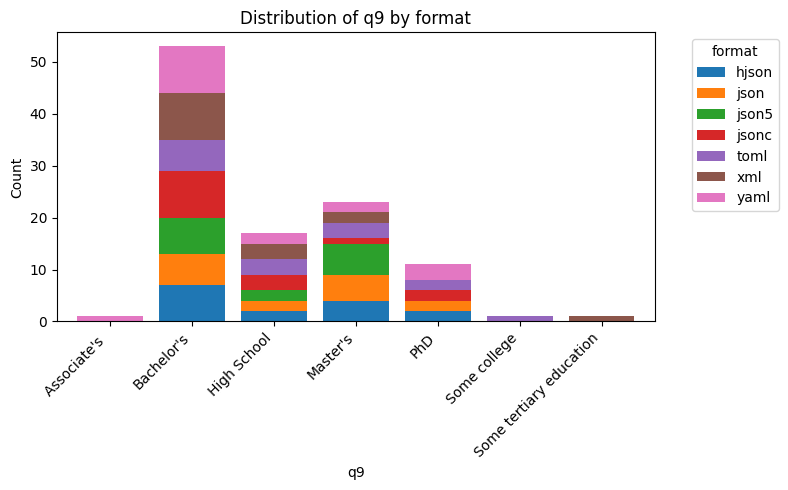

In [28]:
# q9
plot_answer_distribution(sub_df_1, question='q9')

plot_answer_distribution(sub_df_1, question='q9', group_by='format')

plot_answer_distribution(sub_df_1, question='q9', group_by='format', stacked=True)



In [29]:
# cnt = get_answer_counts(sub_df, question='q13')
# cnt_by_fmt = get_answer_counts(sub_df, question='q13', group_by='format')

cnt_13 = get_answer_counts(sub_df_1, question='q13')
print(cnt_13)

cnt_14 = get_answer_counts(sub_df_1, question='q14')
print(cnt_14)

q13
No, I do not have any cognitive-related conditions.                                    98
Prefer not to say.                                                                      6
Dyslexia (e.g., difficulty reading or distinguishing symbols, such as "b" and "d").     1
Dysgraphia (e.g., difficulty with handwriting or written expression).                   1
ADHD                                                                                    1
Name: count, dtype: int64
q14
No, I do not have any related conditions.                                                     98
Prefer not to say.                                                                             6
Color vision deficiency (CVD) (e.g., difficulty distinguishing colors like red and green).     2
Low vision (e.g., difficulty seeing clearly, even with corrective lenses).                     1
Name: count, dtype: int64


In [12]:
questions_2 = ['q10_years','q11']

sub_df_2 = extract_survey_items(
    df_post_survy_format,
    items=questions_2,
    id_col='participantId',
    format_col='format'
)

mapping = {
    'Not familiar at all': 1,
    'Somewhat familiar'  : 2,
    'Very familiar'      : 3
}

sub_df_2['q11_code'] = sub_df_2['q11'].map(mapping)

sub_df_2

,participantId,format,q10_years,q11,q11_code
0,67895b7d6400163124042af7,jsonc,0.67,Somewhat familiar,2
1,659960f32faa4ff4b116de92,toml,0.00,Not familiar at all,1
2,5f7f239e9b204e05b6c36538,json5,0.00,Not familiar at all,1
3,67b8636acd5ed420cc098b64,toml,6.00,Somewhat familiar,2
4,57ca4b09993b08000192297b,xml,10.00,Somewhat familiar,2
...,...,...,...,...,...
102,5755c957eb80c4000741a9ce,json5,13.33,Somewhat familiar,2
103,6693d3ae2bd15cf7a058e6a7,json5,0.00,Not familiar at all,1
104,60e2bf0aa568b97e8d525872,toml,1.00,Very familiar,3
105,67d24179c5bd87691f1fe036,yaml,0.00,Not familiar at all,1


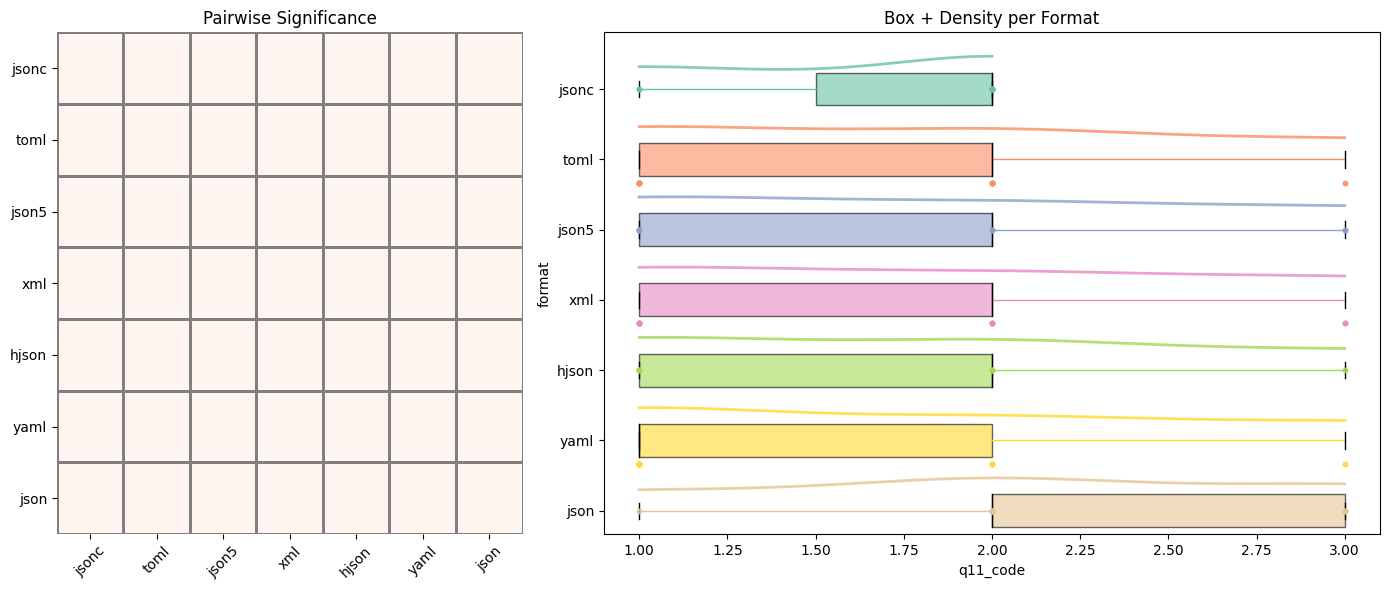

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  1.666667  0.723747     2.0    1    3
 json       15  2.200000  0.676123     2.0    1    3
 json5      15  1.733333  0.798809     2.0    1    3
 jsonc      15  1.733333  0.457738     2.0    1    2
 toml       15  1.666667  0.723747     2.0    1    3
 xml        15  1.733333  0.798809     2.0    1    3
 yaml       17  1.529412  0.717430     1.0    1    3,
 'overall_p': 0.2386427766991993,
 'effect_size': 0.07538637393556946,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [13]:
sub_df_2['task'] = 'package'
vis_box_comparasion(
    sub_df_2,
    group_col='format',
    value_col='q11_code',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

q11_results = compare_statistically(
    sub_df_2,
    group_col='format',
    value_col='q11_code',
    method='anova',
    task_col='task'
)

q11_results

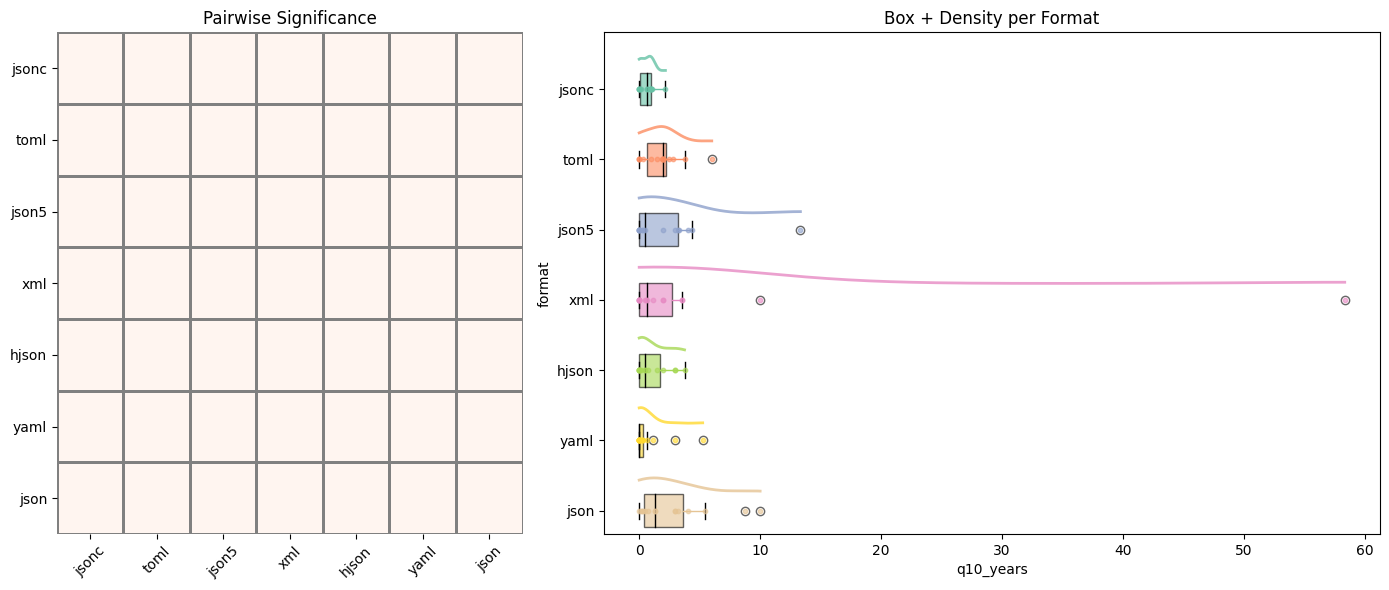

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean        std  median  min    max
 format                                                
 hjson      15  1.016667   1.306744    0.50  0.0   3.75
 json       15  2.800000   3.127509    1.33  0.0  10.00
 json5      15  2.282667   3.472736    0.50  0.0  13.33
 jsonc      15  0.650667   0.615531    0.67  0.0   2.17
 toml       15  1.855333   1.597605    2.00  0.0   6.00
 xml        15  5.483333  14.847532    0.67  0.0  58.33
 yaml       17  0.654706   1.400255    0.00  0.0   5.25,
 'overall_p': 0.27978121746262186,
 'effect_size': 0.07061026561636513,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [14]:
vis_box_comparasion(
    sub_df_2,
    group_col='format',
    value_col='q10_years',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

q10_results = compare_statistically(
    sub_df_2,
    group_col='format',
    value_col='q10_years',
    method='anova',
    task_col='task'
)

q10_results

### familarity

In [31]:
# q12
df_encoded, df_familiar = extract_and_encode_familiarity(df_post_survy_format)
df_familiar['task']='survey'
df_familiar


,participantId,format,familiarity,task
0,67895b7d6400163124042af7,jsonc,3,survey
1,659960f32faa4ff4b116de92,toml,1,survey
2,5f7f239e9b204e05b6c36538,json5,1,survey
3,67b8636acd5ed420cc098b64,toml,2,survey
4,57ca4b09993b08000192297b,xml,3,survey
...,...,...,...,...
102,5755c957eb80c4000741a9ce,json5,1,survey
103,6693d3ae2bd15cf7a058e6a7,json5,2,survey
104,60e2bf0aa568b97e8d525872,toml,4,survey
105,67d24179c5bd87691f1fe036,yaml,1,survey


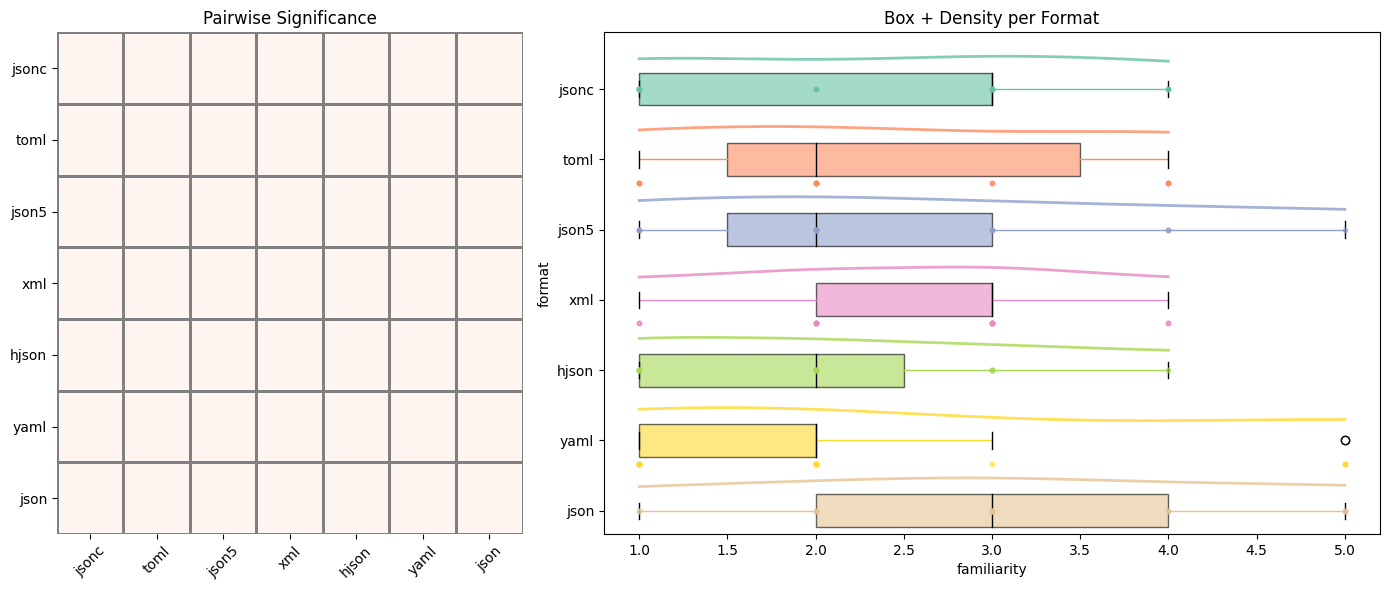

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  1.933333  0.961150     2.0    1    4
 json       15  3.066667  1.334523     3.0    1    5
 json5      15  2.400000  1.242118     2.0    1    5
 jsonc      15  2.400000  1.183216     3.0    1    4
 toml       15  2.400000  1.183216     2.0    1    4
 xml        15  2.533333  0.915475     3.0    1    4
 yaml       17  2.176471  1.467791     2.0    1    5,
 'overall_p': 0.2781811762418412,
 'effect_size': 0.0707857006847818,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [32]:
## reading tasks

vis_box_comparasion(
    df_familiar,
    group_col='format',
    value_col='familiarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
)

familar_results = compare_statistically(
    df_familiar,
    group_col='format',
    value_col='familiarity',
    method='anova',
    task_col='task'
)

familar_results


## Time Correctness Anlaysis

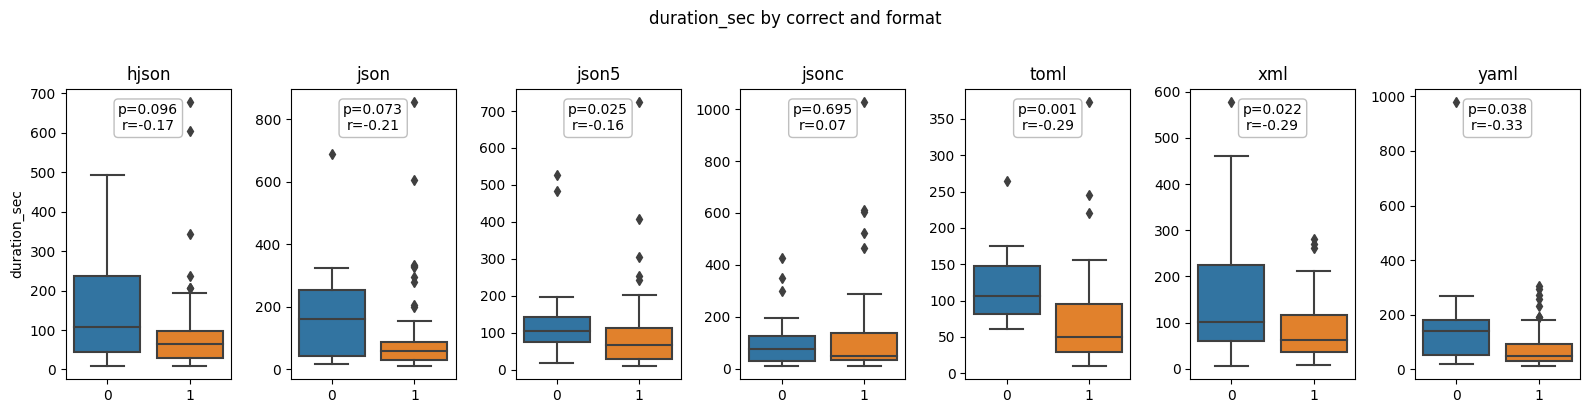

In [33]:
plot_duration_vs_correct_with_stats(
    df_post      = df_reading_result,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    time_col       ='duration_sec',      # 连续时间列
    response_col   ='correct',         
    by_format      = True              # 按 format 分面
)


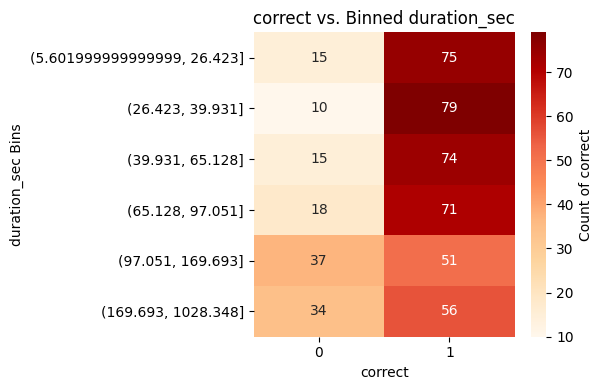

In [34]:
plot_time_vs_response_heatmap(
    df_post      = df_reading_result,
    df_result    = df_reading_result,
    participant_col='participantId',
    format_col     ='format',
    task_col       ='task',
    time_col       ='duration_sec',
    response_col   ='correct',
    bins           = 6,
    cmap           ='OrRd'
)


## Writing Task Correctness 

### data prepare

In [35]:
df_json=df_writing[df_writing['format']=='json']
df_jsonc=df_writing[df_writing['format']=='jsonc']
df_json5=df_writing[df_writing['format']=='json5']
df_hjson=df_writing[df_writing['format']=='hjson']
df_toml=df_writing[df_writing['format']=='toml']
df_yaml=df_writing[df_writing['format']=='yaml']
df_xml=df_writing[df_writing['format']=='xml']


gold_dict_json = '''{
  "version": "4.4.7",
  "repository": {
    "author": {
      "middle name": "",
      "IsMember": true
    },
    "type": "git"
  },
  "engines": {
    "pnpm": ">=8"
  },
  "keywords": [
    "canvas",
    "responsive",
    "charts"
  ]
}'''

gold_dict_jsonc = '''{
  "version": "4.4.7",
  "repository": {
    "author": {
      "middle name": "",
      "IsMember": true
    },
    "type": "git"
  },
  "engines": {
    "pnpm": ">=8"
  },
  "keywords": [
    "canvas",
    "responsive",
    "charts"
  ]
}'''


gold_dict_hjson = '''
version: 4.4.7

repository:
  author:
    middle name:
    IsMember: true
  type: git

engines:
  pnpm: ">=8"

keywords:
[
  canvas
  responsive
  charts
]
'''

gold_dict_json5 = '''
{
  version: "4.4.7",

  repository: {
    author: {
      "middle name": "",  // Empty value
      IsMember: true
    },
    type: "git"
  },

  engines: {
    pnpm: ">=8"
  },

  keywords: [
    "canvas",
    "responsive",
    "charts"
  ]
}
'''

gold_dict_yaml = '''
version: "4.4.7"

repository:
  author:
    middle name: ""
    IsMember: true
  type: git

engines:
  pnpm: ">=8"

keywords:
  - canvas
  - responsive
  - charts
'''

gold_dict_toml = '''
version = "4.4.7"

[repository.author]
"middle name" = ""
IsMember = true

[repository]
type = "git"

[engines]
pnpm = ">=8"

keywords = ["canvas", "responsive", "charts"]
'''

gold_dict_xml = '''
<root>
  <version>4.4.7</version>
  <repository>
    <author>
      <middle_name></middle_name>
      <IsMember>true</IsMember>
    </author>
    <type>git</type>
  </repository>

  <engines>
    <pnpm>&gt;=8</pnpm>
  </engines>

  <keywords>
    <keyword>canvas</keyword>
    <keyword>responsive</keyword>
    <keyword>charts</keyword>
  </keywords>
</root>
'''

### show results

In [36]:
json_result = process_dataframe_with_validation(df_json, gold_dict_json)
jsonc_result = process_dataframe_with_validation(df_jsonc, gold_dict_jsonc)
json5_result = process_dataframe_with_validation(df_json5, gold_dict_json5)
hjson_result = process_dataframe_with_validation(df_hjson, gold_dict_hjson)
toml_result = process_dataframe_with_validation(df_toml, gold_dict_toml)
yaml_result = process_dataframe_with_validation(df_yaml, gold_dict_yaml)
xml_result = process_dataframe_with_validation(df_xml, gold_dict_xml)
# json_result.sort_values(by='similarity', ascending=False)
# jsonc_result.sort_values(by='similarity', ascending=False)
# json5_result.sort_values(by='similarity', ascending=False)
# hjson_result.sort_values(by='similarity', ascending=False)
# yaml_result.sort_values(by='similarity', ascending=False)
# toml_result.sort_values(by='similarity', ascending=False)
xml_result.sort_values(by='similarity', ascending=False)

,participantId,format,strict_check,loose_check,final_check,ted,norm_ted,similarity
8,672f51ea346fba23ddd5a793,xml,0,1,1,14.0,0.358974,0.641026
1,6693ce87e76d32ccf07fbcd8,xml,0,1,1,21.0,0.656250,0.343750
3,67c045fa5074c5500ca40e76,xml,0,1,1,22.0,0.687500,0.312500
9,62d7fef5538b81f205ba4656,xml,0,1,1,24.0,0.750000,0.250000
4,67d2eaf9d5996dc6be1c7072,xml,0,1,1,26.0,0.812500,0.187500
7,677f8968bbb08bc37c8d2a4b,xml,0,1,1,27.0,0.843750,0.156250
0,57ca4b09993b08000192297b,xml,0,1,1,30.0,0.937500,0.062500
6,67aca6831f2b0b79416bdb6c,xml,0,1,1,30.0,0.937500,0.062500
12,60f7c71d1cffec381351b0b3,xml,0,1,1,30.0,0.937500,0.062500
14,5c4f5967aac8be0001716a65,xml,0,1,1,31.0,0.968750,0.031250


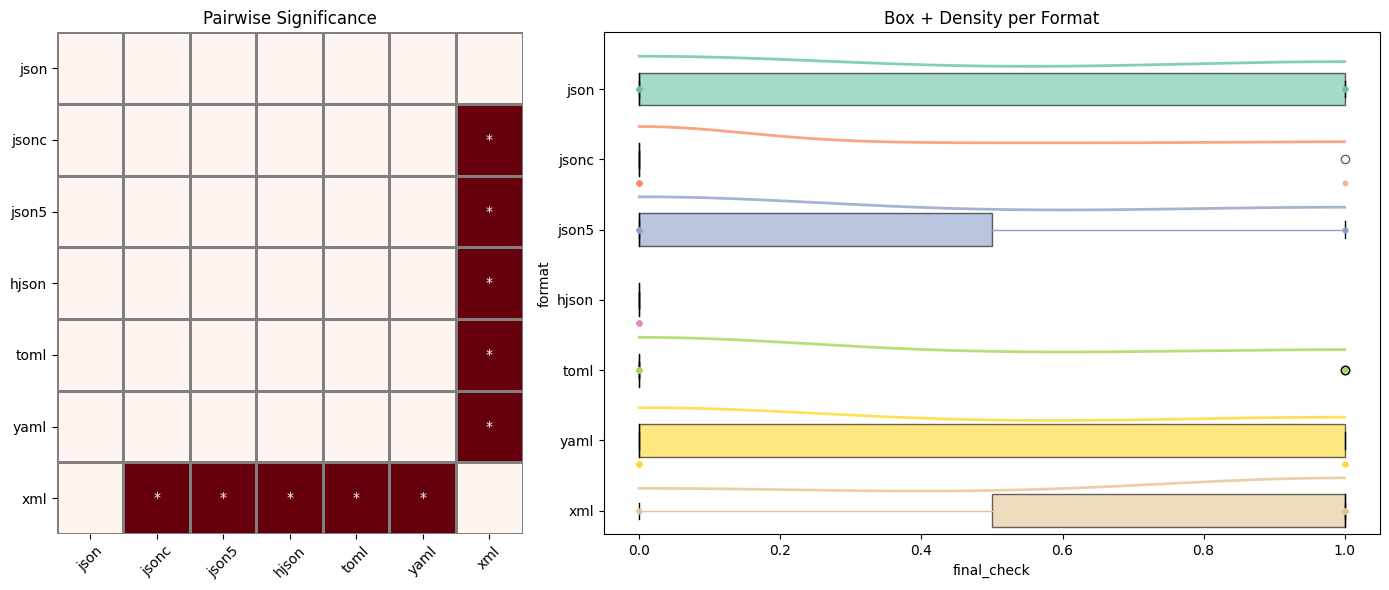

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  0.000000  0.000000     0.0    0    0
 json       15  0.400000  0.507093     0.0    0    1
 json5      15  0.266667  0.457738     0.0    0    1
 jsonc      15  0.066667  0.258199     0.0    0    1
 toml       15  0.200000  0.414039     0.0    0    1
 xml        15  0.733333  0.457738     1.0    0    1
 yaml       17  0.294118  0.469668     0.0    0    1,
 'overall_p': 7.687348668001804e-05,
 'effect_size': 0.24361599185128596,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.1062        False   hjson vs json is not significant
 1   hjson  json5   0.5464        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.9993        False  hjson vs jsonc is not significant
 3   hjson   toml   0.8237

In [85]:
## reading tasks
df_writing_merged = merge_dfs([json_result, jsonc_result, json5_result,hjson_result,toml_result,yaml_result,xml_result])
df_writing_merged['task']= 'writing_task'

vis_box_comparasion(
    df_writing_merged,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task',
    discrete_tasks=['writing_task']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

writing_results = compare_statistically(
    df_writing_merged,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task',
    discrete_tasks=['writing_task']
)

writing_results

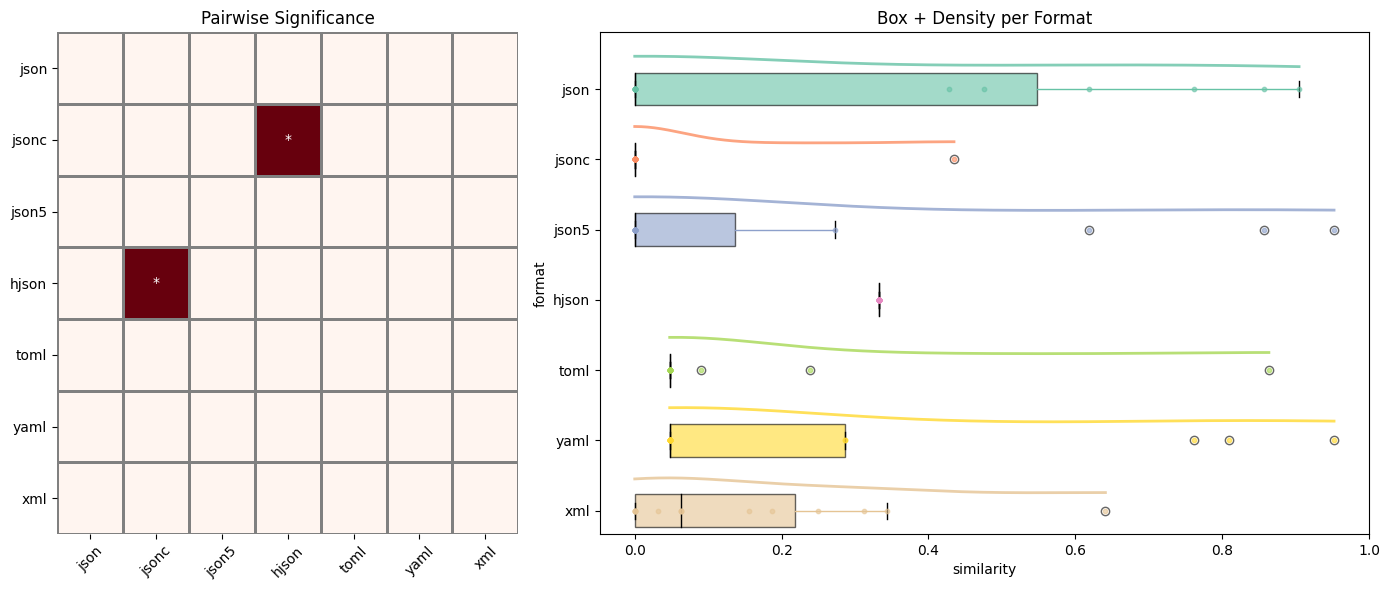

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      15  0.333333  0.000000  0.333333  0.333333  0.333333
 json       15  0.269841  0.362060  0.000000  0.000000  0.904762
 json5      15  0.180087  0.339417  0.000000  0.000000  0.952381
 jsonc      15  0.028986  0.112260  0.000000  0.000000  0.434783
 toml       15  0.117605  0.212228  0.047619  0.047619  0.863636
 xml        15  0.140652  0.182200  0.062500  0.000000  0.641026
 yaml       17  0.215686  0.310492  0.047619  0.047619  0.952381,
 'overall_p': 0.030371946212536676,
 'effect_size': 0.12773729833777167,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9926        False   hjson vs json is not significant
 1   hjson  json5   0.6328        False  hjson vs json5 is not signif

In [86]:
vis_box_comparasion(
    df_writing_merged,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task'
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task']
)

writing_results_s = compare_statistically(
    df_writing_merged,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task'
)

writing_results_s

## modifying task correctness

### data prepare

In [39]:
df_json_1=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-1']
df_json_2=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-2']
df_json_3=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-3']
df_json_4=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-4']
df_jsonc_1=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-config-1']
df_jsonc_2=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-config-2']
df_jsonc_3=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-config-3']
df_jsonc_4=df_modifying[df_modifying['format']=='jsonc'][df_modifying['task']=='modifying-task-config-4']
df_json5_1=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-config-1']
df_json5_2=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-config-2']
df_json5_3=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-config-3']
df_json5_4=df_modifying[df_modifying['format']=='json5'][df_modifying['task']=='modifying-task-config-4']
df_hjson_1=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-config-1']
df_hjson_2=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-config-2']
df_hjson_3=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-config-3']
df_hjson_4=df_modifying[df_modifying['format']=='hjson'][df_modifying['task']=='modifying-task-config-4']
df_toml_1=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-1']
df_toml_2=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-2']
df_toml_3=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-3']
df_toml_4=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-4']
df_yaml_1=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-config-1']
df_yaml_2=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-config-2']
df_yaml_3=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-config-3']
df_yaml_4=df_modifying[df_modifying['format']=='yaml'][df_modifying['task']=='modifying-task-config-4']
df_toml_1=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-1']
df_toml_2=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-2']
df_toml_3=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-3']
df_toml_4=df_modifying[df_modifying['format']=='toml'][df_modifying['task']=='modifying-task-config-4']
df_xml_1=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-config-1']
df_xml_2=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-config-2']
df_xml_3=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-config-3']
df_xml_4=df_modifying[df_modifying['format']=='xml'][df_modifying['task']=='modifying-task-config-4']

/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_79342/2275585507.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_1=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-1']
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_79342/2275585507.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_2=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-2']
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_79342/2275585507.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_3=df_modifying[df_modifying['format']=='json'][df_modifying['task']=='modifying-task-config-3']
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_79342/2275585507.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_json_4=df_modifying[df_modifying['format']=='

In [40]:
gold_dict_json_1 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    "Kanit Wongsuphasawat",
    "Dominik Moritz",
    "Arvind Satyanarayan",
    "Jeffrey Heer"
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git",
    "url": "github.com/vega/vega-lite.git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
    "url": "github.com/vega/vega-lite/issues"
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2"
  },
  "peerDependencies": {
    "vega": "^5.23.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_jsonc_1 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    "Kanit Wongsuphasawat",
    "Dominik Moritz",
    "Arvind Satyanarayan",
    "Jeffrey Heer"
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git",
    "url": "github.com/vega/vega-lite.git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
    "url": "github.com/vega/vega-lite/issues"
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2"
  },
  "peerDependencies": {
    "vega": "^5.23.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_json5_1 = '''
{
  name: 'vega-lite',
  author: 'Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer',
  version: '5.23.0',
  collaborators: [
    'Kanit Wongsuphasawat',
    'Dominik Moritz',
    'Arvind Satyanarayan',
    'Jeffrey Heer'
  ],
  homepage: 'ega.github.io/vega-lite/',
  description: 'Vega-Lite is a concise high-level language for interactive visualization.',
  keywords: ['vega', 'chart', 'visualization'],
  main: 'build/vega-lite.js',
  unpkg: 'build/vega-lite.min.js',
  jsdelivr: 'build/vega-lite.min.js',
  module: 'build/src/index',
  types: 'build/src/index.d.ts',
  bin: {
    vl2pdf: './bin/vl2pdf',
    vl2png: './bin/vl2png',
    vl2svg: './bin/vl2svg',
    vl2vg: './bin/vl2vg'
  },
  files: ['bin', 'build', 'src', 'vega-lite*', 'tsconfig.json'],
  scripts: {
    changelog: 'conventional-changelog -p angular -r',
    prebuild: 'yarn clean:build',
    build: 'yarn build:only',
    data: 'rsync -r node_modules/vega-datasets/data/* site/data',
    'build-editor-preview': 'scripts/build-editor-preview.sh',
    schema: 'mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/',
    renameschema: 'scripts/rename-schema.sh',
    presite: 'yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh',
    site: 'yarn site:only',
    format: 'eslint . --fix && yarn prettierbase --write',
    lint: 'eslint . && yarn prettierbase --check',
    test: 'yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn',
    release: 'release-it'
  },
  repository: {
    type: 'git',
    url: 'github.com/vega/vega-lite.git'
  },
  license: 'BSD-3-Clause',
  bugs: {
    url: 'github.com/vega/vega-lite/issues'
  },
  devDependencies: {
    ajv: '^8.17.1',
    'ajv-formats': '^3.0.1',
    cheerio: '^1.0.0',
    'conventional-changelog-cli': '^5.0.0',
    d3: '^7.9.0',
    'del-cli': '^6.0.0',
    eslint: '^8.57.0',
    'eslint-config-prettier': '^9.1.0',
    'eslint-plugin-jest': '^28.11.0',
    'eslint-plugin-prettier': '^5.2.1',
    'fast-json-stable-stringify': '~2.1.0',
    'highlight.js': '^11.11.1',
    jest: '^29.7.0',
    'jest-dev-server': '^11.0.0',
    mkdirp: '^3.0.1',
    pako: '^2.1.0',
    prettier: '^3.4.2',
    puppeteer: '^15.0.0',
    'release-it': '18.1.2',
    rollup: '^4.32.1',
    'rollup-plugin-bundle-size': '^1.0.3',
    serve: '^14.2.4',
    terser: '^5.37.0',
    'ts-jest': '^29.2.5',
    'ts-json-schema-generator': '^2.3.0',
    typescript: '~5.7.3',
    'vega-cli': '^5.31.0',
    'vega-datasets': '^2.11.0',
    'vega-embed': '^6.29.0',
    'vega-tooltip': '^0.35.2',
    'yaml-front-matter': '^4.1.1'
  },
  dependencies: {
    'json-stringify-pretty-compact': '~4.0.0',
    tslib: '~2.8.1',
    'vega-event-selector': '~3.0.1',
    'vega-expression': '~5.1.2',
    'vega-util': '~1.17.3',
    yargs: '~17.7.2'
  },
  peerDependencies: {
    vega: '^5.23.0'
  },
  engines: {
'''
gold_dict_hjson_1 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: 5.23.0

collaborators: [Kanit Wongsuphasawat, Dominik Moritz, Arvind Satyanarayan, Jeffrey Heer]

homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.

keywords: [
  vega
  chart
  visualization
]

main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts

bin: {
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
}

files: [
  bin
  build
  src
  vega-lite*
  tsconfig.json
]

scripts: {
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
}

repository: {
  type: git
  url: github.com/vega/vega-lite.git
}

license: BSD-3-Clause

bugs: {
  url: github.com/vega/vega-lite/issues
}

devDependencies: {
  ajv: ^8.17.1
  ajv-formats: ^3.0.1
  cheerio: ^1.0.0
  conventional-changelog-cli: ^5.0.0
  d3: ^7.9.0
  del-cli: ^6.0.0
  eslint: ^8.57.0
  eslint-config-prettier: ^9.1.0
  eslint-plugin-jest: ^28.11.0
  eslint-plugin-prettier: ^5.2.1
  fast-json-stable-stringify: ~2.1.0
  highlight.js: ^11.11.1
  jest: ^29.7.0
  jest-dev-server: ^11.0.0
  mkdirp: ^3.0.1
  pako: ^2.1.0
  prettier: ^3.4.2
  puppeteer: ^15.0.0
  release-it: 18.1.2
  rollup: ^4.32.1
  rollup-plugin-bundle-size: ^1.0.3
  serve: ^14.2.4
  terser: ^5.37.0
  ts-jest: ^29.2.5
  ts-json-schema-generator: ^2.3.0
  typescript: ~5.7.3
  vega-cli: ^5.31.0
  vega-datasets: ^2.11.0
  vega-embed: ^6.29.0
  vega-tooltip: ^0.35.2
  yaml-front-matter: ^4.1.1
}

dependencies: {
  json-stringify-pretty-compact: ~4.0.0
  tslib: ~2.8.1
  vega-event-selector: ~3.0.1
  vega-expression: ~5.1.2
  vega-util: ~1.17.3
  yargs: ~17.7.2
}

peerDependencies: {
  vega: ^5.23.0
}

engines: {
  node: ">=18"
}

packageManager: yarn@1.22.22
'''
gold_dict_yaml_1 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: "5.23.0"
collaborators:
  - Kanit Wongsuphasawat
  - Dominik Moritz
  - Arvind Satyanarayan
  - Jeffrey Heer
homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.
keywords:
  - vega
  - chart
  - visualization
main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts
bin:
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
files:
  - bin
  - build
  - src
  - vega-lite*
  - tsconfig.json
scripts:
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
repository:
  type: git
  url: github.com/vega/vega-lite.git
license: BSD-3-Clause
bugs:
  url: github.com/vega/vega-lite/issues
devDependencies:
  ajv: "^8.17.1"
  ajv-formats: "^3.0.1"
  cheerio: "^1.0.0"
  conventional-changelog-cli: "^5.0.0"
  d3: "^7.9.0"
  del-cli: "^6.0.0"
  eslint: "^8.57.0"
  eslint-config-prettier: "^9.1.0"
  eslint-plugin-jest: "^28.11.0"
  eslint-plugin-prettier: "^5.2.1"
  fast-json-stable-stringify: "~2.1.0"
  highlight.js: "^11.11.1"
  jest: "^29.7.0"
  jest-dev-server: "^11.0.0"
  mkdirp: "^3.0.1"
  pako: "^2.1.0"
  prettier: "^3.4.2"
  puppeteer: "^15.0.0"
  release-it: "18.1.2"
  rollup: "^4.32.1"
  rollup-plugin-bundle-size: "^1.0.3"
  serve: "^14.2.4"
  terser: "^5.37.0"
  ts-jest: "^29.2.5"
  ts-json-schema-generator: "^2.3.0"
  typescript: "~5.7.3"
  vega-cli: "^5.31.0"
  vega-datasets: "^2.11.0"
  vega-embed: "^6.29.0"
  vega-tooltip: "^0.35.2"
  yaml-front-matter: "^4.1.1"
dependencies:
  json-stringify-pretty-compact: "~4.0.0"
  tslib: "~2.8.1"
  vega-event-selector: "~3.0.1"
  vega-expression: "~5.1.2"
  vega-util: "~1.17.3"
  yargs: "~17.7.2"
peerDependencies:
  vega: "^5.23.0"
engines:
  node: ">=18"
packageManager: yarn@1.22.22
'''
gold_dict_toml_1 = '''
name = "vega-lite"
author = "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer"
version = "5.23.0"
homepage = "ega.github.io/vega-lite/"
description = "Vega-Lite is a concise high-level language for interactive visualization."
main = "build/vega-lite.js"
unpkg = "build/vega-lite.min.js"
jsdelivr = "build/vega-lite.min.js"
module = "build/src/index"
types = "build/src/index.d.ts"
packageManager = "yarn@1.22.22"

collaborators = ["Kanit Wongsuphasawat", "Dominik Moritz", "Arvind Satyanarayan", "Jeffrey Heer"]
keywords = ["vega", "chart", "visualization"]
files = ["bin", "build", "src", "vega-lite*", "tsconfig.json"]

[bin]
vl2pdf = "./bin/vl2pdf"
vl2png = "./bin/vl2png"
vl2svg = "./bin/vl2svg"
vl2vg = "./bin/vl2vg"

[scripts]
changelog = "conventional-changelog -p angular -r"
prebuild = "yarn clean:build"
build = "yarn build:only"
data = "rsync -r node_modules/vega-datasets/data/* site/data"
build-editor-preview = "scripts/build-editor-preview.sh"
schema = "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/"
renameschema = "scripts/rename-schema.sh"
presite = "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh"
site = "yarn site:only"
format = "eslint . --fix && yarn prettierbase --write"
lint = "eslint . && yarn prettierbase --check"
test = "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn"
release = "release-it"

[repository]
type = "git"
url = "github.com/vega/vega-lite.git"

[bugs]
url = "github.com/vega/vega-lite/issues"

[license]
value = "BSD-3-Clause"

[devDependencies]
ajv = "^8.17.1"
ajv-formats = "^3.0.1"
cheerio = "^1.0.0"
conventional-changelog-cli = "^5.0.0"
d3 = "^7.9.0"
del-cli = "^6.0.0"
eslint = "^8.57.0"
eslint-config-prettier = "^9.1.0"
eslint-plugin-jest = "^28.11.0"
eslint-plugin-prettier = "^5.2.1"
fast-json-stable-stringify = "~2.1.0"
highlight.js = "^11.11.1"
jest = "^29.7.0"
jest-dev-server = "^11.0.0"
mkdirp = "^3.0.1"
pako = "^2.1.0"
prettier = "^3.4.2"
puppeteer = "^15.0.0"
release-it = "18.1.2"
rollup = "^4.32.1"
rollup-plugin-bundle-size = "^1.0.3"
serve = "^14.2.4"
terser = "^5.37.0"
ts-jest = "^29.2.5"
ts-json-schema-generator = "^2.3.0"
typescript = "~5.7.3"
vega-cli = "^5.31.0"
vega-datasets = "^2.11.0"
vega-embed = "^6.29.0"
vega-tooltip = "^0.35.2"
yaml-front-matter = "^4.1.1"

[dependencies]
json-stringify-pretty-compact = "~4.0.0"
tslib = "~2.8.1"
vega-event-selector = "~3.0.1"
vega-expression = "~5.1.2"
vega-util = "~1.17.3"
yargs = "~17.7.2"

[peerDependencies]
vega = "^5.23.0"

[engines]
node = ">=18"
'''
gold_dict_xml_1 = '''
<package>
  <name>vega-lite</name>
  <author>Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer</author>
  <version>5.23.0</version>
  
  <collaborators>
    <collaborator>Kanit Wongsuphasawat</collaborator>
    <collaborator>Dominik Moritz</collaborator>
    <collaborator>Arvind Satyanarayan</collaborator>
    <collaborator>Jeffrey Heer</collaborator>
  </collaborators>
  
  <homepage>ega.github.io/vega-lite/</homepage>
  <description>Vega-Lite is a concise high-level language for interactive visualization.</description>
  
  <keywords>
    <keyword>vega</keyword>
    <keyword>chart</keyword>
    <keyword>visualization</keyword>
  </keywords>
  
  <main>build/vega-lite.js</main>
  <unpkg>build/vega-lite.min.js</unpkg>
  <jsdelivr>build/vega-lite.min.js</jsdelivr>
  <module>build/src/index</module>
  <types>build/src/index.d.ts</types>

  <bin>
    <vl2pdf>./bin/vl2pdf</vl2pdf>
    <vl2png>./bin/vl2png</vl2png>
    <vl2svg>./bin/vl2svg</vl2svg>
    <vl2vg>./bin/vl2vg</vl2vg>
  </bin>

  <files>
    <file>bin</file>
    <file>build</file>
    <file>src</file>
    <file>vega-lite*</file>
    <file>tsconfig.json</file>
  </files>

  <scripts>
    <changelog>conventional-changelog -p angular -r</changelog>
    <prebuild>yarn clean:build</prebuild>
    <build>yarn build:only</build>
    <data>rsync -r node_modules/vega-datasets/data/* site/data</data>
    <build-editor-preview>scripts/build-editor-preview.sh</build-editor-preview>
    <schema>mkdir -p build &amp;&amp; ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode &gt; build/vega-lite-schema.json &amp;&amp; yarn renameschema &amp;&amp; cp build/vega-lite-schema.json site/_data/</schema>
    <renameschema>scripts/rename-schema.sh</renameschema>
    <presite>yarn data &amp;&amp; yarn schema &amp;&amp; yarn build:site &amp;&amp; yarn build:versions &amp;&amp; scripts/create-example-pages.sh</presite>
    <site>yarn site:only</site>
    <format>eslint . --fix &amp;&amp; yarn prettierbase --write</format>
    <lint>eslint . &amp;&amp; yarn prettierbase --check</lint>
    <test>yarn jest test/ &amp;&amp; yarn lint &amp;&amp; yarn schema &amp;&amp; yarn jest examples/ &amp;&amp; yarn</test>
    <release>release-it</release>
  </scripts>

  <repository>
    <type>git</type>
    <url>github.com/vega/vega-lite.git</url>
  </repository>

  <license>BSD-3-Clause</license>

  <bugs>
    <url>github.com/vega/vega-lite/issues</url>
  </bugs>

  <devDependencies>
    <ajv>^8.17.1</ajv>
    <ajv-formats>^3.0.1</ajv-formats>
    <cheerio>^1.0.0</cheerio>
    <conventional-changelog-cli>^5.0.0</conventional-changelog-cli>
    <d3>^7.9.0</d3>
    <del-cli>^6.0.0</del-cli>
    <eslint>^8.57.0</eslint>
    <eslint-config-prettier>^9.1.0</eslint-config-prettier>
    <eslint-plugin-jest>^28.11.0</eslint-plugin-jest>
    <eslint-plugin-prettier>^5.2.1</eslint-plugin-prettier>
    <fast-json-stable-stringify>~2.1.0</fast-json-stable-stringify>
    <highlight.js>^11.11.1</highlight.js>
    <jest>^29.7.0</jest>
    <jest-dev-server>^11.0.0</jest-dev-server>
    <mkdirp>^3.0.1</mkdirp>
    <pako>^2.1.0</pako>
    <prettier>^3.4.2</prettier>
    <puppeteer>^15.0.0</puppeteer>
    <release-it>18.1.2</release-it>
    <rollup>^4.32.1</rollup>
    <rollup-plugin-bundle-size>^1.0.3</rollup-plugin-bundle-size>
    <serve>^14.2.4</serve>
    <terser>^5.37.0</terser>
    <ts-jest>^29.2.5</ts-jest>
    <ts-json-schema-generator>^2.3.0</ts-json-schema-generator>
    <typescript>~5.7.3</typescript>
    <vega-cli>^5.31.0</vega-cli>
    <vega-datasets>^2.11.0</vega-datasets>
    <vega-embed>^6.29.0</vega-embed>
    <vega-tooltip>^0.35.2</vega-tooltip>
    <yaml-front-matter>^4.1.1</yaml-front-matter>
  </devDependencies>

  <dependencies>
    <json-stringify-pretty-compact>~4.0.0</json-stringify-pretty-compact>
    <tslib>~2.8.1</tslib>
    <vega-event-selector>~3.0.1</vega-event-selector>
    <vega-expression>~5.1.2</vega-expression>
    <vega-util>~1.17.3</vega-util>
    <yargs>~17.7.2</yargs>
  </dependencies>

  <peerDependencies>
    <vega>^5.23.0</vega>
  </peerDependencies>

  <engines>
    <node>&gt;=18</node>
  </engines>

  <packageManager>yarn@1.22.22</packageManager>
</package>
'''

In [41]:

gold_dict_json_2 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    "Kanit Wongsuphasawat",
    "Dominik Moritz",
    "Arvind Satyanarayan",
    "Jeffrey Heer"
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git",
    "url": "github.com/vega/vega-lite.git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
    "url": "github.com/vega/vega-lite/issues"
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2",
    "d3-hierarchy": "^3.1.2",
    "d3-interpolate":"^3.0.1",
    "d3-path": "^3.1.0"

  },
  "peerDependencies": {
    "vega": "^5.31.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_jsonc_2 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    "Kanit Wongsuphasawat",
    "Dominik Moritz",
    "Arvind Satyanarayan",
    "Jeffrey Heer"
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git",
    "url": "github.com/vega/vega-lite.git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
    "url": "github.com/vega/vega-lite/issues"
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2",
    "d3-hierarchy": "^3.1.2",
    "d3-interpolate":"^3.0.1",
    "d3-path": "^3.1.0"

  },
  "peerDependencies": {
    "vega": "^5.31.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_json5_2 = '''
{
  name: 'vega-lite',
  author: 'Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer',
  version: '5.23.0',
  collaborators: [
    'Kanit Wongsuphasawat',
    'Dominik Moritz',
    'Arvind Satyanarayan',
    'Jeffrey Heer'
  ],
  homepage: 'ega.github.io/vega-lite/',
  description: 'Vega-Lite is a concise high-level language for interactive visualization.',
  keywords: ['vega', 'chart', 'visualization'],
  main: 'build/vega-lite.js',
  unpkg: 'build/vega-lite.min.js',
  jsdelivr: 'build/vega-lite.min.js',
  module: 'build/src/index',
  types: 'build/src/index.d.ts',
  bin: {
    vl2pdf: './bin/vl2pdf',
    vl2png: './bin/vl2png',
    vl2svg: './bin/vl2svg',
    vl2vg: './bin/vl2vg'
  },
  files: ['bin', 'build', 'src', 'vega-lite*', 'tsconfig.json'],
  scripts: {
    changelog: 'conventional-changelog -p angular -r',
    prebuild: 'yarn clean:build',
    build: 'yarn build:only',
    data: 'rsync -r node_modules/vega-datasets/data/* site/data',
    'build-editor-preview': 'scripts/build-editor-preview.sh',
    schema: 'mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/',
    renameschema: 'scripts/rename-schema.sh',
    presite: 'yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh',
    site: 'yarn site:only',
    format: 'eslint . --fix && yarn prettierbase --write',
    lint: 'eslint . && yarn prettierbase --check',
    test: 'yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn',
    release: 'release-it'
  },
  repository: {
    type: 'git',
    url: 'github.com/vega/vega-lite.git'
  },
  license: 'BSD-3-Clause',
  bugs: {
    url: 'github.com/vega/vega-lite/issues'
  },
  devDependencies: {
    ajv: '^8.17.1',
    'ajv-formats': '^3.0.1',
    cheerio: '^1.0.0',
    'conventional-changelog-cli': '^5.0.0',
    d3: '^7.9.0',
    'del-cli': '^6.0.0',
    eslint: '^8.57.0',
    'eslint-config-prettier': '^9.1.0',
    'eslint-plugin-jest': '^28.11.0',
    'eslint-plugin-prettier': '^5.2.1',
    'fast-json-stable-stringify': '~2.1.0',
    'highlight.js': '^11.11.1',
    jest: '^29.7.0',
    'jest-dev-server': '^11.0.0',
    mkdirp: '^3.0.1',
    pako: '^2.1.0',
    prettier: '^3.4.2',
    puppeteer: '^15.0.0',
    'release-it': '18.1.2',
    rollup: '^4.32.1',
    'rollup-plugin-bundle-size': '^1.0.3',
    serve: '^14.2.4',
    terser: '^5.37.0',
    'ts-jest': '^29.2.5',
    'ts-json-schema-generator': '^2.3.0',
    typescript: '~5.7.3',
    'vega-cli': '^5.31.0',
    'vega-datasets': '^2.11.0',
    'vega-embed': '^6.29.0',
    'vega-tooltip': '^0.35.2',
    'yaml-front-matter': '^4.1.1'
  },
  dependencies: {
    'json-stringify-pretty-compact': '~4.0.0',
    tslib: '~2.8.1',
    'vega-event-selector': '~3.0.1',
    'vega-expression': '~5.1.2',
    'vega-util': '~1.17.3',
    'yargs': '~17.7.2',
    'd3-hierarchy': '^3.1.2',
    'd3-interpolate':'^3.0.1',
    'd3-path': '^3.1.0'
  },
  peerDependencies: {
    vega: '^5.31.0'
  },
  engines: {
'''
gold_dict_hjson_2 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: 5.23.0

collaborators: [Kanit Wongsuphasawat, Dominik Moritz, Arvind Satyanarayan, Jeffrey Heer]

homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.

keywords: [
  vega
  chart
  visualization
]

main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts

bin: {
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
}

files: [
  bin
  build
  src
  vega-lite*
  tsconfig.json
]

scripts: {
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
}

repository: {
  type: git
  url: github.com/vega/vega-lite.git
}

license: BSD-3-Clause

bugs: {
  url: github.com/vega/vega-lite/issues
}

devDependencies: {
  ajv: ^8.17.1
  ajv-formats: ^3.0.1
  cheerio: ^1.0.0
  conventional-changelog-cli: ^5.0.0
  d3: ^7.9.0
  del-cli: ^6.0.0
  eslint: ^8.57.0
  eslint-config-prettier: ^9.1.0
  eslint-plugin-jest: ^28.11.0
  eslint-plugin-prettier: ^5.2.1
  fast-json-stable-stringify: ~2.1.0
  highlight.js: ^11.11.1
  jest: ^29.7.0
  jest-dev-server: ^11.0.0
  mkdirp: ^3.0.1
  pako: ^2.1.0
  prettier: ^3.4.2
  puppeteer: ^15.0.0
  release-it: 18.1.2
  rollup: ^4.32.1
  rollup-plugin-bundle-size: ^1.0.3
  serve: ^14.2.4
  terser: ^5.37.0
  ts-jest: ^29.2.5
  ts-json-schema-generator: ^2.3.0
  typescript: ~5.7.3
  vega-cli: ^5.31.0
  vega-datasets: ^2.11.0
  vega-embed: ^6.29.0
  vega-tooltip: ^0.35.2
  yaml-front-matter: ^4.1.1
}

dependencies: {
  json-stringify-pretty-compact: ~4.0.0
  tslib: ~2.8.1
  vega-event-selector: ~3.0.1
  vega-expression: ~5.1.2
  vega-util: ~1.17.3
  yargs: ~17.7.2
  d3-hierarchy: ^3.1.2
  d3-interpolate:^3.0.1
  d3-path: ^3.1.0
}

peerDependencies: {
  vega: ^5.31.0
}

engines: {
  node: ">=18"
}

packageManager: yarn@1.22.22
'''
gold_dict_yaml_2 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: "5.23.0"
collaborators:
  - Kanit Wongsuphasawat
  - Dominik Moritz
  - Arvind Satyanarayan
  - Jeffrey Heer
homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.
keywords:
  - vega
  - chart
  - visualization
main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts
bin:
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
files:
  - bin
  - build
  - src
  - vega-lite*
  - tsconfig.json
scripts:
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
repository:
  type: git
  url: github.com/vega/vega-lite.git
license: BSD-3-Clause
bugs:
  url: github.com/vega/vega-lite/issues
devDependencies:
  ajv: "^8.17.1"
  ajv-formats: "^3.0.1"
  cheerio: "^1.0.0"
  conventional-changelog-cli: "^5.0.0"
  d3: "^7.9.0"
  del-cli: "^6.0.0"
  eslint: "^8.57.0"
  eslint-config-prettier: "^9.1.0"
  eslint-plugin-jest: "^28.11.0"
  eslint-plugin-prettier: "^5.2.1"
  fast-json-stable-stringify: "~2.1.0"
  highlight.js: "^11.11.1"
  jest: "^29.7.0"
  jest-dev-server: "^11.0.0"
  mkdirp: "^3.0.1"
  pako: "^2.1.0"
  prettier: "^3.4.2"
  puppeteer: "^15.0.0"
  release-it: "18.1.2"
  rollup: "^4.32.1"
  rollup-plugin-bundle-size: "^1.0.3"
  serve: "^14.2.4"
  terser: "^5.37.0"
  ts-jest: "^29.2.5"
  ts-json-schema-generator: "^2.3.0"
  typescript: "~5.7.3"
  vega-cli: "^5.31.0"
  vega-datasets: "^2.11.0"
  vega-embed: "^6.29.0"
  vega-tooltip: "^0.35.2"
  yaml-front-matter: "^4.1.1"
dependencies:
  json-stringify-pretty-compact: "~4.0.0"
  tslib: "~2.8.1"
  vega-event-selector: "~3.0.1"
  vega-expression: "~5.1.2"
  vega-util: "~1.17.3"
  yargs: "~17.7.2"
  d3-hierarchy: "^3.1.2"
  d3-interpolate:"^3.0.1"
  d3-path: "^3.1.0"
peerDependencies:
  vega: "^5.31.0"
engines:
  node: ">=18"
packageManager: yarn@1.22.22
'''
gold_dict_toml_2 = '''
name = "vega-lite"
author = "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer"
version = "5.23.0"
homepage = "ega.github.io/vega-lite/"
description = "Vega-Lite is a concise high-level language for interactive visualization."
main = "build/vega-lite.js"
unpkg = "build/vega-lite.min.js"
jsdelivr = "build/vega-lite.min.js"
module = "build/src/index"
types = "build/src/index.d.ts"
packageManager = "yarn@1.22.22"

collaborators = ["Kanit Wongsuphasawat", "Dominik Moritz", "Arvind Satyanarayan", "Jeffrey Heer"]
keywords = ["vega", "chart", "visualization"]
files = ["bin", "build", "src", "vega-lite*", "tsconfig.json"]

[bin]
vl2pdf = "./bin/vl2pdf"
vl2png = "./bin/vl2png"
vl2svg = "./bin/vl2svg"
vl2vg = "./bin/vl2vg"

[scripts]
changelog = "conventional-changelog -p angular -r"
prebuild = "yarn clean:build"
build = "yarn build:only"
data = "rsync -r node_modules/vega-datasets/data/* site/data"
build-editor-preview = "scripts/build-editor-preview.sh"
schema = "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/"
renameschema = "scripts/rename-schema.sh"
presite = "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh"
site = "yarn site:only"
format = "eslint . --fix && yarn prettierbase --write"
lint = "eslint . && yarn prettierbase --check"
test = "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn"
release = "release-it"

[repository]
type = "git"
url = "github.com/vega/vega-lite.git"

[bugs]
url = "github.com/vega/vega-lite/issues"

[license]
value = "BSD-3-Clause"

[devDependencies]
ajv = "^8.17.1"
ajv-formats = "^3.0.1"
cheerio = "^1.0.0"
conventional-changelog-cli = "^5.0.0"
d3 = "^7.9.0"
del-cli = "^6.0.0"
eslint = "^8.57.0"
eslint-config-prettier = "^9.1.0"
eslint-plugin-jest = "^28.11.0"
eslint-plugin-prettier = "^5.2.1"
fast-json-stable-stringify = "~2.1.0"
highlight.js = "^11.11.1"
jest = "^29.7.0"
jest-dev-server = "^11.0.0"
mkdirp = "^3.0.1"
pako = "^2.1.0"
prettier = "^3.4.2"
puppeteer = "^15.0.0"
release-it = "18.1.2"
rollup = "^4.32.1"
rollup-plugin-bundle-size = "^1.0.3"
serve = "^14.2.4"
terser = "^5.37.0"
ts-jest = "^29.2.5"
ts-json-schema-generator = "^2.3.0"
typescript = "~5.7.3"
vega-cli = "^5.31.0"
vega-datasets = "^2.11.0"
vega-embed = "^6.29.0"
vega-tooltip = "^0.35.2"
yaml-front-matter = "^4.1.1"

[dependencies]
json-stringify-pretty-compact = "~4.0.0"
tslib = "~2.8.1"
vega-event-selector = "~3.0.1"
vega-expression = "~5.1.2"
vega-util = "~1.17.3"
yargs = "~17.7.2"
d3-hierarchy: "^3.1.2"
d3-interpolate:"^3.0.1"
d3-path: "^3.1.0"

[peerDependencies]
vega = "^5.31.0"

[engines]
node = ">=18"
'''
gold_dict_xml_2 = '''
<package>
  <name>vega-lite</name>
  <author>Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer</author>
  <version>5.23.0</version>
  
  <collaborators>
    <collaborator>Kanit Wongsuphasawat</collaborator>
    <collaborator>Dominik Moritz</collaborator>
    <collaborator>Arvind Satyanarayan</collaborator>
    <collaborator>Jeffrey Heer</collaborator>
  </collaborators>
  
  <homepage>ega.github.io/vega-lite/</homepage>
  <description>Vega-Lite is a concise high-level language for interactive visualization.</description>
  
  <keywords>
    <keyword>vega</keyword>
    <keyword>chart</keyword>
    <keyword>visualization</keyword>
  </keywords>
  
  <main>build/vega-lite.js</main>
  <unpkg>build/vega-lite.min.js</unpkg>
  <jsdelivr>build/vega-lite.min.js</jsdelivr>
  <module>build/src/index</module>
  <types>build/src/index.d.ts</types>

  <bin>
    <vl2pdf>./bin/vl2pdf</vl2pdf>
    <vl2png>./bin/vl2png</vl2png>
    <vl2svg>./bin/vl2svg</vl2svg>
    <vl2vg>./bin/vl2vg</vl2vg>
  </bin>

  <files>
    <file>bin</file>
    <file>build</file>
    <file>src</file>
    <file>vega-lite*</file>
    <file>tsconfig.json</file>
  </files>

  <scripts>
    <changelog>conventional-changelog -p angular -r</changelog>
    <prebuild>yarn clean:build</prebuild>
    <build>yarn build:only</build>
    <data>rsync -r node_modules/vega-datasets/data/* site/data</data>
    <build-editor-preview>scripts/build-editor-preview.sh</build-editor-preview>
    <schema>mkdir -p build &amp;&amp; ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode &gt; build/vega-lite-schema.json &amp;&amp; yarn renameschema &amp;&amp; cp build/vega-lite-schema.json site/_data/</schema>
    <renameschema>scripts/rename-schema.sh</renameschema>
    <presite>yarn data &amp;&amp; yarn schema &amp;&amp; yarn build:site &amp;&amp; yarn build:versions &amp;&amp; scripts/create-example-pages.sh</presite>
    <site>yarn site:only</site>
    <format>eslint . --fix &amp;&amp; yarn prettierbase --write</format>
    <lint>eslint . &amp;&amp; yarn prettierbase --check</lint>
    <test>yarn jest test/ &amp;&amp; yarn lint &amp;&amp; yarn schema &amp;&amp; yarn jest examples/ &amp;&amp; yarn</test>
    <release>release-it</release>
  </scripts>

  <repository>
    <type>git</type>
    <url>github.com/vega/vega-lite.git</url>
  </repository>

  <license>BSD-3-Clause</license>

  <bugs>
    <url>github.com/vega/vega-lite/issues</url>
  </bugs>

  <devDependencies>
    <ajv>^8.17.1</ajv>
    <ajv-formats>^3.0.1</ajv-formats>
    <cheerio>^1.0.0</cheerio>
    <conventional-changelog-cli>^5.0.0</conventional-changelog-cli>
    <d3>^7.9.0</d3>
    <del-cli>^6.0.0</del-cli>
    <eslint>^8.57.0</eslint>
    <eslint-config-prettier>^9.1.0</eslint-config-prettier>
    <eslint-plugin-jest>^28.11.0</eslint-plugin-jest>
    <eslint-plugin-prettier>^5.2.1</eslint-plugin-prettier>
    <fast-json-stable-stringify>~2.1.0</fast-json-stable-stringify>
    <highlight.js>^11.11.1</highlight.js>
    <jest>^29.7.0</jest>
    <jest-dev-server>^11.0.0</jest-dev-server>
    <mkdirp>^3.0.1</mkdirp>
    <pako>^2.1.0</pako>
    <prettier>^3.4.2</prettier>
    <puppeteer>^15.0.0</puppeteer>
    <release-it>18.1.2</release-it>
    <rollup>^4.32.1</rollup>
    <rollup-plugin-bundle-size>^1.0.3</rollup-plugin-bundle-size>
    <serve>^14.2.4</serve>
    <terser>^5.37.0</terser>
    <ts-jest>^29.2.5</ts-jest>
    <ts-json-schema-generator>^2.3.0</ts-json-schema-generator>
    <typescript>~5.7.3</typescript>
    <vega-cli>^5.31.0</vega-cli>
    <vega-datasets>^2.11.0</vega-datasets>
    <vega-embed>^6.29.0</vega-embed>
    <vega-tooltip>^0.35.2</vega-tooltip>
    <yaml-front-matter>^4.1.1</yaml-front-matter>
  </devDependencies>

  <dependencies>
    <json-stringify-pretty-compact>~4.0.0</json-stringify-pretty-compact>
    <tslib>~2.8.1</tslib>
    <vega-event-selector>~3.0.1</vega-event-selector>
    <vega-expression>~5.1.2</vega-expression>
    <vega-util>~1.17.3</vega-util>
    <yargs>~17.7.2</yargs>
    <>d3-hierarchy>^3.1.2</d3-hierarchy>
    <d3-interpolate>^3.0.1</d3-interpolate>
    <d3-path>^3.1.0</d3-path>
  </dependencies>

  <peerDependencies>
    <vega>^5.31.0</vega>
  </peerDependencies>

  <engines>
    <node>&gt;=18</node>
  </engines>

  <packageManager>yarn@1.22.22</packageManager>
</package>
'''

In [42]:
gold_dict_json_3 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    "Kanit Wongsuphasawat",
    "Dominik Moritz",
    "Arvind Satyanarayan",
    "Jeffrey Heer"
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2"
  },
  "peerDependencies": {
    "vega": "^5.31.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_jsonc_3 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    "Kanit Wongsuphasawat",
    "Dominik Moritz",
    "Arvind Satyanarayan",
    "Jeffrey Heer"
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2"
  },
  "peerDependencies": {
    "vega": "^5.31.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_json5_3 = '''
{
  name: 'vega-lite',
  author: 'Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer',
  version: '5.23.0',
  collaborators: [
    'Kanit Wongsuphasawat',
    'Dominik Moritz',
    'Arvind Satyanarayan',
    'Jeffrey Heer'
  ],
  homepage: 'ega.github.io/vega-lite/',
  description: 'Vega-Lite is a concise high-level language for interactive visualization.',
  keywords: ['vega', 'chart', 'visualization'],
  main: 'build/vega-lite.js',
  unpkg: 'build/vega-lite.min.js',
  jsdelivr: 'build/vega-lite.min.js',
  module: 'build/src/index',
  types: 'build/src/index.d.ts',
  bin: {
    vl2pdf: './bin/vl2pdf',
    vl2png: './bin/vl2png',
    vl2svg: './bin/vl2svg',
    vl2vg: './bin/vl2vg'
  },
  files: ['bin', 'build', 'src', 'vega-lite*', 'tsconfig.json'],
  scripts: {
    changelog: 'conventional-changelog -p angular -r',
    prebuild: 'yarn clean:build',
    build: 'yarn build:only',
    data: 'rsync -r node_modules/vega-datasets/data/* site/data',
    'build-editor-preview': 'scripts/build-editor-preview.sh',
    schema: 'mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/',
    renameschema: 'scripts/rename-schema.sh',
    presite: 'yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh',
    site: 'yarn site:only',
    format: 'eslint . --fix && yarn prettierbase --write',
    lint: 'eslint . && yarn prettierbase --check',
    test: 'yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn',
    release: 'release-it'
  },
  repository: {
    type: 'git'
  },
  license: 'BSD-3-Clause',
  bugs: {
  },
  devDependencies: {
    ajv: '^8.17.1',
    'ajv-formats': '^3.0.1',
    cheerio: '^1.0.0',
    'conventional-changelog-cli': '^5.0.0',
    d3: '^7.9.0',
    'del-cli': '^6.0.0',
    eslint: '^8.57.0',
    'eslint-config-prettier': '^9.1.0',
    'eslint-plugin-jest': '^28.11.0',
    'eslint-plugin-prettier': '^5.2.1',
    'fast-json-stable-stringify': '~2.1.0',
    'highlight.js': '^11.11.1',
    jest: '^29.7.0',
    'jest-dev-server': '^11.0.0',
    mkdirp: '^3.0.1',
    pako: '^2.1.0',
    prettier: '^3.4.2',
    puppeteer: '^15.0.0',
    'release-it': '18.1.2',
    rollup: '^4.32.1',
    'rollup-plugin-bundle-size': '^1.0.3',
    serve: '^14.2.4',
    terser: '^5.37.0',
    'ts-jest': '^29.2.5',
    'ts-json-schema-generator': '^2.3.0',
    typescript: '~5.7.3',
    'vega-cli': '^5.31.0',
    'vega-datasets': '^2.11.0',
    'vega-embed': '^6.29.0',
    'vega-tooltip': '^0.35.2',
    'yaml-front-matter': '^4.1.1'
  },
  dependencies: {
    'json-stringify-pretty-compact': '~4.0.0',
    tslib: '~2.8.1',
    'vega-event-selector': '~3.0.1',
    'vega-expression': '~5.1.2',
    'vega-util': '~1.17.3',
    yargs: '~17.7.2'
  },
  peerDependencies: {
    vega: '^5.31.0'
  },
  engines: {
'''
gold_dict_hjson_3 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: 5.23.0

collaborators: [Kanit Wongsuphasawat, Dominik Moritz, Arvind Satyanarayan, Jeffrey Heer]

homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.

keywords: [
  vega
  chart
  visualization
]

main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts

bin: {
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
}

files: [
  bin
  build
  src
  vega-lite*
  tsconfig.json
]

scripts: {
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
}

repository: {
  type: git
}

license: BSD-3-Clause

bugs: {
}

devDependencies: {
  ajv: ^8.17.1
  ajv-formats: ^3.0.1
  cheerio: ^1.0.0
  conventional-changelog-cli: ^5.0.0
  d3: ^7.9.0
  del-cli: ^6.0.0
  eslint: ^8.57.0
  eslint-config-prettier: ^9.1.0
  eslint-plugin-jest: ^28.11.0
  eslint-plugin-prettier: ^5.2.1
  fast-json-stable-stringify: ~2.1.0
  highlight.js: ^11.11.1
  jest: ^29.7.0
  jest-dev-server: ^11.0.0
  mkdirp: ^3.0.1
  pako: ^2.1.0
  prettier: ^3.4.2
  puppeteer: ^15.0.0
  release-it: 18.1.2
  rollup: ^4.32.1
  rollup-plugin-bundle-size: ^1.0.3
  serve: ^14.2.4
  terser: ^5.37.0
  ts-jest: ^29.2.5
  ts-json-schema-generator: ^2.3.0
  typescript: ~5.7.3
  vega-cli: ^5.31.0
  vega-datasets: ^2.11.0
  vega-embed: ^6.29.0
  vega-tooltip: ^0.35.2
  yaml-front-matter: ^4.1.1
}

dependencies: {
  json-stringify-pretty-compact: ~4.0.0
  tslib: ~2.8.1
  vega-event-selector: ~3.0.1
  vega-expression: ~5.1.2
  vega-util: ~1.17.3
  yargs: ~17.7.2
}

peerDependencies: {
  vega: ^5.31.0
}

engines: {
  node: ">=18"
}

packageManager: yarn@1.22.22
'''
gold_dict_yaml_3 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: "5.23.0"
collaborators:
  - Kanit Wongsuphasawat
  - Dominik Moritz
  - Arvind Satyanarayan
  - Jeffrey Heer
homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.
keywords:
  - vega
  - chart
  - visualization
main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts
bin:
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
files:
  - bin
  - build
  - src
  - vega-lite*
  - tsconfig.json
scripts:
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
repository:
  type: git
license: BSD-3-Clause
bugs:
devDependencies:
  ajv: "^8.17.1"
  ajv-formats: "^3.0.1"
  cheerio: "^1.0.0"
  conventional-changelog-cli: "^5.0.0"
  d3: "^7.9.0"
  del-cli: "^6.0.0"
  eslint: "^8.57.0"
  eslint-config-prettier: "^9.1.0"
  eslint-plugin-jest: "^28.11.0"
  eslint-plugin-prettier: "^5.2.1"
  fast-json-stable-stringify: "~2.1.0"
  highlight.js: "^11.11.1"
  jest: "^29.7.0"
  jest-dev-server: "^11.0.0"
  mkdirp: "^3.0.1"
  pako: "^2.1.0"
  prettier: "^3.4.2"
  puppeteer: "^15.0.0"
  release-it: "18.1.2"
  rollup: "^4.32.1"
  rollup-plugin-bundle-size: "^1.0.3"
  serve: "^14.2.4"
  terser: "^5.37.0"
  ts-jest: "^29.2.5"
  ts-json-schema-generator: "^2.3.0"
  typescript: "~5.7.3"
  vega-cli: "^5.31.0"
  vega-datasets: "^2.11.0"
  vega-embed: "^6.29.0"
  vega-tooltip: "^0.35.2"
  yaml-front-matter: "^4.1.1"
dependencies:
  json-stringify-pretty-compact: "~4.0.0"
  tslib: "~2.8.1"
  vega-event-selector: "~3.0.1"
  vega-expression: "~5.1.2"
  vega-util: "~1.17.3"
  yargs: "~17.7.2"
peerDependencies:
  vega: "^5.31.0"
engines:
  node: ">=18"
packageManager: yarn@1.22.22
'''
gold_dict_toml_3 = '''
name = "vega-lite"
author = "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer"
version = "5.23.0"
homepage = "ega.github.io/vega-lite/"
description = "Vega-Lite is a concise high-level language for interactive visualization."
main = "build/vega-lite.js"
unpkg = "build/vega-lite.min.js"
jsdelivr = "build/vega-lite.min.js"
module = "build/src/index"
types = "build/src/index.d.ts"
packageManager = "yarn@1.22.22"

collaborators = ["Kanit Wongsuphasawat", "Dominik Moritz", "Arvind Satyanarayan", "Jeffrey Heer"]
keywords = ["vega", "chart", "visualization"]
files = ["bin", "build", "src", "vega-lite*", "tsconfig.json"]

[bin]
vl2pdf = "./bin/vl2pdf"
vl2png = "./bin/vl2png"
vl2svg = "./bin/vl2svg"
vl2vg = "./bin/vl2vg"

[scripts]
changelog = "conventional-changelog -p angular -r"
prebuild = "yarn clean:build"
build = "yarn build:only"
data = "rsync -r node_modules/vega-datasets/data/* site/data"
build-editor-preview = "scripts/build-editor-preview.sh"
schema = "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/"
renameschema = "scripts/rename-schema.sh"
presite = "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh"
site = "yarn site:only"
format = "eslint . --fix && yarn prettierbase --write"
lint = "eslint . && yarn prettierbase --check"
test = "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn"
release = "release-it"

[repository]
type = "git"

[bugs]

[license]
value = "BSD-3-Clause"

[devDependencies]
ajv = "^8.17.1"
ajv-formats = "^3.0.1"
cheerio = "^1.0.0"
conventional-changelog-cli = "^5.0.0"
d3 = "^7.9.0"
del-cli = "^6.0.0"
eslint = "^8.57.0"
eslint-config-prettier = "^9.1.0"
eslint-plugin-jest = "^28.11.0"
eslint-plugin-prettier = "^5.2.1"
fast-json-stable-stringify = "~2.1.0"
highlight.js = "^11.11.1"
jest = "^29.7.0"
jest-dev-server = "^11.0.0"
mkdirp = "^3.0.1"
pako = "^2.1.0"
prettier = "^3.4.2"
puppeteer = "^15.0.0"
release-it = "18.1.2"
rollup = "^4.32.1"
rollup-plugin-bundle-size = "^1.0.3"
serve = "^14.2.4"
terser = "^5.37.0"
ts-jest = "^29.2.5"
ts-json-schema-generator = "^2.3.0"
typescript = "~5.7.3"
vega-cli = "^5.31.0"
vega-datasets = "^2.11.0"
vega-embed = "^6.29.0"
vega-tooltip = "^0.35.2"
yaml-front-matter = "^4.1.1"

[dependencies]
json-stringify-pretty-compact = "~4.0.0"
tslib = "~2.8.1"
vega-event-selector = "~3.0.1"
vega-expression = "~5.1.2"
vega-util = "~1.17.3"
yargs = "~17.7.2"

[peerDependencies]
vega = "^5.31.0"

[engines]
node = ">=18"
'''
gold_dict_xml_3 = '''
<package>
  <name>vega-lite</name>
  <author>Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer</author>
  <version>5.23.0</version>
  
  <collaborators>
    <collaborator>Kanit Wongsuphasawat</collaborator>
    <collaborator>Dominik Moritz</collaborator>
    <collaborator>Arvind Satyanarayan</collaborator>
    <collaborator>Jeffrey Heer</collaborator>
  </collaborators>
  
  <homepage>ega.github.io/vega-lite/</homepage>
  <description>Vega-Lite is a concise high-level language for interactive visualization.</description>
  
  <keywords>
    <keyword>vega</keyword>
    <keyword>chart</keyword>
    <keyword>visualization</keyword>
  </keywords>
  
  <main>build/vega-lite.js</main>
  <unpkg>build/vega-lite.min.js</unpkg>
  <jsdelivr>build/vega-lite.min.js</jsdelivr>
  <module>build/src/index</module>
  <types>build/src/index.d.ts</types>

  <bin>
    <vl2pdf>./bin/vl2pdf</vl2pdf>
    <vl2png>./bin/vl2png</vl2png>
    <vl2svg>./bin/vl2svg</vl2svg>
    <vl2vg>./bin/vl2vg</vl2vg>
  </bin>

  <files>
    <file>bin</file>
    <file>build</file>
    <file>src</file>
    <file>vega-lite*</file>
    <file>tsconfig.json</file>
  </files>

  <scripts>
    <changelog>conventional-changelog -p angular -r</changelog>
    <prebuild>yarn clean:build</prebuild>
    <build>yarn build:only</build>
    <data>rsync -r node_modules/vega-datasets/data/* site/data</data>
    <build-editor-preview>scripts/build-editor-preview.sh</build-editor-preview>
    <schema>mkdir -p build &amp;&amp; ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode &gt; build/vega-lite-schema.json &amp;&amp; yarn renameschema &amp;&amp; cp build/vega-lite-schema.json site/_data/</schema>
    <renameschema>scripts/rename-schema.sh</renameschema>
    <presite>yarn data &amp;&amp; yarn schema &amp;&amp; yarn build:site &amp;&amp; yarn build:versions &amp;&amp; scripts/create-example-pages.sh</presite>
    <site>yarn site:only</site>
    <format>eslint . --fix &amp;&amp; yarn prettierbase --write</format>
    <lint>eslint . &amp;&amp; yarn prettierbase --check</lint>
    <test>yarn jest test/ &amp;&amp; yarn lint &amp;&amp; yarn schema &amp;&amp; yarn jest examples/ &amp;&amp; yarn</test>
    <release>release-it</release>
  </scripts>

  <repository>
    <type>git</type>
  </repository>

  <license>BSD-3-Clause</license>

  <bugs>
  </bugs>

  <devDependencies>
    <ajv>^8.17.1</ajv>
    <ajv-formats>^3.0.1</ajv-formats>
    <cheerio>^1.0.0</cheerio>
    <conventional-changelog-cli>^5.0.0</conventional-changelog-cli>
    <d3>^7.9.0</d3>
    <del-cli>^6.0.0</del-cli>
    <eslint>^8.57.0</eslint>
    <eslint-config-prettier>^9.1.0</eslint-config-prettier>
    <eslint-plugin-jest>^28.11.0</eslint-plugin-jest>
    <eslint-plugin-prettier>^5.2.1</eslint-plugin-prettier>
    <fast-json-stable-stringify>~2.1.0</fast-json-stable-stringify>
    <highlight.js>^11.11.1</highlight.js>
    <jest>^29.7.0</jest>
    <jest-dev-server>^11.0.0</jest-dev-server>
    <mkdirp>^3.0.1</mkdirp>
    <pako>^2.1.0</pako>
    <prettier>^3.4.2</prettier>
    <puppeteer>^15.0.0</puppeteer>
    <release-it>18.1.2</release-it>
    <rollup>^4.32.1</rollup>
    <rollup-plugin-bundle-size>^1.0.3</rollup-plugin-bundle-size>
    <serve>^14.2.4</serve>
    <terser>^5.37.0</terser>
    <ts-jest>^29.2.5</ts-jest>
    <ts-json-schema-generator>^2.3.0</ts-json-schema-generator>
    <typescript>~5.7.3</typescript>
    <vega-cli>^5.31.0</vega-cli>
    <vega-datasets>^2.11.0</vega-datasets>
    <vega-embed>^6.29.0</vega-embed>
    <vega-tooltip>^0.35.2</vega-tooltip>
    <yaml-front-matter>^4.1.1</yaml-front-matter>
  </devDependencies>

  <dependencies>
    <json-stringify-pretty-compact>~4.0.0</json-stringify-pretty-compact>
    <tslib>~2.8.1</tslib>
    <vega-event-selector>~3.0.1</vega-event-selector>
    <vega-expression>~5.1.2</vega-expression>
    <vega-util>~1.17.3</vega-util>
    <yargs>~17.7.2</yargs>
  </dependencies>

  <peerDependencies>
    <vega>^5.31.0</vega>
  </peerDependencies>

  <engines>
    <node>&gt;=18</node>
  </engines>

  <packageManager>yarn@1.22.22</packageManager>
</package>
'''

In [43]:
gold_dict_json_4 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    { "name": "Kanit Wongsuphasawat" },
    { "name": "Dominik Moritz" },
    { "name": "Arvind Satyanarayan" },
    { "name": "Jeffrey Heer" }
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git",
    "url": "github.com/vega/vega-lite.git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
    "url": "github.com/vega/vega-lite/issues"
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2"
  },
  "peerDependencies": {
    "vega": "^5.31.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_jsonc_4 = '''
{
  "name": "vega-lite",
  "author": "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer",
  "version": "5.23.0",
  "collaborators": [
    { "name": "Kanit Wongsuphasawat" },
    { "name": "Dominik Moritz" },
    { "name": "Arvind Satyanarayan" },
    { "name": "Jeffrey Heer" }
  ],
  "homepage": "ega.github.io/vega-lite/",
  "description": "Vega-Lite is a concise high-level language for interactive visualization.",
  "keywords": [
    "vega",
    "chart",
    "visualization"
  ],
  "main": "build/vega-lite.js",
  "unpkg": "build/vega-lite.min.js",
  "jsdelivr": "build/vega-lite.min.js",
  "module": "build/src/index",
  "types": "build/src/index.d.ts",
  "bin": {
    "vl2pdf": "./bin/vl2pdf",
    "vl2png": "./bin/vl2png",
    "vl2svg": "./bin/vl2svg",
    "vl2vg": "./bin/vl2vg"
  },
  "files": [
    "bin",
    "build",
    "src",
    "vega-lite*",
    "tsconfig.json"
  ],
  "scripts": {
    "changelog": "conventional-changelog -p angular -r",
    "prebuild": "yarn clean:build",
    "build": "yarn build:only",
    "data": "rsync -r node_modules/vega-datasets/data/* site/data",
    "build-editor-preview": "scripts/build-editor-preview.sh",
    "schema": "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/",
    "renameschema": "scripts/rename-schema.sh",
    "presite": "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh",
    "site": "yarn site:only",
    "format": "eslint . --fix && yarn prettierbase --write",
    "lint": "eslint . && yarn prettierbase --check",
    "test": "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn",
    "release": "release-it"
  },
  "repository": {
    "type": "git",
    "url": "github.com/vega/vega-lite.git"
  },
  "license": "BSD-3-Clause",
  "bugs": {
    "url": "github.com/vega/vega-lite/issues"
  },
  "devDependencies": {
    "ajv": "^8.17.1",
    "ajv-formats": "^3.0.1",
    "cheerio": "^1.0.0",
    "conventional-changelog-cli": "^5.0.0",
    "d3": "^7.9.0",
    "del-cli": "^6.0.0",
    "eslint": "^8.57.0",
    "eslint-config-prettier": "^9.1.0",
    "eslint-plugin-jest": "^28.11.0",
    "eslint-plugin-prettier": "^5.2.1",
    "fast-json-stable-stringify": "~2.1.0",
    "highlight.js": "^11.11.1",
    "jest": "^29.7.0",
    "jest-dev-server": "^11.0.0",
    "mkdirp": "^3.0.1",
    "pako": "^2.1.0",
    "prettier": "^3.4.2",
    "puppeteer": "^15.0.0",
    "release-it": "18.1.2",
    "rollup": "^4.32.1",
    "rollup-plugin-bundle-size": "^1.0.3",
    "serve": "^14.2.4",
    "terser": "^5.37.0",
    "ts-jest": "^29.2.5",
    "ts-json-schema-generator": "^2.3.0",
    "typescript": "~5.7.3",
    "vega-cli": "^5.31.0",
    "vega-datasets": "^2.11.0",
    "vega-embed": "^6.29.0",
    "vega-tooltip": "^0.35.2",
    "yaml-front-matter": "^4.1.1"
  },
  "dependencies": {
    "json-stringify-pretty-compact": "~4.0.0",
    "tslib": "~2.8.1",
    "vega-event-selector": "~3.0.1",
    "vega-expression": "~5.1.2",
    "vega-util": "~1.17.3",
    "yargs": "~17.7.2"
  },
  "peerDependencies": {
    "vega": "^5.31.0"
  },
  "engines": {
    "node": ">=18"
  },
  "packageManager": "yarn@1.22.22"
}
'''
gold_dict_json5_4 = '''
{
  name: 'vega-lite',
  author: 'Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer',
  version: '5.23.0',
  collaborators: [
    { name: "Kanit Wongsuphasawat" },
    { name: "Dominik Moritz" },
    { name: "Arvind Satyanarayan" },
    { name: "Jeffrey Heer" },
  ],
  homepage: 'ega.github.io/vega-lite/',
  description: 'Vega-Lite is a concise high-level language for interactive visualization.',
  keywords: ['vega', 'chart', 'visualization'],
  main: 'build/vega-lite.js',
  unpkg: 'build/vega-lite.min.js',
  jsdelivr: 'build/vega-lite.min.js',
  module: 'build/src/index',
  types: 'build/src/index.d.ts',
  bin: {
    vl2pdf: './bin/vl2pdf',
    vl2png: './bin/vl2png',
    vl2svg: './bin/vl2svg',
    vl2vg: './bin/vl2vg'
  },
  files: ['bin', 'build', 'src', 'vega-lite*', 'tsconfig.json'],
  scripts: {
    changelog: 'conventional-changelog -p angular -r',
    prebuild: 'yarn clean:build',
    build: 'yarn build:only',
    data: 'rsync -r node_modules/vega-datasets/data/* site/data',
    'build-editor-preview': 'scripts/build-editor-preview.sh',
    schema: 'mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/',
    renameschema: 'scripts/rename-schema.sh',
    presite: 'yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh',
    site: 'yarn site:only',
    format: 'eslint . --fix && yarn prettierbase --write',
    lint: 'eslint . && yarn prettierbase --check',
    test: 'yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn',
    release: 'release-it'
  },
  repository: {
    type: 'git',
    url: 'github.com/vega/vega-lite.git'
  },
  license: 'BSD-3-Clause',
  bugs: {
    url: 'github.com/vega/vega-lite/issues'
  },
  devDependencies: {
    ajv: '^8.17.1',
    'ajv-formats': '^3.0.1',
    cheerio: '^1.0.0',
    'conventional-changelog-cli': '^5.0.0',
    d3: '^7.9.0',
    'del-cli': '^6.0.0',
    eslint: '^8.57.0',
    'eslint-config-prettier': '^9.1.0',
    'eslint-plugin-jest': '^28.11.0',
    'eslint-plugin-prettier': '^5.2.1',
    'fast-json-stable-stringify': '~2.1.0',
    'highlight.js': '^11.11.1',
    jest: '^29.7.0',
    'jest-dev-server': '^11.0.0',
    mkdirp: '^3.0.1',
    pako: '^2.1.0',
    prettier: '^3.4.2',
    puppeteer: '^15.0.0',
    'release-it': '18.1.2',
    rollup: '^4.32.1',
    'rollup-plugin-bundle-size': '^1.0.3',
    serve: '^14.2.4',
    terser: '^5.37.0',
    'ts-jest': '^29.2.5',
    'ts-json-schema-generator': '^2.3.0',
    typescript: '~5.7.3',
    'vega-cli': '^5.31.0',
    'vega-datasets': '^2.11.0',
    'vega-embed': '^6.29.0',
    'vega-tooltip': '^0.35.2',
    'yaml-front-matter': '^4.1.1'
  },
  dependencies: {
    'json-stringify-pretty-compact': '~4.0.0',
    tslib: '~2.8.1',
    'vega-event-selector': '~3.0.1',
    'vega-expression': '~5.1.2',
    'vega-util': '~1.17.3',
    yargs: '~17.7.2'
  },
  peerDependencies: {
    vega: '^5.31.0'
  },
  engines: {
'''
gold_dict_hjson_4 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: 5.23.0

collaborators: [
  {
    name: Kanit Wongsuphasawat
  }
  {
    name: Dominik Moritz
  }
  {
    name: Arvind Satyanarayan
  }
  {
    name: Jeffrey Heer
  }
]

homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.

keywords: [
  vega
  chart
  visualization
]

main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts

bin: {
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
}

files: [
  bin
  build
  src
  vega-lite*
  tsconfig.json
]

scripts: {
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
}

repository: {
  type: git
  url: github.com/vega/vega-lite.git
}

license: BSD-3-Clause

bugs: {
  url: github.com/vega/vega-lite/issues
}

devDependencies: {
  ajv: ^8.17.1
  ajv-formats: ^3.0.1
  cheerio: ^1.0.0
  conventional-changelog-cli: ^5.0.0
  d3: ^7.9.0
  del-cli: ^6.0.0
  eslint: ^8.57.0
  eslint-config-prettier: ^9.1.0
  eslint-plugin-jest: ^28.11.0
  eslint-plugin-prettier: ^5.2.1
  fast-json-stable-stringify: ~2.1.0
  highlight.js: ^11.11.1
  jest: ^29.7.0
  jest-dev-server: ^11.0.0
  mkdirp: ^3.0.1
  pako: ^2.1.0
  prettier: ^3.4.2
  puppeteer: ^15.0.0
  release-it: 18.1.2
  rollup: ^4.32.1
  rollup-plugin-bundle-size: ^1.0.3
  serve: ^14.2.4
  terser: ^5.37.0
  ts-jest: ^29.2.5
  ts-json-schema-generator: ^2.3.0
  typescript: ~5.7.3
  vega-cli: ^5.31.0
  vega-datasets: ^2.11.0
  vega-embed: ^6.29.0
  vega-tooltip: ^0.35.2
  yaml-front-matter: ^4.1.1
}

dependencies: {
  json-stringify-pretty-compact: ~4.0.0
  tslib: ~2.8.1
  vega-event-selector: ~3.0.1
  vega-expression: ~5.1.2
  vega-util: ~1.17.3
  yargs: ~17.7.2
}

peerDependencies: {
  vega: ^5.31.0
}

engines: {
  node: ">=18"
}

packageManager: yarn@1.22.22
'''
gold_dict_yaml_4 = '''
name: vega-lite
author: Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer
version: "5.23.0"
collaborators:
  - name: Kanit Wongsuphasawat
  - name: Dominik Moritz
  - name: Arvind Satyanarayan
  - name: Jeffrey Heer
homepage: ega.github.io/vega-lite/
description: Vega-Lite is a concise high-level language for interactive visualization.
keywords:
  - vega
  - chart
  - visualization
main: build/vega-lite.js
unpkg: build/vega-lite.min.js
jsdelivr: build/vega-lite.min.js
module: build/src/index
types: build/src/index.d.ts
bin:
  vl2pdf: ./bin/vl2pdf
  vl2png: ./bin/vl2png
  vl2svg: ./bin/vl2svg
  vl2vg: ./bin/vl2vg
files:
  - bin
  - build
  - src
  - vega-lite*
  - tsconfig.json
scripts:
  changelog: conventional-changelog -p angular -r
  prebuild: yarn clean:build
  build: yarn build:only
  data: rsync -r node_modules/vega-datasets/data/* site/data
  build-editor-preview: scripts/build-editor-preview.sh
  schema: mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/
  renameschema: scripts/rename-schema.sh
  presite: yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh
  site: yarn site:only
  format: eslint . --fix && yarn prettierbase --write
  lint: eslint . && yarn prettierbase --check
  test: yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn
  release: release-it
repository:
  type: git
  url: github.com/vega/vega-lite.git
license: BSD-3-Clause
bugs:
  url: github.com/vega/vega-lite/issues
devDependencies:
  ajv: "^8.17.1"
  ajv-formats: "^3.0.1"
  cheerio: "^1.0.0"
  conventional-changelog-cli: "^5.0.0"
  d3: "^7.9.0"
  del-cli: "^6.0.0"
  eslint: "^8.57.0"
  eslint-config-prettier: "^9.1.0"
  eslint-plugin-jest: "^28.11.0"
  eslint-plugin-prettier: "^5.2.1"
  fast-json-stable-stringify: "~2.1.0"
  highlight.js: "^11.11.1"
  jest: "^29.7.0"
  jest-dev-server: "^11.0.0"
  mkdirp: "^3.0.1"
  pako: "^2.1.0"
  prettier: "^3.4.2"
  puppeteer: "^15.0.0"
  release-it: "18.1.2"
  rollup: "^4.32.1"
  rollup-plugin-bundle-size: "^1.0.3"
  serve: "^14.2.4"
  terser: "^5.37.0"
  ts-jest: "^29.2.5"
  ts-json-schema-generator: "^2.3.0"
  typescript: "~5.7.3"
  vega-cli: "^5.31.0"
  vega-datasets: "^2.11.0"
  vega-embed: "^6.29.0"
  vega-tooltip: "^0.35.2"
  yaml-front-matter: "^4.1.1"
dependencies:
  json-stringify-pretty-compact: "~4.0.0"
  tslib: "~2.8.1"
  vega-event-selector: "~3.0.1"
  vega-expression: "~5.1.2"
  vega-util: "~1.17.3"
  yargs: "~17.7.2"
peerDependencies:
  vega: "^5.31.0"
engines:
  node: ">=18"
packageManager: yarn@1.22.22
'''
gold_dict_toml_4 = '''
name = "vega-lite"
author = "Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer"
version = "5.23.0"
homepage = "ega.github.io/vega-lite/"
description = "Vega-Lite is a concise high-level language for interactive visualization."
main = "build/vega-lite.js"
unpkg = "build/vega-lite.min.js"
jsdelivr = "build/vega-lite.min.js"
module = "build/src/index"
types = "build/src/index.d.ts"
packageManager = "yarn@1.22.22"

[[collaborators]]
name = "Kanit Wongsuphasawat"

[[collaborators]]
name = "Dominik Moritz"

[[collaborators]]
name = "Arvind Satyanarayan"

[[collaborators]]
name = "Jeffrey Heer"

keywords = ["vega", "chart", "visualization"]
files = ["bin", "build", "src", "vega-lite*", "tsconfig.json"]

[bin]
vl2pdf = "./bin/vl2pdf"
vl2png = "./bin/vl2png"
vl2svg = "./bin/vl2svg"
vl2vg = "./bin/vl2vg"

[scripts]
changelog = "conventional-changelog -p angular -r"
prebuild = "yarn clean:build"
build = "yarn build:only"
data = "rsync -r node_modules/vega-datasets/data/* site/data"
build-editor-preview = "scripts/build-editor-preview.sh"
schema = "mkdir -p build && ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode > build/vega-lite-schema.json && yarn renameschema && cp build/vega-lite-schema.json site/_data/"
renameschema = "scripts/rename-schema.sh"
presite = "yarn data && yarn schema && yarn build:site && yarn build:versions && scripts/create-example-pages.sh"
site = "yarn site:only"
format = "eslint . --fix && yarn prettierbase --write"
lint = "eslint . && yarn prettierbase --check"
test = "yarn jest test/ && yarn lint && yarn schema && yarn jest examples/ && yarn"
release = "release-it"

[repository]
type = "git"
url = "github.com/vega/vega-lite.git"

[bugs]
url = "github.com/vega/vega-lite/issues"

[license]
value = "BSD-3-Clause"

[devDependencies]
ajv = "^8.17.1"
ajv-formats = "^3.0.1"
cheerio = "^1.0.0"
conventional-changelog-cli = "^5.0.0"
d3 = "^7.9.0"
del-cli = "^6.0.0"
eslint = "^8.57.0"
eslint-config-prettier = "^9.1.0"
eslint-plugin-jest = "^28.11.0"
eslint-plugin-prettier = "^5.2.1"
fast-json-stable-stringify = "~2.1.0"
highlight.js = "^11.11.1"
jest = "^29.7.0"
jest-dev-server = "^11.0.0"
mkdirp = "^3.0.1"
pako = "^2.1.0"
prettier = "^3.4.2"
puppeteer = "^15.0.0"
release-it = "18.1.2"
rollup = "^4.32.1"
rollup-plugin-bundle-size = "^1.0.3"
serve = "^14.2.4"
terser = "^5.37.0"
ts-jest = "^29.2.5"
ts-json-schema-generator = "^2.3.0"
typescript = "~5.7.3"
vega-cli = "^5.31.0"
vega-datasets = "^2.11.0"
vega-embed = "^6.29.0"
vega-tooltip = "^0.35.2"
yaml-front-matter = "^4.1.1"

[dependencies]
json-stringify-pretty-compact = "~4.0.0"
tslib = "~2.8.1"
vega-event-selector = "~3.0.1"
vega-expression = "~5.1.2"
vega-util = "~1.17.3"
yargs = "~17.7.2"

[peerDependencies]
vega = "^5.31.0"

[engines]
node = ">=18"
'''
gold_dict_xml_4 = '''
<package>
  <name>vega-lite</name>
  <author>Dominik Moritz, Kanit Wongsuphasawat, Arvind Satyanarayan, Jeffrey Heer</author>
  <version>5.23.0</version>
  
  <collaborators>
    <collaborator>
      <name>Kanit Wongsuphasawat</name>
    </collaborator>
    <collaborator>
      <name>Dominik Moritz</name>
    </collaborator>
    <collaborator>
      <name>Arvind Satyanarayan</name>
    </collaborator>
    <collaborator>
      <name>Jeffrey Heer</name>
    </collaborator>
  </collaborators>
  
  <homepage>ega.github.io/vega-lite/</homepage>
  <description>Vega-Lite is a concise high-level language for interactive visualization.</description>
  
  <keywords>
    <keyword>vega</keyword>
    <keyword>chart</keyword>
    <keyword>visualization</keyword>
  </keywords>
  
  <main>build/vega-lite.js</main>
  <unpkg>build/vega-lite.min.js</unpkg>
  <jsdelivr>build/vega-lite.min.js</jsdelivr>
  <module>build/src/index</module>
  <types>build/src/index.d.ts</types>

  <bin>
    <vl2pdf>./bin/vl2pdf</vl2pdf>
    <vl2png>./bin/vl2png</vl2png>
    <vl2svg>./bin/vl2svg</vl2svg>
    <vl2vg>./bin/vl2vg</vl2vg>
  </bin>

  <files>
    <file>bin</file>
    <file>build</file>
    <file>src</file>
    <file>vega-lite*</file>
    <file>tsconfig.json</file>
  </files>

  <scripts>
    <changelog>conventional-changelog -p angular -r</changelog>
    <prebuild>yarn clean:build</prebuild>
    <build>yarn build:only</build>
    <data>rsync -r node_modules/vega-datasets/data/* site/data</data>
    <build-editor-preview>scripts/build-editor-preview.sh</build-editor-preview>
    <schema>mkdir -p build &amp;&amp; ts-json-schema-generator -f tsconfig.json -p src/index.ts -t TopLevelSpec --no-type-check --no-ref-encode &gt; build/vega-lite-schema.json &amp;&amp; yarn renameschema &amp;&amp; cp build/vega-lite-schema.json site/_data/</schema>
    <renameschema>scripts/rename-schema.sh</renameschema>
    <presite>yarn data &amp;&amp; yarn schema &amp;&amp; yarn build:site &amp;&amp; yarn build:versions &amp;&amp; scripts/create-example-pages.sh</presite>
    <site>yarn site:only</site>
    <format>eslint . --fix &amp;&amp; yarn prettierbase --write</format>
    <lint>eslint . &amp;&amp; yarn prettierbase --check</lint>
    <test>yarn jest test/ &amp;&amp; yarn lint &amp;&amp; yarn schema &amp;&amp; yarn jest examples/ &amp;&amp; yarn</test>
    <release>release-it</release>
  </scripts>

  <repository>
    <type>git</type>
    <url>github.com/vega/vega-lite.git</url>
  </repository>

  <license>BSD-3-Clause</license>

  <bugs>
    <url>github.com/vega/vega-lite/issues</url>
  </bugs>

  <devDependencies>
    <ajv>^8.17.1</ajv>
    <ajv-formats>^3.0.1</ajv-formats>
    <cheerio>^1.0.0</cheerio>
    <conventional-changelog-cli>^5.0.0</conventional-changelog-cli>
    <d3>^7.9.0</d3>
    <del-cli>^6.0.0</del-cli>
    <eslint>^8.57.0</eslint>
    <eslint-config-prettier>^9.1.0</eslint-config-prettier>
    <eslint-plugin-jest>^28.11.0</eslint-plugin-jest>
    <eslint-plugin-prettier>^5.2.1</eslint-plugin-prettier>
    <fast-json-stable-stringify>~2.1.0</fast-json-stable-stringify>
    <highlight.js>^11.11.1</highlight.js>
    <jest>^29.7.0</jest>
    <jest-dev-server>^11.0.0</jest-dev-server>
    <mkdirp>^3.0.1</mkdirp>
    <pako>^2.1.0</pako>
    <prettier>^3.4.2</prettier>
    <puppeteer>^15.0.0</puppeteer>
    <release-it>18.1.2</release-it>
    <rollup>^4.32.1</rollup>
    <rollup-plugin-bundle-size>^1.0.3</rollup-plugin-bundle-size>
    <serve>^14.2.4</serve>
    <terser>^5.37.0</terser>
    <ts-jest>^29.2.5</ts-jest>
    <ts-json-schema-generator>^2.3.0</ts-json-schema-generator>
    <typescript>~5.7.3</typescript>
    <vega-cli>^5.31.0</vega-cli>
    <vega-datasets>^2.11.0</vega-datasets>
    <vega-embed>^6.29.0</vega-embed>
    <vega-tooltip>^0.35.2</vega-tooltip>
    <yaml-front-matter>^4.1.1</yaml-front-matter>
  </devDependencies>

  <dependencies>
    <json-stringify-pretty-compact>~4.0.0</json-stringify-pretty-compact>
    <tslib>~2.8.1</tslib>
    <vega-event-selector>~3.0.1</vega-event-selector>
    <vega-expression>~5.1.2</vega-expression>
    <vega-util>~1.17.3</vega-util>
    <yargs>~17.7.2</yargs>
  </dependencies>

  <peerDependencies>
    <vega>^5.31.0</vega>
  </peerDependencies>

  <engines>
    <node>&gt;=18</node>
  </engines>

  <packageManager>yarn@1.22.22</packageManager>
</package>
'''

### show result

In [44]:
json_m_result_1 = process_dataframe_with_validation(df_json_1, gold_dict_json_1)
json_m_result_2 = process_dataframe_with_validation(df_json_2, gold_dict_json_2)
json_m_result_3 = process_dataframe_with_validation(df_json_3, gold_dict_json_3)
json_m_result_4 = process_dataframe_with_validation(df_json_4, gold_dict_json_4)

jsonc_m_result_1 = process_dataframe_with_validation(df_jsonc_1, gold_dict_jsonc_1)
jsonc_m_result_2 = process_dataframe_with_validation(df_jsonc_2, gold_dict_jsonc_2)
jsonc_m_result_3 = process_dataframe_with_validation(df_jsonc_3, gold_dict_jsonc_3)
jsonc_m_result_4 = process_dataframe_with_validation(df_jsonc_4, gold_dict_jsonc_4)

json5_m_result_1 = process_dataframe_with_validation(df_json5_1, gold_dict_json5_1)
json5_m_result_2 = process_dataframe_with_validation(df_json5_2, gold_dict_json5_2)
json5_m_result_3 = process_dataframe_with_validation(df_json5_3, gold_dict_json5_3)
json5_m_result_4 = process_dataframe_with_validation(df_json5_4, gold_dict_json5_4)

hjson_m_result_1 = process_dataframe_with_validation(df_hjson_1, gold_dict_hjson_1)
hjson_m_result_2 = process_dataframe_with_validation(df_hjson_2, gold_dict_hjson_2)
hjson_m_result_3 = process_dataframe_with_validation(df_hjson_3, gold_dict_hjson_3)
hjson_m_result_4 = process_dataframe_with_validation(df_hjson_4, gold_dict_hjson_4)

toml_m_result_1 = process_dataframe_with_validation(df_toml_1, gold_dict_toml_1)
toml_m_result_2 = process_dataframe_with_validation(df_toml_2, gold_dict_toml_2)
toml_m_result_3 = process_dataframe_with_validation(df_toml_3, gold_dict_toml_3)
toml_m_result_4 = process_dataframe_with_validation(df_toml_4, gold_dict_toml_4)

yaml_m_result_1 = process_dataframe_with_validation(df_yaml_1, gold_dict_yaml_1)
yaml_m_result_2 = process_dataframe_with_validation(df_yaml_2, gold_dict_yaml_2)
yaml_m_result_3 = process_dataframe_with_validation(df_yaml_3, gold_dict_yaml_3)
yaml_m_result_4 = process_dataframe_with_validation(df_yaml_4, gold_dict_yaml_4)

xml_m_result_1 = process_dataframe_with_validation(df_xml_1, gold_dict_xml_1)
xml_m_result_2 = process_dataframe_with_validation(df_xml_2, gold_dict_xml_2)
xml_m_result_3 = process_dataframe_with_validation(df_xml_3, gold_dict_xml_3)
xml_m_result_4 = process_dataframe_with_validation(df_xml_4, gold_dict_xml_4)
# json_m_result_1.sort_values(by='similarity', ascending=False)

In [45]:
m_result_1 = merge_dfs([json_m_result_1, jsonc_m_result_1, json5_m_result_1, hjson_m_result_1, toml_m_result_1, yaml_m_result_1, xml_m_result_1])
m_result_2 = merge_dfs([json_m_result_2, jsonc_m_result_2, json5_m_result_2, hjson_m_result_2, toml_m_result_2, yaml_m_result_2, xml_m_result_2])
m_result_3 = merge_dfs([json_m_result_3, jsonc_m_result_3, json5_m_result_3, hjson_m_result_3, toml_m_result_3, yaml_m_result_3, xml_m_result_3])
m_result_4 = merge_dfs([json_m_result_4, jsonc_m_result_4, json5_m_result_4, hjson_m_result_4, toml_m_result_4, yaml_m_result_4, xml_m_result_4])
m_result_1['task_id']= '1'
m_result_2['task_id']= '2'
m_result_3['task_id']= '3'
m_result_4['task_id']= '4'
m_result = merge_dfs([m_result_1, m_result_2, m_result_3, m_result_4])
m_overall = add_overall_rows(m_result)
m_overall_only = m_overall[
    m_overall['task_id'] == 'overall'
].reset_index(drop=True)
m_overall_only


,participantId,format,strict_check,loose_check,final_check,ted,norm_ted,similarity,task_id
0,5755c957eb80c4000741a9ce,json5,1.00,NaN,1.00,179.50,1.000000,0.000000,overall
1,5795af044a84da00014c5df1,json,1.00,NaN,1.00,3.75,0.020581,0.979419,overall
2,57ca4b09993b08000192297b,xml,0.00,NaN,1.00,15.00,0.056403,0.943597,overall
3,588ab33542c8e900019d02ae,jsonc,0.25,NaN,0.75,50.25,0.273540,0.726460,overall
4,589cd166b2a7180001f0527d,jsonc,0.25,NaN,0.25,135.50,0.758242,0.241758,overall
...,...,...,...,...,...,...,...,...,...
102,67f66486e35051403284eb5e,xml,0.00,NaN,1.00,46.50,0.179020,0.820980,overall
103,680ebf035ab59d342f31726e,hjson,1.00,NaN,1.00,12.75,0.071320,0.928680,overall
104,681374d36d7bd7ccb6f914f5,json5,1.00,NaN,1.00,179.50,1.000000,0.000000,overall
105,68138e7f96395f4c5f3a0a87,json,0.25,NaN,0.50,92.75,0.520472,0.479528,overall


### final check

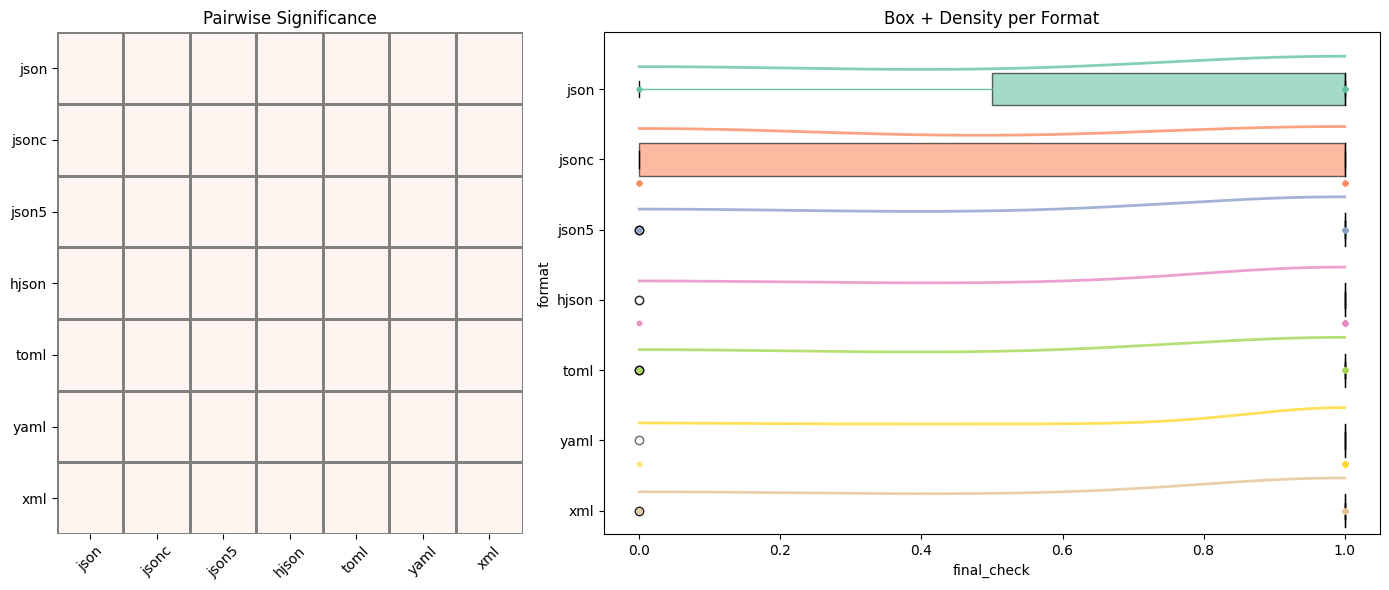

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  0.866667  0.351866     1.0    0    1
 json       15  0.733333  0.457738     1.0    0    1
 json5      15  0.800000  0.414039     1.0    0    1
 jsonc      15  0.533333  0.516398     1.0    0    1
 toml       15  0.800000  0.414039     1.0    0    1
 xml        15  0.866667  0.351866     1.0    0    1
 yaml       17  0.941176  0.242536     1.0    0    1,
 'overall_p': 0.13312899968007536,
 'effect_size': 0.09167243367935411,
 'is_significant': False,
 'pairwise': Empty DataFrame
 Columns: [group1, group2, p_value, significant, interpretation]
 Index: [],
 'warning': None}

In [49]:
vis_box_comparasion(
    m_result_1,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_1 = compare_statistically(
    m_result_1,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_1

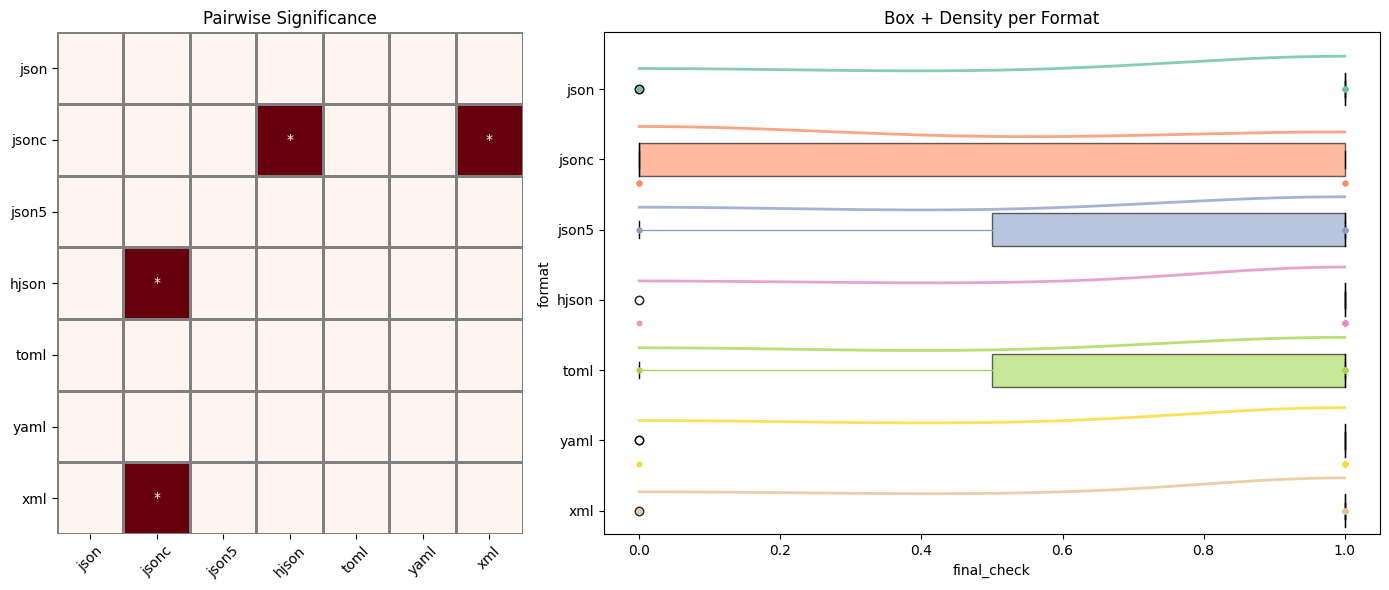

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  0.866667  0.351866     1.0    0    1
 json       15  0.800000  0.414039     1.0    0    1
 json5      15  0.733333  0.457738     1.0    0    1
 jsonc      15  0.400000  0.507093     0.0    0    1
 toml       15  0.733333  0.457738     1.0    0    1
 xml        15  0.866667  0.351866     1.0    0    1
 yaml       17  0.823529  0.392953     1.0    0    1,
 'overall_p': 0.046178916949330025,
 'effect_size': 0.11804647785039943,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9995        False   hjson vs json is not significant
 1   hjson  json5   0.9768        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.0474         True      hjson vs jsonc is significant
 3   hjson   toml   0.9768 

In [51]:
vis_box_comparasion(
    m_result_2,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_2 = compare_statistically(
    m_result_2,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_2

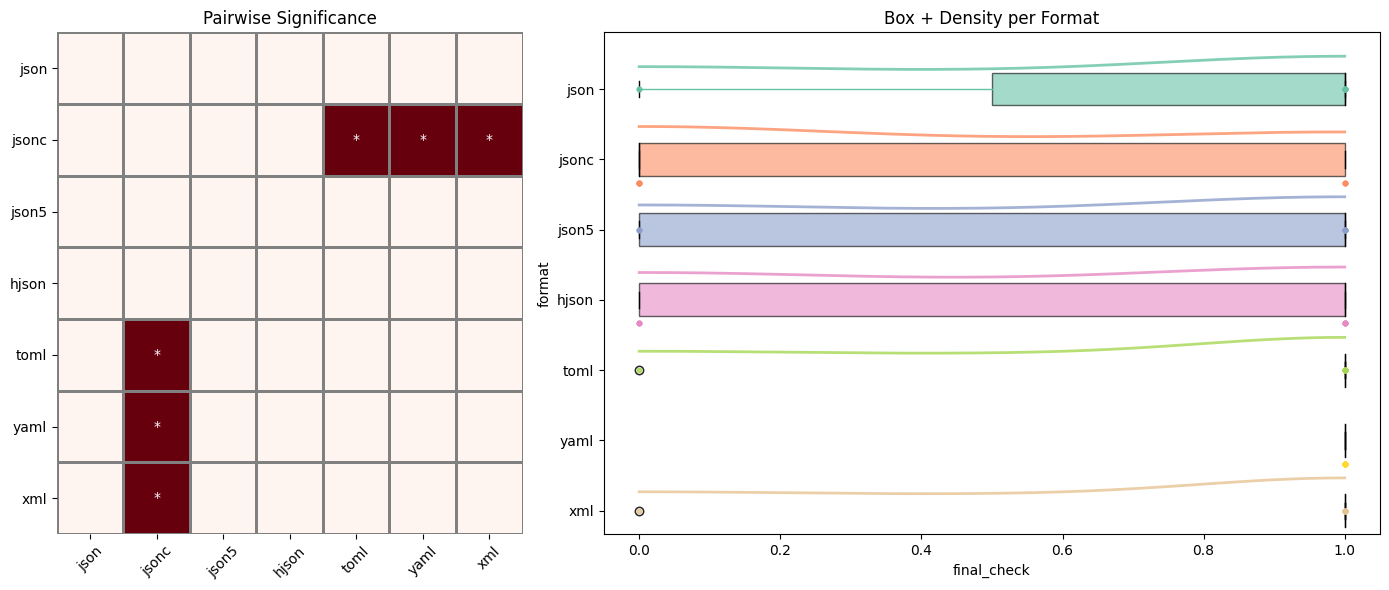

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  0.600000  0.507093     1.0    0    1
 json       15  0.733333  0.457738     1.0    0    1
 json5      15  0.666667  0.487950     1.0    0    1
 jsonc      15  0.400000  0.507093     0.0    0    1
 toml       15  0.866667  0.351866     1.0    0    1
 xml        15  0.866667  0.351866     1.0    0    1
 yaml       17  1.000000  0.000000     1.0    1    1,
 'overall_p': 0.002404875789553816,
 'effect_size': 0.18089210367691383,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9737        False   hjson vs json is not significant
 1   hjson  json5   0.9994        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.8357        False  hjson vs jsonc is not significant
 3   hjson   toml   0.5681 

In [52]:
vis_box_comparasion(
    m_result_3,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_3 = compare_statistically(
    m_result_3,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_3

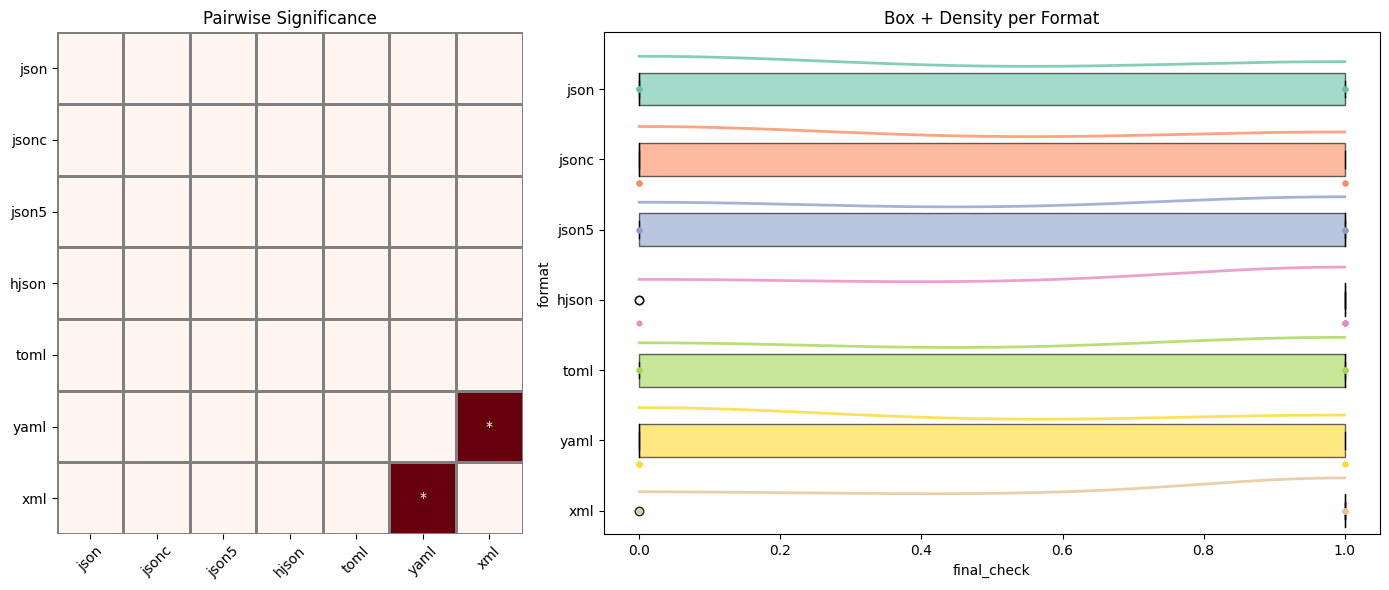

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median  min  max
 format                                             
 hjson      15  0.800000  0.414039     1.0    0    1
 json       15  0.400000  0.507093     0.0    0    1
 json5      15  0.600000  0.507093     1.0    0    1
 jsonc      15  0.400000  0.507093     0.0    0    1
 toml       15  0.600000  0.507093     1.0    0    1
 xml        15  0.866667  0.351866     1.0    0    1
 yaml       17  0.352941  0.492592     0.0    0    1,
 'overall_p': 0.01375268108699252,
 'effect_size': 0.14523220549802246,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.2479        False   hjson vs json is not significant
 1   hjson  json5   0.9083        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.2479        False  hjson vs jsonc is not significant
 3   hjson   toml   0.9083  

In [50]:
vis_box_comparasion(
    m_result_4,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_4 = compare_statistically(
    m_result_4,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_4

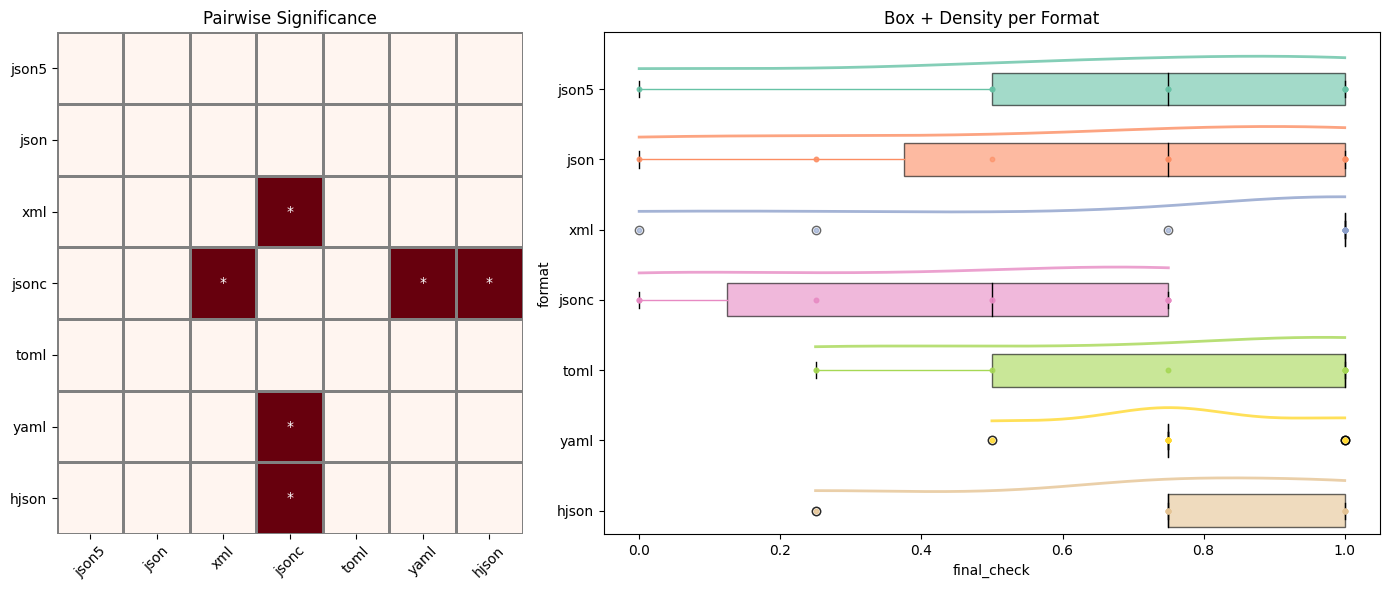

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std  median   min   max
 format                                               
 hjson      15  0.783333  0.247608    0.75  0.25  1.00
 json       15  0.666667  0.374007    0.75  0.00  1.00
 json5      15  0.700000  0.343303    0.75  0.00  1.00
 jsonc      15  0.433333  0.319970    0.50  0.00  0.75
 toml       15  0.750000  0.313392    1.00  0.25  1.00
 xml        15  0.866667  0.311486    1.00  0.00  1.00
 yaml       17  0.779412  0.150061    0.75  0.50  1.00,
 'overall_p': 0.0063450887644726185,
 'effect_size': 0.16146987277647143,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9367        False   hjson vs json is not significant
 1   hjson  json5   0.9880        False  hjson vs json5 is not significant
 2   hjson  jsonc   0.0298         True      hjson vs jsonc is significant
 3   hjs

In [53]:
vis_box_comparasion(
    m_overall_only,
    group_col='format',
    value_col='final_check',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_overall = compare_statistically(
    m_overall_only,
    group_col='format',
    value_col='final_check',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
    # continuous_tasks=['reading-task-config-1','reading-task-config-2','reading-task-config-3','reading-task-config-4', 'reading-task-config-5','reading-task-config']
)

final_check_results_overall

### similarity

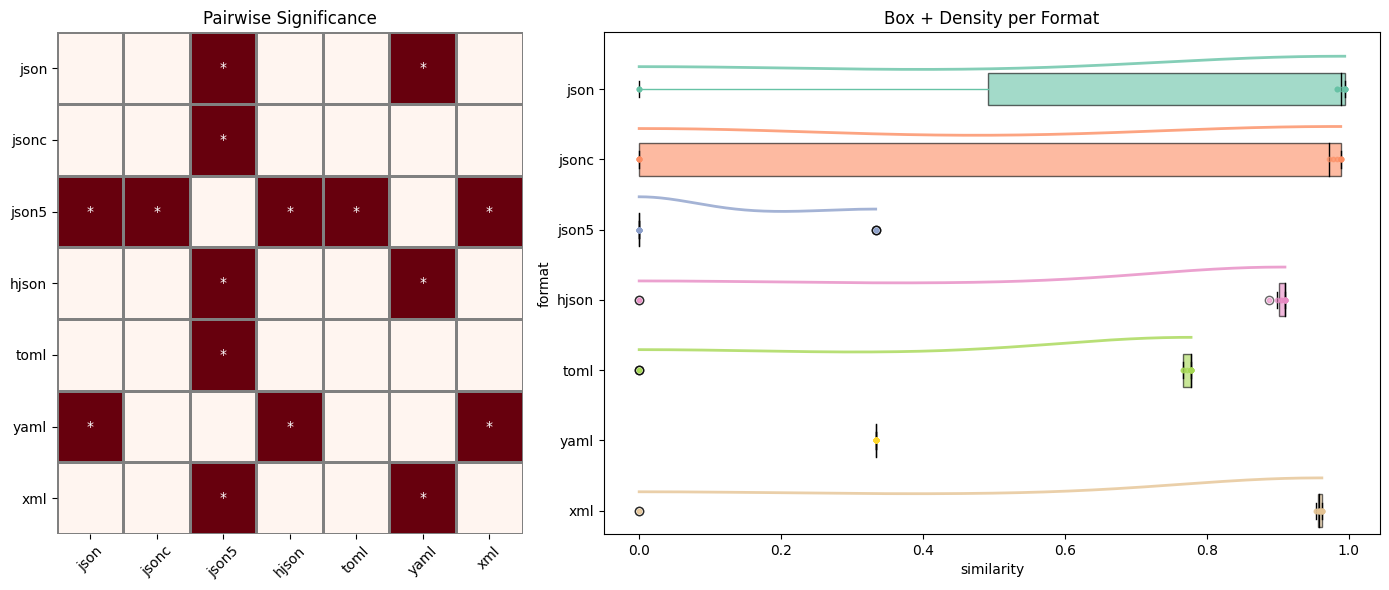

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      15  0.785768  0.319081  0.910112  0.000000  0.910112
 json       15  0.726592  0.453551  0.988764  0.000000  0.994382
 json5      15  0.066667  0.138013  0.000000  0.000000  0.333333
 jsonc      15  0.525102  0.508449  0.971910  0.000000  0.988764
 toml       15  0.620370  0.321096  0.777778  0.000000  0.777778
 xml        15  0.831566  0.337625  0.958333  0.000000  0.962121
 yaml       17  0.333333  0.000000  0.333333  0.333333  0.333333,
 'overall_p': 8.654274917663798e-09,
 'effect_size': 0.37976309450858886,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.9990        False   hjson vs json is not significant
 1   hjson  json5   0.0000         True      hjson vs json5 is signi

In [55]:
vis_box_comparasion(
    m_result_1,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_1 = compare_statistically(
    m_result_1,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_1

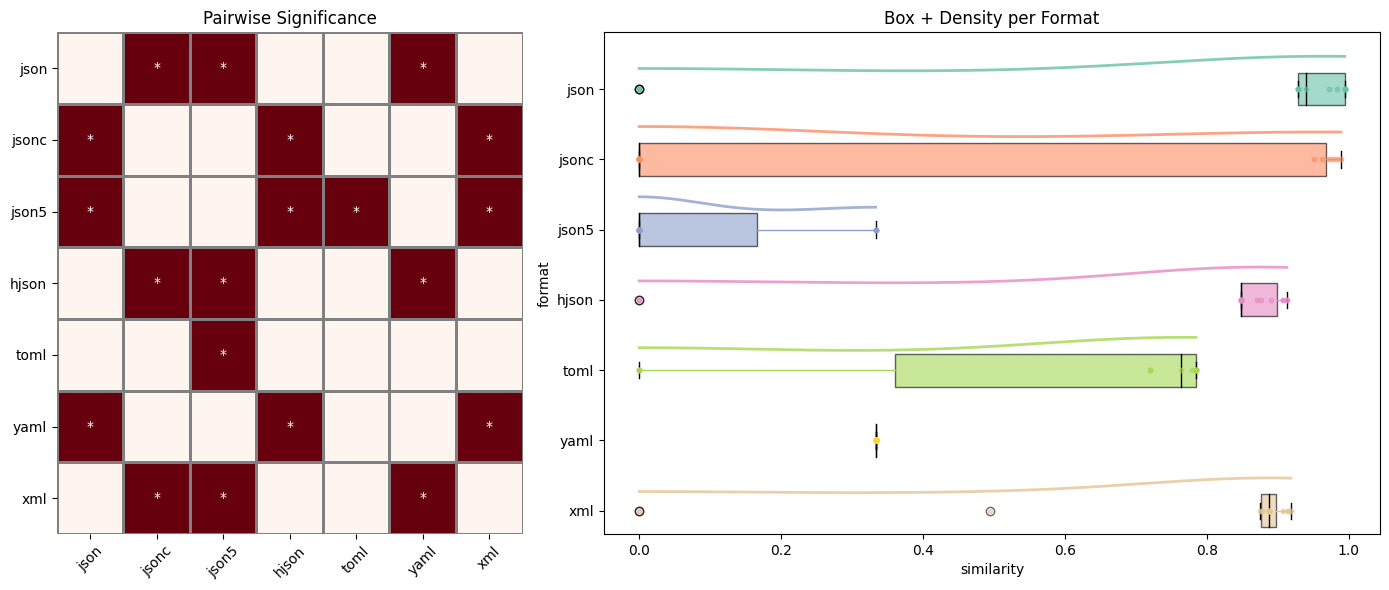

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      15  0.757878  0.308825  0.847826  0.000000  0.913043
 json       15  0.772464  0.400723  0.940217  0.000000  0.994565
 json5      15  0.088889  0.152579  0.000000  0.000000  0.333333
 jsonc      15  0.389184  0.493453  0.000000  0.000000  0.989130
 toml       15  0.560932  0.350999  0.763441  0.000000  0.784946
 xml        15  0.748593  0.321128  0.887640  0.000000  0.918605
 yaml       17  0.333333  0.000000  0.333333  0.333333  0.333333,
 'overall_p': 1.3918012031877842e-08,
 'effect_size': 0.3734424559047196,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   1.0000        False   hjson vs json is not significant
 1   hjson  json5   0.0000         True      hjson vs json5 is signi

In [56]:
vis_box_comparasion(
    m_result_2,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_2 = compare_statistically(
    m_result_2,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_2

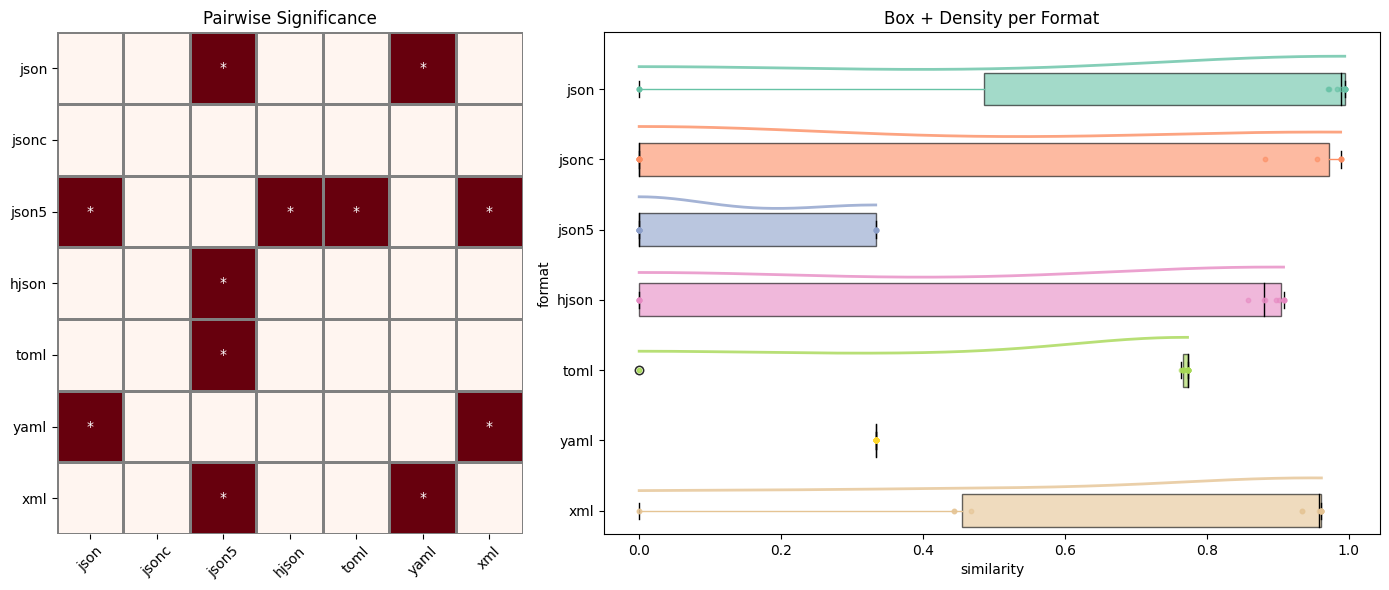

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      15  0.536775  0.453854  0.880000  0.000000  0.908046
 json       15  0.724965  0.452580  0.988571  0.000000  0.994253
 json5      15  0.111111  0.162650  0.000000  0.000000  0.333333
 jsonc      15  0.386039  0.490066  0.000000  0.000000  0.988506
 toml       15  0.667603  0.271063  0.772727  0.000000  0.772727
 xml        15  0.727413  0.359408  0.957529  0.000000  0.961390
 yaml       17  0.333333  0.000000  0.333333  0.333333  0.333333,
 'overall_p': 6.196073540687153e-06,
 'effect_size': 0.28492899800908056,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.7627        False   hjson vs json is not significant
 1   hjson  json5   0.0207         True      hjson vs json5 is signi

In [57]:
vis_box_comparasion(
    m_result_3,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_3 = compare_statistically(
    m_result_3,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_3

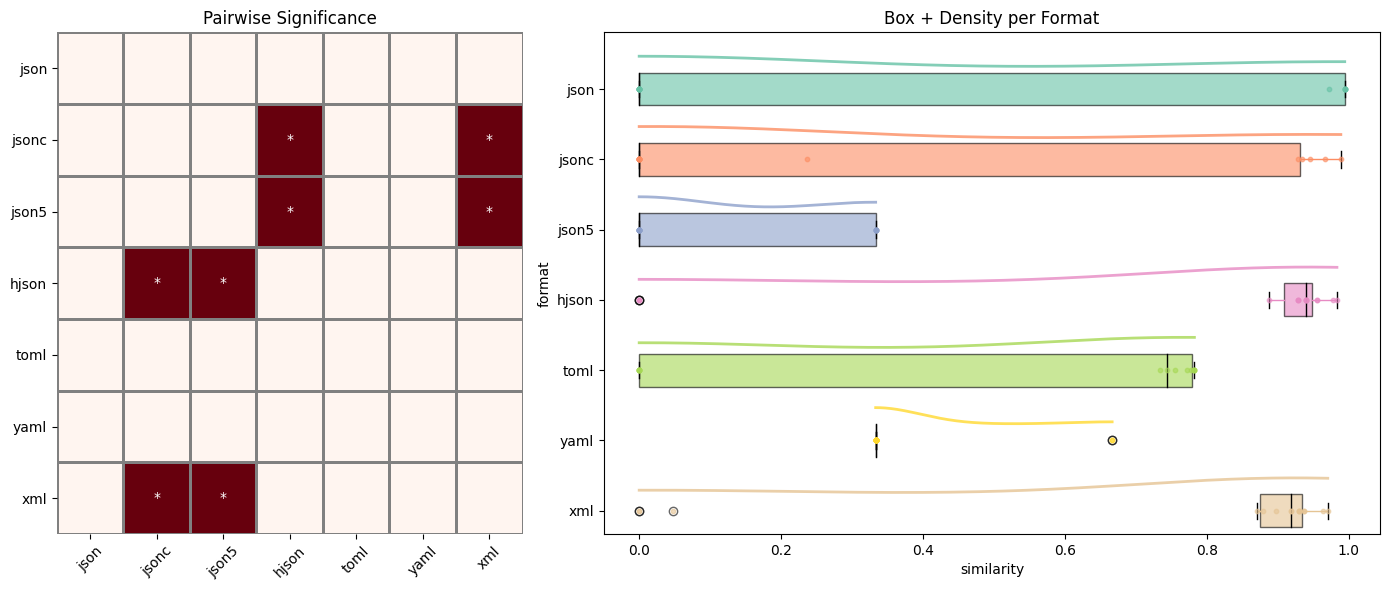

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      15  0.753725  0.390718  0.939560  0.000000  0.983516
 json       15  0.396337  0.502477  0.000000  0.000000  0.994505
 json5      15  0.133333  0.169031  0.000000  0.000000  0.333333
 jsonc      15  0.333333  0.457501  0.000000  0.000000  0.989011
 toml       15  0.460870  0.389766  0.744565  0.000000  0.782609
 xml        15  0.742157  0.376931  0.919118  0.000000  0.970588
 yaml       17  0.372549  0.110702  0.333333  0.333333  0.666667,
 'overall_p': 4.329948706662613e-05,
 'effect_size': 0.25332671530070106,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                     interpretation
 0   hjson   json   0.1136        False   hjson vs json is not significant
 1   hjson  json5   0.0002         True      hjson vs json5 is signi

In [58]:
vis_box_comparasion(
    m_result_4,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_4 = compare_statistically(
    m_result_4,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_4

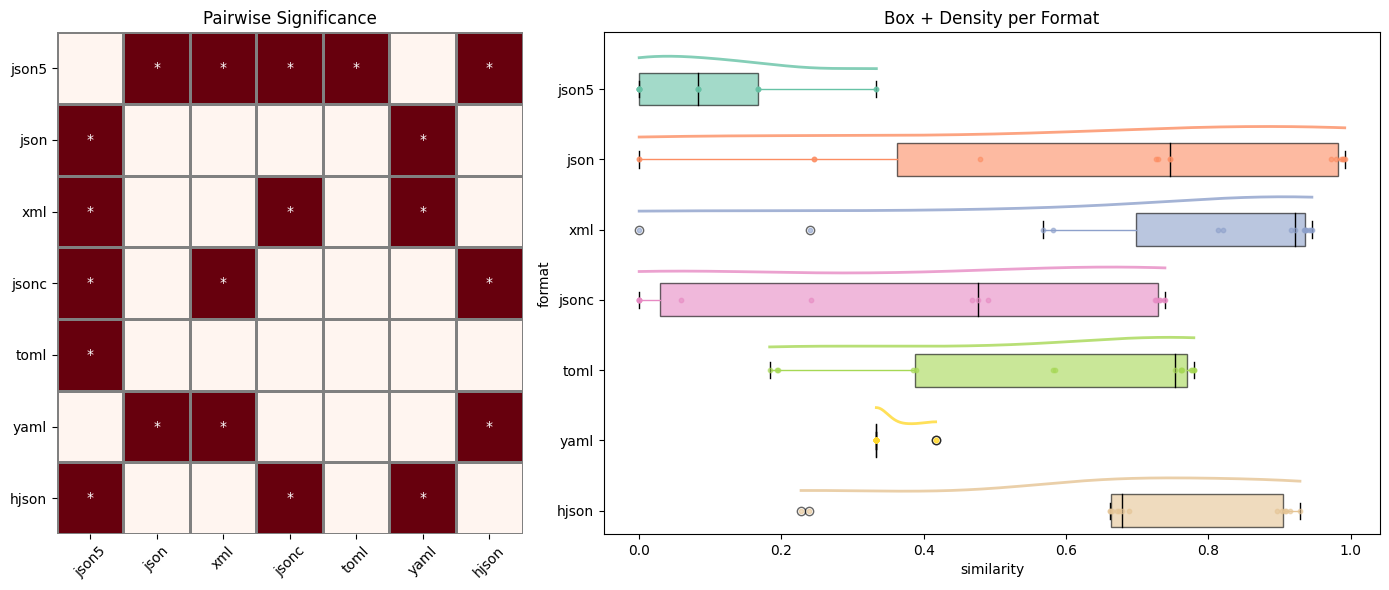

{'method': 'anova',
 'alpha': 0.05,
 'p_adjust_method': 'bonferroni',
 'descriptive':         count      mean       std    median       min       max
 format                                                         
 hjson      15  0.708536  0.224630  0.678372  0.227528  0.928680
 json       15  0.655089  0.368663  0.745800  0.000000  0.991617
 json5      15  0.100000  0.114434  0.083333  0.000000  0.333333
 jsonc      15  0.408415  0.322884  0.476494  0.000000  0.738883
 toml       15  0.577444  0.241446  0.752455  0.183424  0.779515
 xml        15  0.762432  0.292491  0.921510  0.000000  0.945435
 yaml       17  0.343137  0.027675  0.333333  0.333333  0.416667,
 'overall_p': 3.7583391397161123e-11,
 'effect_size': 0.44714624528800784,
 'is_significant': True,
 'pairwise':    group1 group2  p_value  significant                    interpretation
 0   hjson   json   0.9971        False  hjson vs json is not significant
 1   hjson  json5   0.0000         True     hjson vs json5 is signifi

In [59]:
vis_box_comparasion(
    m_overall_only,
    group_col='format',
    value_col='similarity',
    method='anova',
    show_significance=True,
    box_height=0.7,
    vpad=1.5,
    wspace=0.4,
    palette_name='Set2',
    task_col='task_id'
)

sim_results_overall = compare_statistically(
    m_overall_only,
    group_col='format',
    value_col='similarity',
    method='anova',
    task_col='task_id',
    discrete_tasks=['task_id']
)

sim_results_overall